# Generalization in Deep Networks
## How weight initialization, L2 regularization, dropout, and early stopping shape what one fixed network learns on Fashion-MNIST

**Author:** Anush Goel  
**Project:** The Fitting Room, a controlled study of generalization in a fixed dense network

---

### About this notebook

Every experiment here trains the same 784–128–128–10 ReLU network on the same data split, with Adam at its default settings, a batch size of 128, and a budget of 40 epochs. Only one training technique changes at a time, so any difference in the curves can be traced to that technique and nothing else.

Steps 1 to 8 follow a fixed experimental protocol, written down before any model was trained (see `docs/HYPOTHESES.md`). Between Step 7 and Step 8 there is a clearly separated **Extensions** section with analyses that go beyond the core protocol: an early-stopping simulation, a calibration study, paired significance tests, a multi-seed robustness check, a Bayesian hyperparameter search restricted to the techniques under study, and a look at the geometry of the learned representation. None of the extensions touch the test set, and none of them change the Step 6 decision.

Each analysis follows the same rhythm. A figure or table comes first, then a short **Evidence from this run** block that the code writes from the actual numbers, then my interpretation in a Markdown cell. Figures and tables carry APA-style numbers. Table 1 is the headline comparison; supporting tables are labeled S1, S2, and so on.

### Contents

0. Setup, reproducibility, and study design  
1. Step 1: Data preparation  
2. Experimental framework (shared code)  
3. Step 2: Baseline model  
4. Step 3: Weight initialization  
5. Step 4: L2 regularization  
6. Step 5: Dropout  
7. Step 6: Final model selection and test evaluation  
8. Step 7: Comparative analysis  
9. Extensions beyond the core protocol (E1–E6)  
10. Exporting results for the interactive dashboard  
11. **Final analysis and reflection** (Step 8), recommendations, limitations  
12. References

**Runtime.** The core steps take roughly 10 to 15 minutes on a CPU and less on a GPU. With every extension switched on, plan for about 60 to 90 minutes on a CPU. Each training run is cached under `artifacts/runs/`, so re-running the notebook reloads finished runs instead of retraining them.

## 0. Setup, reproducibility, and study design

In [2]:
# Install TensorFlow if it's missing in the environment
!pip install -q tensorflow

# 0.1  Libraries ---------------------------------------------------------------
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")      # keep TensorFlow's start-up logs quiet

import json, time, math, hashlib, platform, warnings, sys, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import display, Markdown

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, silhouette_score
from sklearn.manifold import TSNE
import scipy
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 200)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 809.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 109.5 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [3]:
# 0.2  Experiment configuration (identical for every experiment) ----------------
SEED = 42              # controls the data split, weight initialization, shuffling, and dropout masks
EPOCHS = 40            # fixed maximum number of epochs for every model
BATCH_SIZE = 128       # fixed mini-batch size for every model
N_VAL = 10_000         # validation images carved out of the 60,000 original training images
CLEAN_SUBSET = 10_000  # training images re-scored after every epoch with dropout switched off
PROBE_N = 2_000        # validation images used for activation diagnostics

# Extensions beyond the core protocol. Set these to False for a quick run of the core steps only.
RUN_SEED_STUDY = True  # repeat all six configurations with extra seeds (E4)
EXTRA_SEEDS = [7, 2024]
RUN_TUNING = True      # Optuna search over initializer, L2 strength, and dropout rate (E5)
N_TRIALS = 30
TUNE_PATIENCE = 8      # early stopping inside the search only, to save compute
FORCE_RETRAIN = False  # True ignores cached runs and trains everything again

# Results go to <repo>/artifacts whether the notebook runs from the repo root or from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ART = ROOT / "artifacts"
RUN_DIR, FIG_DIR = ART / "runs", ART / "figures"
for folder in (ART, RUN_DIR, FIG_DIR):
    folder.mkdir(parents=True, exist_ok=True)

keras.utils.set_random_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
print("Hardware:", "GPU, " + ", ".join(g.name for g in gpus) if gpus else "CPU only")
versions = pd.DataFrame({
    "Python": [platform.python_version()], "TensorFlow": [tf.__version__], "Keras": [keras.__version__],
    "NumPy": [np.__version__], "pandas": [pd.__version__], "scikit-learn": [sklearn.__version__],
    "SciPy": [scipy.__version__], "Matplotlib": [mpl.__version__],
}, index=["version"])
display(versions)

Hardware: CPU only


,Python,TensorFlow,Keras,NumPy,pandas,scikit-learn,SciPy,Matplotlib
version,3.13.16,2.21.0,3.13.2,2.1.3,2.2.3,1.6.1,1.16.3,3.10.0


In [4]:
# 0.3  Visual language: one color per configuration, reused in every figure and in the dashboard
PALETTE = {
    "baseline":    "#8A93A8",   # slate: the untouched reference
    "he_init":     "#3D6FD6",   # denim blue: initialization
    "l2_0.001":    "#2BB596",   # greens: L2 family (lighter = weaker)
    "l2_0.01":     "#17695C",
    "dropout_0.2": "#EE7F5E",   # warm reds: dropout family (lighter = weaker)
    "dropout_0.4": "#B8344F",
    "tuned":       "#8C6BD9",   # violet: the Optuna configuration
}
LABELS = {
    "baseline":    "Baseline (Glorot, no regularization)",
    "he_init":     "He initialization",
    "l2_0.001":    "He + L2 (λ = 0.001)",
    "l2_0.01":     "He + L2 (λ = 0.01)",
    "dropout_0.2": "He + dropout (p = 0.2)",
    "dropout_0.4": "He + dropout (p = 0.4)",
    "tuned":       "Tuned (Optuna)",
}
SHORT = {"baseline": "Baseline", "he_init": "He init", "l2_0.001": "L2 0.001", "l2_0.01": "L2 0.01",
         "dropout_0.2": "Dropout 0.2", "dropout_0.4": "Dropout 0.4", "tuned": "Tuned"}
INK, MUTED = "#1F2433", "#6B7280"

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#C9CDD6",
    "axes.grid": True, "grid.color": "#E6E8EE", "grid.linewidth": 0.8,
    "axes.titlesize": 11.5, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.labelsize": 10, "axes.labelcolor": INK, "xtick.color": "#4B5160", "ytick.color": "#4B5160",
    "legend.frameon": False, "legend.fontsize": 8.8, "font.size": 10, "text.color": INK,
})


def save_fig(fig, name):
    """Keep a high-resolution copy of every figure for the dashboard and for reuse."""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=170, bbox_inches="tight", facecolor="white")


def pct(x, d=2):
    return "n/a" if x is None else f"{100 * x:.{d}f}%"


def pp(x, d=2):
    """Signed difference in percentage points."""
    return f"{100 * x:+.{d}f} pp"


def show_evidence(title, lines):
    """Writes the numeric evidence behind each interpretation, so the prose can be checked against the run."""
    body = "\n".join(f"- {line}" for line in lines)
    display(Markdown(f"**Evidence from this run: {title}**\n\n{body}"))

**Figure 1**  
*Study design. Each arrow changes exactly one thing.*

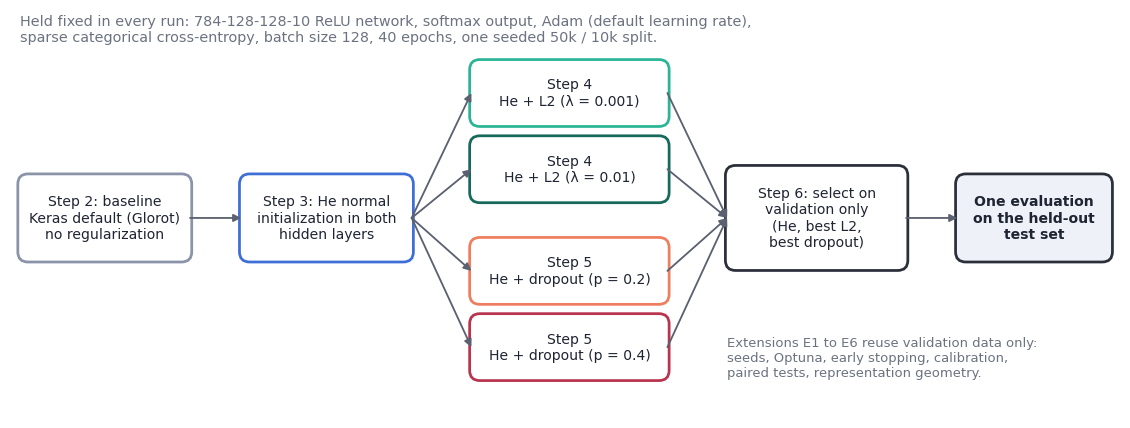

In [5]:
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.set_xlim(0, 13); ax.set_ylim(0, 4.8); ax.axis("off"); ax.grid(False)


def node(x, y, w, h, text, edge, face="white", weight="normal", size=9.2):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.12",
                                lw=1.8, ec=edge, fc=face))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=size, color=INK, weight=weight)


def link(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", lw=1.2, color="#5B6170", shrinkA=0, shrinkB=0))


node(0.1, 1.85, 2.0, 1.0, "Step 2: baseline\nKeras default (Glorot)\nno regularization", PALETTE["baseline"])
node(2.7, 1.85, 2.0, 1.0, "Step 3: He normal\ninitialization in both\nhidden layers", PALETTE["he_init"])
link(2.1, 2.35, 2.7, 2.35)
branch_y = [3.45, 2.55, 1.35, 0.45]
for y, k, step in zip(branch_y, ["l2_0.001", "l2_0.01", "dropout_0.2", "dropout_0.4"],
                      ["Step 4", "Step 4", "Step 5", "Step 5"]):
    node(5.4, y, 2.3, 0.75, f"{step}\n{LABELS[k]}", PALETTE[k])
    link(4.7, 2.35, 5.4, y + 0.375)
node(8.4, 1.75, 2.1, 1.2, "Step 6: select on\nvalidation only\n(He, best L2,\nbest dropout)", "#2B2F3A")
for y in branch_y:
    link(7.7, y + 0.375, 8.4, 2.35)
node(11.1, 1.85, 1.8, 1.0, "One evaluation\non the held-out\ntest set", "#2B2F3A", face="#EEF1F7", weight="semibold")
link(10.5, 2.35, 11.1, 2.35)
ax.text(0.1, 4.75, "Held fixed in every run: 784-128-128-10 ReLU network, softmax output, Adam (default learning rate),\n"
        "sparse categorical cross-entropy, batch size 128, 40 epochs, one seeded 50k / 10k split.",
        fontsize=9.4, color=MUTED, va="top")
ax.text(8.4, 0.95, "Extensions E1 to E6 reuse validation data only:\nseeds, Optuna, early stopping, calibration,\npaired tests, representation geometry.",
        fontsize=8.6, color=MUTED, va="top")
save_fig(fig, "fig01_study_design")
plt.show()

## 1. Step 1: Data preparation

Fashion-MNIST contains 70,000 grayscale images of clothing at 28 × 28 pixels, split into 60,000 training and 10,000 test images across 10 balanced classes (Xiao et al., 2017). The dataset was designed as a harder drop-in replacement for MNIST digits, and several of its classes (shirts, T-shirts, pullovers, coats) are hard to tell apart even for people, which turns out to matter for how we interpret overfitting.

The preparation below flattens each image to 784 values, rescales pixels to [0, 1], keeps the labels as integers 0–9 for sparse categorical cross-entropy, and carves a stratified, seeded 10,000-image validation set out of the original training images. The original test set is set aside and not touched again until Step 6.

In [6]:
# 1.1  Load, flatten, normalize, split ----------------------------------------------
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(f"Raw training images: {X_train_raw.shape}, dtype {X_train_raw.dtype}, "
      f"pixel range [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"Raw test images:     {X_test_raw.shape}")


def preprocess(images):
    """Flatten 28x28 -> 784 values and rescale [0, 255] -> [0, 1] as float32."""
    return images.reshape(len(images), -1).astype("float32") / 255.0


X_all, y_all = preprocess(X_train_raw), y_train_raw.astype("int32")
X_test, y_test = preprocess(X_test_raw), y_test_raw.astype("int32")

# Stratified, seeded 50,000 / 10,000 split. Splitting indices (not arrays) keeps the split auditable.
idx_train, idx_val = train_test_split(np.arange(len(X_all)), test_size=N_VAL, stratify=y_all,
                                      random_state=SEED, shuffle=True)
X_train, y_train = X_all[idx_train], y_all[idx_train]
X_val, y_val = X_all[idx_val], y_all[idx_val]

# A fixed subset of training images, re-scored after every epoch with dropout off (used from Step 2 on)
CLEAN_IDX = np.random.default_rng(SEED).choice(len(X_train), CLEAN_SUBSET, replace=False)
X_clean, y_clean = X_train[CLEAN_IDX], y_train[CLEAN_IDX]

# Sanity checks: shapes, value range, no overlap, integer labels covering all classes
assert X_train.shape == (50_000, 784) and X_val.shape == (10_000, 784) and X_test.shape == (10_000, 784)
assert X_train.min() >= 0.0 and X_train.max() <= 1.0
assert np.intersect1d(idx_train, idx_val).size == 0
assert np.issubdtype(y_train.dtype, np.integer) and set(np.unique(y_train)) == set(range(10))

split_fingerprint = hashlib.md5(np.sort(idx_val).tobytes()).hexdigest()[:12]
np.savez_compressed(ART / "split_indices.npz", idx_train=idx_train, idx_val=idx_val)
print(f"\nTraining   {X_train.shape}  labels {y_train.dtype}")
print(f"Validation {X_val.shape}")
print(f"Test       {X_test.shape}  (held out until Step 6)")
print(f"Pixel range after scaling: [{X_train.min():.1f}, {X_train.max():.1f}]; "
      f"mean {X_train.mean():.3f}; split fingerprint {split_fingerprint}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Raw training images: (60000, 28, 28), dtype uint8, pixel range [0, 255]
Raw test images:     (10000, 28, 28)

Training   (50000, 784)  labels int32
Validation (10000, 784)
Test       (10000, 784)  (held out until Step 6)
Pixel range after scaling: [0.0, 1.0]; mean 0.286; split fingerprint 770af0aa560b


**Table S1**  
*Class counts (and shares) in each partition*

In [7]:
counts = pd.DataFrame({"Training": np.bincount(y_train, minlength=10),
                       "Validation": np.bincount(y_val, minlength=10),
                       "Test": np.bincount(y_test, minlength=10)}, index=CLASS_NAMES)
shares = 100 * counts / counts.sum()
table_s1 = counts.astype(str) + " (" + shares.round(1).astype(str) + "%)"
table_s1.loc["Total"] = counts.sum().astype(str)
display(table_s1)

,Training,Validation,Test
T-shirt/top,5000 (10.0%),1000 (10.0%),1000 (10.0%)
Trouser,5000 (10.0%),1000 (10.0%),1000 (10.0%)
Pullover,5000 (10.0%),1000 (10.0%),1000 (10.0%)
Dress,5000 (10.0%),1000 (10.0%),1000 (10.0%)
Coat,5000 (10.0%),1000 (10.0%),1000 (10.0%)
Sandal,5000 (10.0%),1000 (10.0%),1000 (10.0%)
Shirt,5000 (10.0%),1000 (10.0%),1000 (10.0%)
Sneaker,5000 (10.0%),1000 (10.0%),1000 (10.0%)
Bag,5000 (10.0%),1000 (10.0%),1000 (10.0%)
Ankle boot,5000 (10.0%),1000 (10.0%),1000 (10.0%)


**Figure 2**  
*Ten random training images per class*

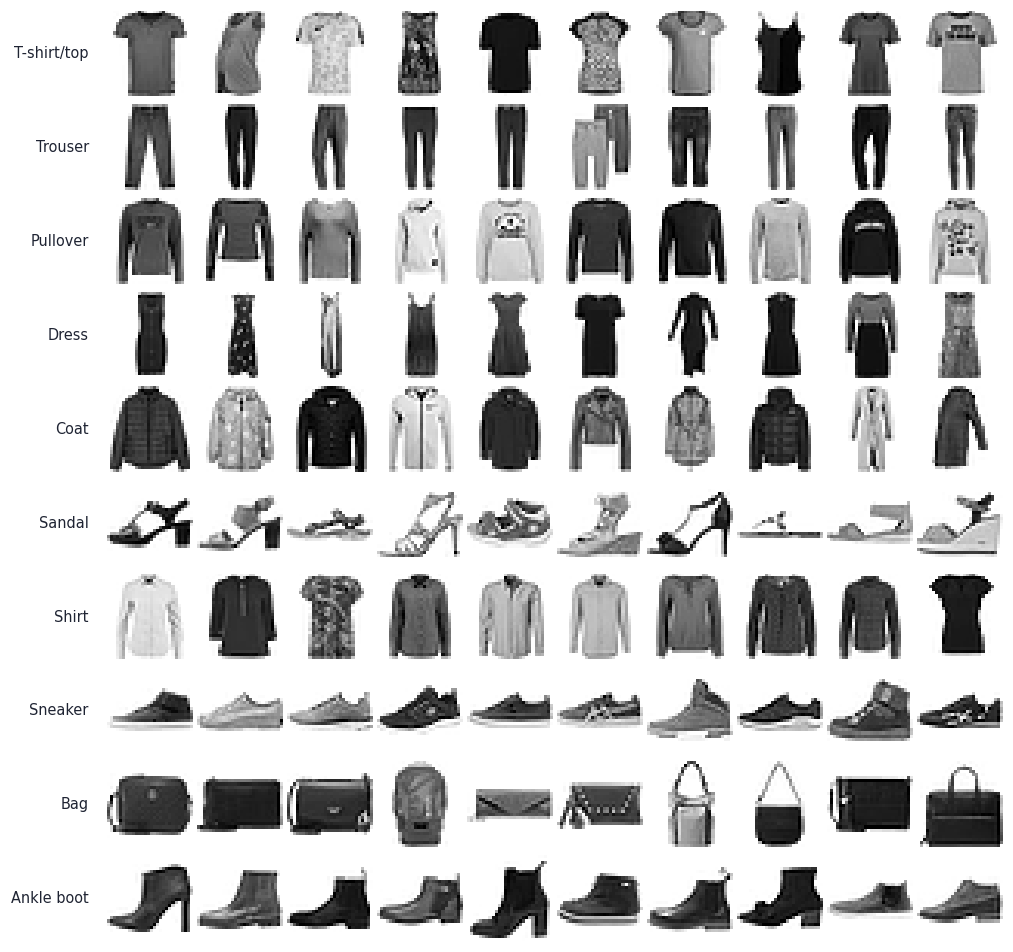

In [8]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(10, 10, figsize=(10.5, 11))
for c in range(10):
    picks = rng.choice(np.where(y_train == c)[0], 10, replace=False)
    for j, i in enumerate(picks):
        ax = axes[c, j]
        ax.imshow(X_train[i].reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(False)
    axes[c, 0].set_ylabel(CLASS_NAMES[c], rotation=0, ha="right", va="center", fontsize=9.5, labelpad=12)
plt.subplots_adjust(wspace=0.05, hspace=0.08)
save_fig(fig, "fig02_samples")
plt.show()

**Figure 3**  
*Average training image of each class*

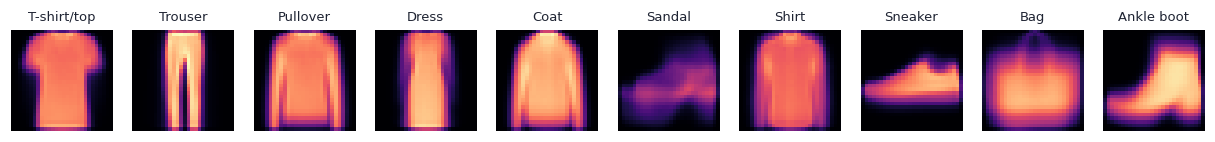

In [9]:
mean_imgs = np.stack([X_train[y_train == c].mean(axis=0) for c in range(10)])
fig, axes = plt.subplots(1, 10, figsize=(14, 1.9))
for c, ax in enumerate(axes):
    ax.imshow(mean_imgs[c].reshape(28, 28), cmap="magma", vmin=0, vmax=mean_imgs.max())
    ax.set_title(CLASS_NAMES[c], fontsize=8.6, loc="center", weight="normal")
    ax.axis("off")
save_fig(fig, "fig03_mean_images")
plt.show()

**Figure 4**  
*Where the information lives. (a) Per-pixel standard deviation across the training set. (b) The same 784 values sorted. (c) Cosine similarity between centered class-mean images.*

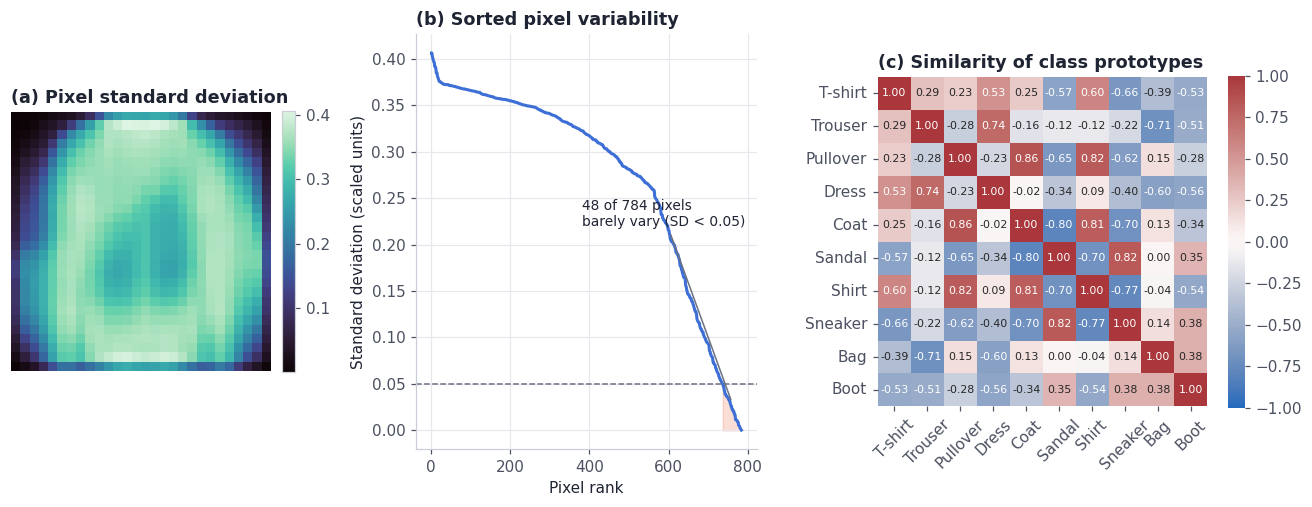

**Evidence from this run: input structure**

- 48 of 784 pixels (6%) have a standard deviation below 0.05, mostly along the image border.
- Most similar class prototypes: Pullover and Coat (0.86); Sandal and Sneaker (0.82); Pullover and Shirt (0.82); Coat and Shirt (0.81).

In [10]:
pixel_std = X_train.std(axis=0)
n_flat = int((pixel_std < 0.05).sum())
centered = mean_imgs - mean_imgs.mean(axis=0, keepdims=True)
unit = centered / np.linalg.norm(centered, axis=1, keepdims=True)
CLASS_SIM = unit @ unit.T

fig = plt.figure(figsize=(15, 4.9))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.2, 1.45], wspace=0.35)

ax0 = fig.add_subplot(gs[0])
im = ax0.imshow(pixel_std.reshape(28, 28), cmap="mako")
ax0.set_title("(a) Pixel standard deviation"); ax0.axis("off")
fig.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)

ax1 = fig.add_subplot(gs[1])
sorted_std = np.sort(pixel_std)[::-1]
ax1.plot(np.arange(1, 785), sorted_std, color=PALETTE["he_init"], lw=2)
ax1.axhline(0.05, color=MUTED, ls="--", lw=1)
ax1.fill_between(np.arange(1, 785), 0, sorted_std, where=sorted_std < 0.05, color=PALETTE["dropout_0.2"], alpha=0.25)
ax1.annotate(f"{n_flat} of 784 pixels\nbarely vary (SD < 0.05)", xy=(784 - n_flat / 2, 0.03),
             xytext=(380, 0.22), fontsize=9, arrowprops=dict(arrowstyle="-", color=MUTED))
ax1.set_xlabel("Pixel rank"); ax1.set_ylabel("Standard deviation (scaled units)")
ax1.set_title("(b) Sorted pixel variability")

ax2 = fig.add_subplot(gs[2])
short_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Boot"]
sns.heatmap(CLASS_SIM, ax=ax2, cmap="vlag", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 7.2}, xticklabels=short_names, yticklabels=short_names,
            cbar_kws={"shrink": 0.8}, square=True)
ax2.set_title("(c) Similarity of class prototypes"); ax2.grid(False)
ax2.tick_params(axis="x", rotation=45); ax2.tick_params(axis="y", rotation=0)
save_fig(fig, "fig04_pixel_information")
plt.show()

pairs = sorted(((CLASS_SIM[i, j], CLASS_NAMES[i], CLASS_NAMES[j]) for i in range(10) for j in range(i + 1, 10)), reverse=True)
show_evidence("input structure", [
    f"{n_flat} of 784 pixels ({100 * n_flat / 784:.0f}%) have a standard deviation below 0.05, mostly along the image border.",
    "Most similar class prototypes: " + "; ".join(f"{a} and {b} ({s:.2f})" for s, a, b in pairs[:4]) + ".",
])

**What the data already tells us.** Two features of Fashion-MNIST shape everything that follows. First, a sizeable share of the 784 inputs is almost constant (Figure 4a–b). A dense layer still allocates 128 weights to each of those pixels, so the network carries parameters that the data barely constrains; this is precisely the kind of "irrelevant component" that weight decay is known to suppress (Krogh & Hertz, 1991), and Step 4 checks whether it does. Second, the upper-body garments have very similar average shapes (Figure 4c). Some fraction of those images will remain ambiguous no matter how well the model is trained, which puts a ceiling on validation accuracy and means that pushing training accuracy toward 100% will partly amount to memorizing hard or mislabeled cases rather than learning anything that transfers.

### Why normalization is appropriate

Raw pixels are integers between 0 and 255. Dividing by 255 maps every input to [0, 1] without changing the relative structure of an image, and it matters here for three reasons. Both initializers studied in Step 3 are derived under the assumption that inputs have a modest, roughly unit scale; inputs two orders of magnitude larger would push the first-layer pre-activations far outside the range the initializer was designed for, and the Step 3 comparison would really be a comparison of two mis-scaled networks (Glorot & Bengio, 2010; He et al., 2015). Input scale also feeds directly into the size of the first-layer gradients, and keeping all features on one small, common scale gives a better-conditioned optimization problem (LeCun et al., 1998). Finally, an L2 penalty is scale dependent: the same λ means something different if the weights have to compensate for inputs that are 255 times larger, so normalizing first is what makes the λ values in Step 4 interpretable. I chose min–max scaling rather than per-pixel standardization because so many border pixels are nearly constant (Figure 4b); standardizing them would divide by a near-zero standard deviation and turn tiny amounts of noise into large input values.

### Why the test set must stay out of model selection

Choosing among configurations is itself a form of fitting. Each time a decision is made by looking at a score, a little information about that data leaks into the final model. If the test set were used to pick the regularizer, its accuracy would stop being an unbiased estimate of performance on new images and would instead be optimistically biased by the selection, and the bias grows with the number of candidates compared (Cawley & Talbot, 2010; Goodfellow et al., 2016). In this notebook the validation set carries every decision in Steps 2 to 6, and the test set is used exactly once, after the decision has been frozen. The split is also stratified, so each class keeps its 10% share in all three partitions (Table S1). With balanced classes, accuracy is a fair headline metric.

## 2. Experimental framework (shared code)

All experiments run through the same four pieces of code, so the comparison stays fair by construction:

1. `build_model` builds the fixed architecture. The only arguments are the technique under study (initializer, L2 coefficient, dropout rate) and the seed.
2. `TrainingDiagnostics` is a Keras callback that measures, after every epoch, things Keras does not report: training accuracy with dropout switched off, validation cross-entropy *without* the L2 term, weight norms, the size of the L2 penalty, the share of "dead" ReLU units, and the scale of the hidden activations. It also keeps an in-memory copy of the weights from the epoch with the best validation accuracy, which is what early stopping with `restore_best_weights` would hand back (Prechelt, 1998).
3. `run_experiment` trains one configuration for the full 40 epochs and caches everything to disk.
4. `summarize` applies one reporting rule to every run: metrics are read at the epoch of best validation accuracy.

Training always runs to 40 epochs so the full curves are visible; the best-epoch weights are kept separately and used for selection and testing.

In [11]:
# 2.1  The fixed model ---------------------------------------------------------------
def build_model(init=None, l2=0.0, dropout=0.0, seed=SEED, name="mlp"):
    """784-128-128-10 ReLU network. Only the technique under study changes.

    init    : None keeps the Keras default (Glorot uniform); otherwise an initializer name for both hidden layers
    l2      : L2 coefficient applied to both hidden kernels (never to the output layer)
    dropout : rate of a Dropout layer placed after each hidden layer (0 means no dropout layer)
    """
    keras.utils.set_random_seed(seed)

    def hidden_kwargs():
        kw = {}
        if init is not None:
            kw["kernel_initializer"] = init
        if l2 and l2 > 0:
            kw["kernel_regularizer"] = keras.regularizers.l2(l2)
        return kw

    inputs = keras.Input(shape=(784,), name="pixels")
    x = keras.layers.Dense(128, activation="relu", name="hidden1", **hidden_kwargs())(inputs)
    if dropout > 0:
        x = keras.layers.Dropout(dropout, name="dropout1")(x)
    x = keras.layers.Dense(128, activation="relu", name="hidden2", **hidden_kwargs())(x)
    if dropout > 0:
        x = keras.layers.Dropout(dropout, name="dropout2")(x)
    outputs = keras.layers.Dense(10, activation="softmax", name="output")(x)  # default init, no penalty

    safe_name = "".join(ch if ch.isalnum() else "_" for ch in name)
    model = keras.Model(inputs, outputs, name=safe_name)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


EXPERIMENTS = {
    "baseline":    dict(init=None,        l2=0.0,  dropout=0.0),
    "he_init":     dict(init="he_normal", l2=0.0,  dropout=0.0),
    "l2_0.001":    dict(init="he_normal", l2=1e-3, dropout=0.0),
    "l2_0.01":     dict(init="he_normal", l2=1e-2, dropout=0.0),
    "dropout_0.2": dict(init="he_normal", l2=0.0,  dropout=0.2),
    "dropout_0.4": dict(init="he_normal", l2=0.0,  dropout=0.4),
}
MAIN_KEYS = list(EXPERIMENTS)

build_model(name="architecture_check").summary()

Model: "architecture_check"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pixels (InputLayer)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 2.2  Diagnostics that Keras does not report -----------------------------------------
def forward_np(weights, X):
    """Inference-mode forward pass in NumPy. Dropout is inactive at inference, so it simply does not appear."""
    W1, b1, W2, b2, W3, b3 = weights
    h1 = np.maximum(X @ W1 + b1, 0.0)
    h2 = np.maximum(h1 @ W2 + b2, 0.0)
    z = h2 @ W3 + b3
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return h1, h2, z, e / e.sum(axis=1, keepdims=True)


def cross_entropy(p, y):
    """Mean data cross-entropy, with no regularization term."""
    return float(-np.mean(np.log(np.clip(p[np.arange(len(y)), y], 1e-12, 1.0))))


def accuracy(p, y):
    return float(np.mean(p.argmax(axis=1) == y))


class TrainingDiagnostics(keras.callbacks.Callback):
    """After every epoch: clean training accuracy and CE (dropout off, end-of-epoch weights), data-only
    validation CE, squared weight norms, the L2 penalty, dead-ReLU fractions, and activation RMS.
    Index 0 of every record is the untrained network (epoch 0). Also keeps the best-epoch weights."""

    KEYS = ["clean_train_acc", "clean_train_ce", "val_acc", "val_ce", "sqnorm_h1", "sqnorm_h2", "sqnorm_out",
            "l2_penalty", "dead_h1", "dead_h2", "rms_h1", "rms_h2"]

    def __init__(self, l2=0.0):
        super().__init__()
        self.l2 = float(l2 or 0.0)
        self.rec = {k: [] for k in self.KEYS}
        self.epoch_times = []
        self.best_val_acc, self.best_epoch, self.best_weights, self.init_weights = -np.inf, 0, None, None

    def _record(self):
        w = [np.asarray(a, dtype=np.float32) for a in self.model.get_weights()]
        _, _, _, p_tr = forward_np(w, X_clean)
        h1, h2, _, p_va = forward_np(w, X_val)
        r = self.rec
        r["clean_train_acc"].append(accuracy(p_tr, y_clean))
        r["clean_train_ce"].append(cross_entropy(p_tr, y_clean))
        r["val_acc"].append(accuracy(p_va, y_val))
        r["val_ce"].append(cross_entropy(p_va, y_val))
        sq = [float(np.sum(w[i] ** 2)) for i in (0, 2, 4)]
        r["sqnorm_h1"].append(sq[0]); r["sqnorm_h2"].append(sq[1]); r["sqnorm_out"].append(sq[2])
        r["l2_penalty"].append(self.l2 * (sq[0] + sq[1]))           # Keras l2(λ) adds λ·ΣW² per kernel
        r["dead_h1"].append(float(np.mean(np.all(h1[:PROBE_N] == 0, axis=0))))
        r["dead_h2"].append(float(np.mean(np.all(h2[:PROBE_N] == 0, axis=0))))
        r["rms_h1"].append(float(np.sqrt(np.mean(h1[:PROBE_N] ** 2))))
        r["rms_h2"].append(float(np.sqrt(np.mean(h2[:PROBE_N] ** 2))))
        return w

    def on_train_begin(self, logs=None):
        assert len(self.model.get_weights()) == 6, "expected [W1, b1, W2, b2, W3, b3]"
        self.init_weights = [w.copy() for w in self._record()]

    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.perf_counter() - self._t0)
        w = self._record()
        val_acc = float(logs["val_accuracy"])
        if val_acc > self.best_val_acc:            # strict: the earliest epoch wins ties
            self.best_val_acc, self.best_epoch = val_acc, epoch + 1
            self.best_weights = [a.copy() for a in w]

In [13]:
# 2.3  Running, caching, and summarizing experiments -------------------------------------
RUNS, SUM = {}, {}


def _save_weights(path, weights):
    np.savez(path, **{f"w{i}": w for i, w in enumerate(weights)})


def _load_weights(path):
    with np.load(path) as z:
        return [z[f"w{i}"] for i in range(len(z.files))]


def run_experiment(key, cfg=None, seed=SEED, tag=None, verbose=True):
    """Train one configuration for EPOCHS epochs (or load it from the cache)."""
    cfg = dict(EXPERIMENTS[key] if cfg is None else cfg)
    tag = tag or (key if seed == SEED else f"{key}__seed{seed}")
    out = RUN_DIR / tag
    if (out / "result.json").exists() and not FORCE_RETRAIN:
        res = json.loads((out / "result.json").read_text())
        for part in ("init", "best", "final"):
            res[f"{part}_weights"] = _load_weights(out / f"{part}_weights.npz")
        if verbose:
            print(f"[cache] {tag}: best val acc {pct(res['best_val_acc'])} at epoch {res['best_epoch']}")
        return res

    model = build_model(**cfg, seed=seed, name=tag)
    diag = TrainingDiagnostics(l2=cfg.get("l2", 0.0))
    t0 = time.perf_counter()
    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE,
                     shuffle=True, verbose=0, callbacks=[diag])
    res = {
        "key": key, "tag": tag, "seed": seed, "config": cfg,
        "history": {k: [float(v) for v in vals] for k, vals in hist.history.items()},
        "diag": diag.rec, "epoch_times": diag.epoch_times,
        "best_epoch": int(diag.best_epoch), "best_val_acc": float(diag.best_val_acc),
        "train_time_s": float(time.perf_counter() - t0), "n_params": int(model.count_params()),
    }
    weights = {"init": diag.init_weights, "best": diag.best_weights, "final": [w.copy() for w in model.get_weights()]}
    out.mkdir(parents=True, exist_ok=True)
    for part, w in weights.items():
        _save_weights(out / f"{part}_weights.npz", w)
    (out / "result.json").write_text(json.dumps(res))           # written last, so a partial run is never cached
    res.update({f"{part}_weights": w for part, w in weights.items()})
    if verbose:
        print(f"[train] {tag}: best val acc {pct(res['best_val_acc'])} at epoch {res['best_epoch']} "
              f"({res['train_time_s']:.0f}s)")
    del model
    keras.backend.clear_session()
    return res


def first_epoch_reaching(values, threshold):
    hits = np.where(np.asarray(values) >= threshold)[0]
    return int(hits[0]) + 1 if hits.size else None


def summarize(res):
    """One reporting rule for every run: read metrics at the epoch of best validation accuracy."""
    h, d = res["history"], res["diag"]
    b = res["best_epoch"]; i = b - 1
    tr, va = np.array(h["accuracy"]), np.array(h["val_accuracy"])
    val_ce = np.array(d["val_ce"][1:])
    return {
        "best_epoch": b, "best_val_acc": float(va[i]), "train_acc_at_best": float(tr[i]),
        "clean_train_acc_at_best": float(d["clean_train_acc"][b]),
        "gap_at_best": float(tr[i] - va[i]), "clean_gap_at_best": float(d["clean_train_acc"][b] - va[i]),
        "final_train_acc": float(tr[-1]), "final_val_acc": float(va[-1]), "final_gap": float(tr[-1] - va[-1]),
        "final_clean_gap": float(d["clean_train_acc"][-1] - va[-1]),
        "val_ce_min": float(val_ce.min()), "val_ce_min_epoch": int(np.argmin(val_ce)) + 1,
        "val_ce_final": float(val_ce[-1]), "val_ce_rise": float(val_ce[-1] / val_ce.min() - 1),
        "val_ce_at_best": float(d["val_ce"][b]),
        "init_ce": float(d["clean_train_ce"][0]), "ep1_train_loss": float(h["loss"][0]),
        "ep1_train_acc": float(tr[0]), "ep1_val_acc": float(va[0]), "mean_val_acc_ep1_5": float(va[:5].mean()),
        "epochs_to_85": first_epoch_reaching(va, 0.85), "epochs_to_88": first_epoch_reaching(va, 0.88),
        "val_jitter": float(np.abs(np.diff(va)).mean()), "late_val_sd": float(va[-10:].std(ddof=1)),
        "n_train_below_val": int(np.sum(tr < va)),
        "train_time_s": float(res["train_time_s"]), "sec_per_epoch": float(np.mean(res["epoch_times"])),
    }


def register(key, res):
    RUNS[key], SUM[key] = res, summarize(res)
    return res


def sampling_band(p, n=N_VAL):
    """Half-width of an approximate 95% interval for the difference of two accuracies near p on n images."""
    return 1.96 * math.sqrt(2 * p * (1 - p) / n)

In [14]:
# 2.4  Plotting helpers --------------------------------------------------------------
PCT_AXIS = mpl.ticker.PercentFormatter(1.0, decimals=0)


def _mark_best(ax, res, color):
    b = res["best_epoch"]; v = res["history"]["val_accuracy"][b - 1]
    ax.axvline(b, color=color, ls=":", lw=1.1)
    ax.scatter([b], [v], marker="*", s=200, color=color, edgecolor="white", linewidth=0.8, zorder=6)
    ax.annotate(f"best validation {pct(v)}\nat epoch {b}", xy=(b, v), xytext=(-118 if b > 0.7 * EPOCHS else 12, -38),
                textcoords="offset points", fontsize=8.4, arrowprops=dict(arrowstyle="-", color=color, lw=0.8))


def plot_curves(keys, fig_name):
    """One row per model: accuracy (left, shared y-axis) and loss (right, own y-axis because L2 adds a penalty)."""
    n = len(keys)
    fig, axes = plt.subplots(n, 2, figsize=(13.5, 3.9 * n), squeeze=False)
    acc_all = np.concatenate([np.r_[RUNS[k]["history"]["accuracy"], RUNS[k]["history"]["val_accuracy"]] for k in keys])
    lo, hi = max(0.0, np.floor((acc_all.min() - 0.01) * 50) / 50), min(1.0, acc_all.max() + 0.012)
    for r, k in enumerate(keys):
        res, c = RUNS[k], PALETTE[k]
        h = res["history"]; ep = np.arange(1, len(h["accuracy"]) + 1)
        tr, va = np.array(h["accuracy"]), np.array(h["val_accuracy"])
        a1, a2 = axes[r]
        a1.plot(ep, tr, color=INK, lw=1.5, ls="--", label="Training (Keras, dropout active if used)")
        a1.plot(ep, va, color=c, lw=2.4, label="Validation")
        a1.fill_between(ep, va, tr, where=tr >= va, interpolate=True, color=c, alpha=0.13, label="Train − validation gap")
        _mark_best(a1, res, c)
        a1.set_ylim(lo, hi); a1.yaxis.set_major_formatter(PCT_AXIS)
        a1.set_title(f"{LABELS[k]}: accuracy"); a1.set_xlabel("Epoch"); a1.set_ylabel("Accuracy")
        a1.legend(loc="lower right")

        a2.plot(ep, h["loss"], color=INK, lw=1.5, ls="--", label="Training loss (Keras)")
        a2.plot(ep, h["val_loss"], color=c, lw=2.4, label="Validation loss (Keras)")
        if res["config"].get("l2", 0) > 0:
            a2.plot(ep, res["diag"]["val_ce"][1:], color=c, lw=1.6, ls=":", label="Validation CE without the L2 term")
        m = SUM[k]["val_ce_min_epoch"]; mv = res["diag"]["val_ce"][m]
        a2.scatter([m], [mv], marker="v", s=95, color=c, edgecolor="white", zorder=6)
        a2.annotate(f"validation CE minimum\nat epoch {m}", xy=(m, mv), xytext=(14, 26), textcoords="offset points",
                    fontsize=8.4, arrowprops=dict(arrowstyle="-", color=c, lw=0.8))
        a2.set_title(f"{LABELS[k]}: loss"); a2.set_xlabel("Epoch"); a2.set_ylabel("Cross-entropy")
        a2.legend(loc="upper right")
    fig.tight_layout()
    save_fig(fig, fig_name)
    plt.show()


def gap_series(k, clean=False):
    h, d = RUNS[k]["history"], RUNS[k]["diag"]
    tr = np.array(d["clean_train_acc"][1:]) if clean else np.array(h["accuracy"])
    return tr - np.array(h["val_accuracy"])


def plot_gap(ax, keys, clean=False, title=None):
    for k in keys:
        g = gap_series(k, clean)
        ax.plot(np.arange(1, len(g) + 1), 100 * g, color=PALETTE[k], lw=2.1, label=SHORT[k])
    ax.axhline(0, color=MUTED, lw=0.9)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(("Clean training" if clean else "Training") + " − validation accuracy (pp)")
    ax.set_title(title or "Generalization gap"); ax.legend()


def comparison_table(keys):
    rows = {
        "Training accuracy at best epoch (Keras)": ("train_acc_at_best", pct),
        "Training accuracy at best epoch (dropout off)": ("clean_train_acc_at_best", pct),
        "Best validation accuracy": ("best_val_acc", pct),
        "Epoch of best validation accuracy": ("best_epoch", str),
        "Gap at best epoch (Keras training − validation)": ("gap_at_best", lambda v: f"{100 * v:.2f} pp"),
        "Gap at best epoch (clean training − validation)": ("clean_gap_at_best", lambda v: f"{100 * v:.2f} pp"),
        "Gap at epoch 40 (Keras training − validation)": ("final_gap", lambda v: f"{100 * v:.2f} pp"),
        "Epoch of minimum validation CE (data term only)": ("val_ce_min_epoch", str),
        "Validation CE: epoch 40 vs. its minimum": ("val_ce_rise", lambda v: f"{100 * v:+.0f}%"),
    }
    return pd.DataFrame({SHORT[k]: [fmt(SUM[k][m]) for m, fmt in rows.values()] for k in keys}, index=list(rows))

## 3. Step 2: Baseline model

The baseline uses the Keras defaults for every layer: Glorot-uniform kernels, zero biases, and no regularization (Chollet et al., 2015; Glorot & Bengio, 2010). It is trained for the full 40 epochs with batch size 128.

In [15]:
register("baseline", run_experiment("baseline"))
s = SUM["baseline"]
print(f"Trainable parameters: {RUNS['baseline']['n_params']:,}   |   "
      f"{s['train_time_s']:.0f}s in total, {s['sec_per_epoch']:.1f}s per epoch")

[train] baseline: best val acc 89.74% at epoch 20 (47s)
Trainable parameters: 118,282   |   47s in total, 1.0s per epoch


**Figure 5**  
*Baseline learning curves. The star marks the epoch of best validation accuracy; the triangle marks the minimum of validation cross-entropy.*

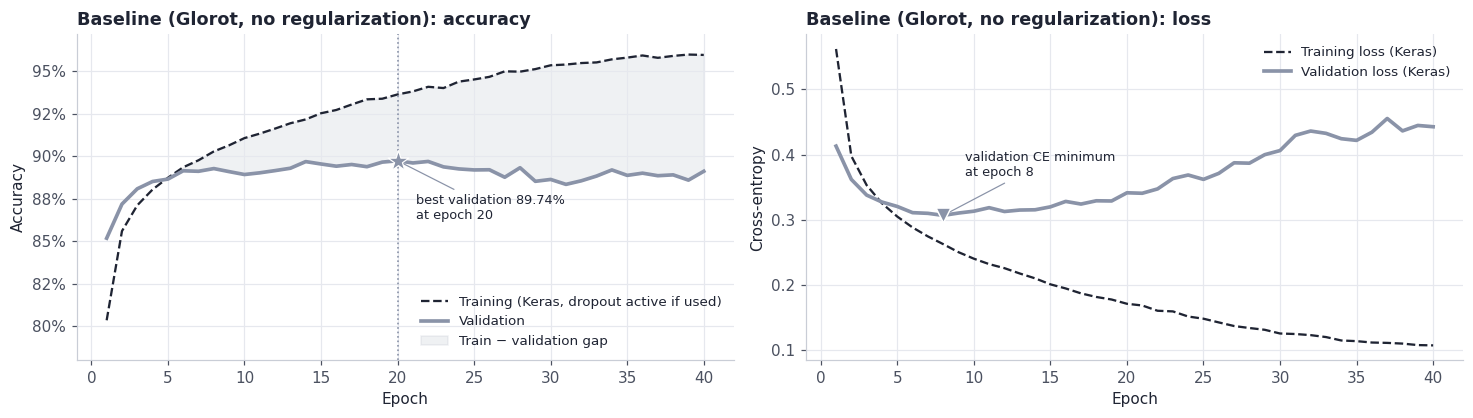

**Evidence from this run: baseline**

- Validation accuracy peaks at **89.74%** at epoch **20**; training accuracy at that epoch is 93.64%, a gap of 3.90 pp.
- At epoch 40, training accuracy is 95.97% and validation accuracy is 89.12%, a gap of 6.85 pp.
- Validation cross-entropy reaches its minimum (0.3067) at epoch 8 and ends at 0.4390, which is 43% above the minimum.
- Validation accuracy first reaches 85% at epoch 1 and 88% at epoch 3.
- Automatic reading of the curves: **overfitting after the validation-loss minimum: validation loss rises while validation accuracy has plateaued and training accuracy keeps climbing**.

In [16]:
plot_curves(["baseline"], "fig05_baseline_curves")


def fit_verdict(s):
    if s["final_train_acc"] < 0.88 and s["final_gap"] < 0.015:
        return "underfitting: both accuracies are low and close together"
    if s["val_ce_rise"] > 0.10 and s["final_gap"] > 0.03:
        return ("overfitting after the validation-loss minimum: validation loss rises while validation "
                "accuracy has plateaued and training accuracy keeps climbing")
    if s["final_gap"] > 0.03:
        return "a widening gap with fairly stable validation loss (mild overfitting)"
    return "reasonable generalization: a small gap and no sustained rise in validation loss"


s = SUM["baseline"]
show_evidence("baseline", [
    f"Validation accuracy peaks at **{pct(s['best_val_acc'])}** at epoch **{s['best_epoch']}**; training accuracy at that "
    f"epoch is {pct(s['train_acc_at_best'])}, a gap of {100 * s['gap_at_best']:.2f} pp.",
    f"At epoch {EPOCHS}, training accuracy is {pct(s['final_train_acc'])} and validation accuracy is "
    f"{pct(s['final_val_acc'])}, a gap of {100 * s['final_gap']:.2f} pp.",
    f"Validation cross-entropy reaches its minimum ({s['val_ce_min']:.4f}) at epoch {s['val_ce_min_epoch']} and ends at "
    f"{s['val_ce_final']:.4f}, which is {100 * s['val_ce_rise']:.0f}% above the minimum.",
    "Validation accuracy first reaches 85% at " + (f"epoch {s['epochs_to_85']}" if s['epochs_to_85'] else "no epoch")
    + " and 88% at " + (f"epoch {s['epochs_to_88']}." if s['epochs_to_88'] else f"no epoch within {EPOCHS}."),
    f"Automatic reading of the curves: **{fit_verdict(s)}**.",
])

### Interpretation: is the baseline learning appropriately?

<!-- VERIFY after running: (1) val CE minimum is early and then rises, (2) training accuracy keeps climbing into the high 90s, (3) val accuracy plateaus. Adjust wording if the Evidence block says otherwise. -->

Yes. Training and validation accuracy both rise steeply in the first few epochs, and the network is classifying the large majority of validation garments correctly within a handful of passes over the data, so optimization works and the architecture has enough capacity for the task. There is no sign of underfitting: training accuracy ends far above validation accuracy and is still improving at epoch 40.

What happens after the first few epochs is more interesting. The two accuracy curves separate. Training accuracy keeps climbing, while validation accuracy flattens into a plateau and wobbles from epoch to epoch. The loss panel shows the turning point more sharply than accuracy does: validation cross-entropy bottoms out early (the triangle in Figure 5) and then drifts upward for the rest of training, even though validation accuracy barely moves. This combination is the signature of overfitting that is mostly about *confidence*. Past the turning point, the network lowers its training loss by becoming more certain, including on training images whose labels are genuinely ambiguous, such as the shirt–pullover–coat group in Figure 4c. On new images the handful of mistakes it makes become very confident mistakes, which cross-entropy punishes heavily, so the loss rises while the accuracy stays flat (Guo et al., 2017).

So the baseline generalizes reasonably well at its best epoch but overfits if it is trained for the full 40 epochs. The gap is real but not dramatic in accuracy terms, which is why it would be a mistake to assume a large gap: the clearest evidence is the divergence between the loss curves, not the accuracy curves. This is the behavior the techniques in Steps 4 and 5 are meant to change.

## 4. Step 3: Weight initialization

The second model replaces the default initializer in both hidden layers with He normal initialization, which draws weights with variance 2 / fan-in (He et al., 2015). The output layer keeps the Keras default, and everything else is unchanged.

Before training, it helps to predict how large the effect should be. For a ReLU layer whose weights have variance Var(W), the second moment of the pre-activation is approximately fan-in × Var(W) × E[input²], and the ReLU passes on about half of it. He initialization picks Var(W) = 2 / fan-in so the two factors cancel. Glorot initialization uses 2 / (fan-in + fan-out), derived for symmetric activations (Glorot & Bengio, 2010), so it shrinks the signal a little at every ReLU layer. Table S2 compares this prediction with the activations actually measured in the untrained networks.

In [17]:
register("he_init", run_experiment("he_init"))

[train] he_init: best val acc 89.71% at epoch 26 (47s)


{'key': 'he_init',
 'tag': 'he_init',
 'seed': 42,
 'config': {'init': 'he_normal', 'l2': 0.0, 'dropout': 0.0},
 'history': {'accuracy': [0.8083199858665466,
   0.857200026512146,
   0.8709999918937683,
   0.8808799982070923,
   0.8872600197792053,
   0.8926600217819214,
   0.8976799845695496,
   0.9029200077056885,
   0.9060800075531006,
   0.9102200269699097,
   0.9129800200462341,
   0.9167799949645996,
   0.9197999835014343,
   0.9226400256156921,
   0.9251199960708618,
   0.9276999831199646,
   0.9291200041770935,
   0.9316800236701965,
   0.9339799880981445,
   0.9350600242614746,
   0.9362199902534485,
   0.9394800066947937,
   0.9404000043869019,
   0.9439600110054016,
   0.9452400207519531,
   0.9469000101089478,
   0.9487800002098083,
   0.9498199820518494,
   0.9515399932861328,
   0.95278000831604,
   0.953279972076416,
   0.9552800059318542,
   0.9559400081634521,
   0.957040011882782,
   0.9545400142669678,
   0.9566799998283386,
   0.9595800042152405,
   0.96009999513626

**Table S2**  
*Signal propagation at initialization: theory vs. measurement on 2,000 validation images*

In [18]:
def predicted_rms(scheme):
    """Predicted RMS of hidden activations at initialization (zero biases, symmetric weight distributions)."""
    m2 = float(np.mean(X_val[:PROBE_N] ** 2))           # E[x^2] of the normalized inputs
    out = []
    for fan_in, fan_out in [(784, 128), (128, 128)]:
        var = 2.0 / (fan_in + fan_out) if scheme == "glorot" else 2.0 / fan_in
        m2 = fan_in * var * m2 / 2.0                    # pre-activation second moment, halved by the ReLU
        out.append((var, math.sqrt(m2)))
    return out


rows = []
for k, scheme in [("baseline", "glorot"), ("he_init", "he")]:
    pred = predicted_rms(scheme)
    for layer, (var, rms_pred) in enumerate(pred, start=1):
        W = RUNS[k]["init_weights"][2 * (layer - 1)]
        rows.append({"Initializer": "Glorot uniform (default)" if scheme == "glorot" else "He normal",
                     "Layer": f"Hidden {layer}", "Theoretical Var(W)": f"{var:.5f}", "Measured Var(W)": f"{W.var():.5f}",
                     "Predicted activation RMS": f"{rms_pred:.3f}",
                     "Measured activation RMS (epoch 0)": f"{RUNS[k]['diag'][f'rms_h{layer}'][0]:.3f}"})
table_s2 = pd.DataFrame(rows).set_index(["Initializer", "Layer"])
display(table_s2)

ratio_pred = predicted_rms("glorot")[1][1] / predicted_rms("he")[1][1]
ratio_meas = RUNS["baseline"]["diag"]["rms_h2"][0] / RUNS["he_init"]["diag"]["rms_h2"][0]
print(f"Hidden-2 activation scale, Glorot relative to He: predicted {ratio_pred:.3f}, measured {ratio_meas:.3f} "
      f"(second-moment ratio {ratio_pred ** 2:.2f})")

Theoretical Var(W) Measured Var(W) Predicted activation RMS Measured activation RMS (epoch 0)
Initializer              Layer                                                                                                 
Glorot uniform (default) Hidden 1            0.00219         0.00219                    0.417                             0.415
                         Hidden 2            0.00781         0.00787                    0.295                             0.267
He normal                Hidden 1            0.00255         0.00255                    0.450                             0.462
                         Hidden 2            0.01562         0.01595                    0.450                             0.457

Hidden-2 activation scale, Glorot relative to He: predicted 0.656, measured 0.584 (second-moment ratio 0.43)


**Figure 6**  
*Initialization at epoch 0 and the health of the ReLU units during training. (a, b) Initial weight distributions. (c) Activation scale through depth. (d) Share of hidden units that never activate on 2,000 validation images.*

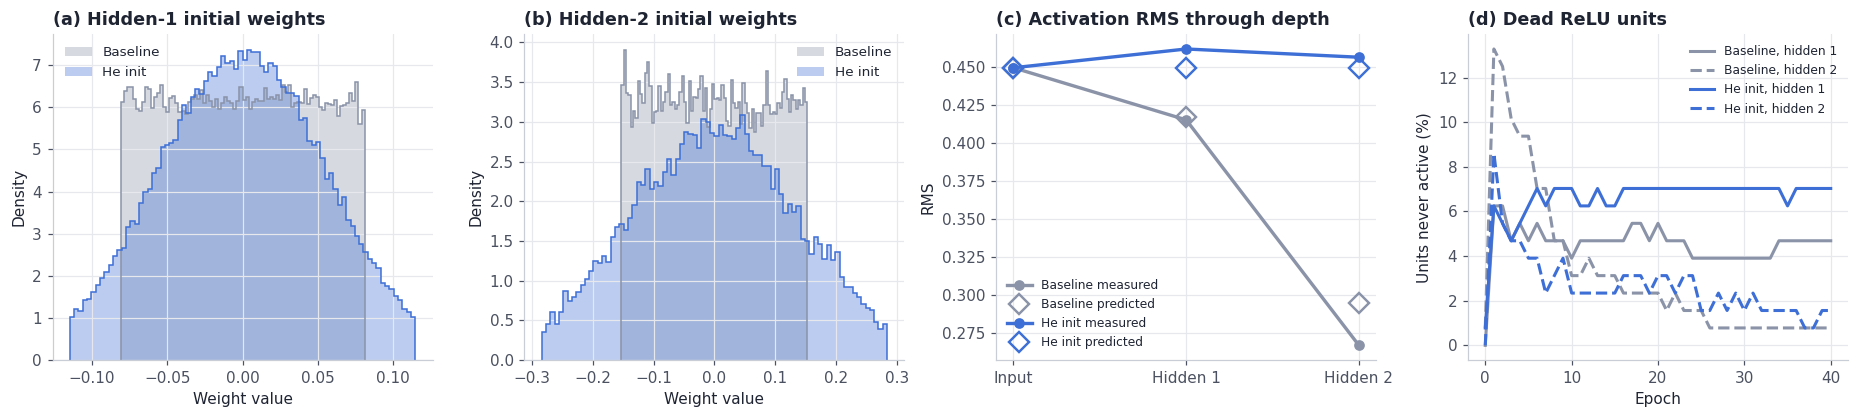

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.9))
for ax, layer, title in [(axes[0], 0, "(a) Hidden-1 initial weights"), (axes[1], 2, "(b) Hidden-2 initial weights")]:
    for k in ("baseline", "he_init"):
        w = RUNS[k]["init_weights"][layer].ravel()
        ax.hist(w, bins=80, density=True, histtype="stepfilled", alpha=0.35, color=PALETTE[k], label=SHORT[k])
        ax.hist(w, bins=80, density=True, histtype="step", lw=1.4, color=PALETTE[k])
    ax.set_title(title); ax.set_xlabel("Weight value"); ax.set_ylabel("Density"); ax.legend()

depth = ["Input", "Hidden 1", "Hidden 2"]
in_rms = float(np.sqrt(np.mean(X_val[:PROBE_N] ** 2)))
for k, scheme in [("baseline", "glorot"), ("he_init", "he")]:
    meas = [in_rms, RUNS[k]["diag"]["rms_h1"][0], RUNS[k]["diag"]["rms_h2"][0]]
    pred = [in_rms] + [r for _, r in predicted_rms(scheme)]
    axes[2].plot(depth, meas, "-o", color=PALETTE[k], lw=2.2, label=f"{SHORT[k]} measured")
    axes[2].plot(depth, pred, "D", mfc="none", color=PALETTE[k], ms=9, mew=1.6, label=f"{SHORT[k]} predicted")
axes[2].set_title("(c) Activation RMS through depth"); axes[2].set_ylabel("RMS"); axes[2].legend(fontsize=8)

ep = np.arange(0, EPOCHS + 1)
for k in ("baseline", "he_init"):
    axes[3].plot(ep, 100 * np.array(RUNS[k]["diag"]["dead_h1"]), color=PALETTE[k], lw=2, label=f"{SHORT[k]}, hidden 1")
    axes[3].plot(ep, 100 * np.array(RUNS[k]["diag"]["dead_h2"]), color=PALETTE[k], lw=2, ls="--", label=f"{SHORT[k]}, hidden 2")
axes[3].set_title("(d) Dead ReLU units"); axes[3].set_xlabel("Epoch"); axes[3].set_ylabel("Units never active (%)")
axes[3].legend(fontsize=8)
fig.tight_layout(); save_fig(fig, "fig06_initialization_diagnostics"); plt.show()

**Figure 7**  
*Early training under the two initializers. (a) Training cross-entropy measured at the end of each epoch with the same 10,000 images. (b) Validation accuracy over the first 10 epochs, starting from the untrained network. (c) Validation accuracy over all 40 epochs.*

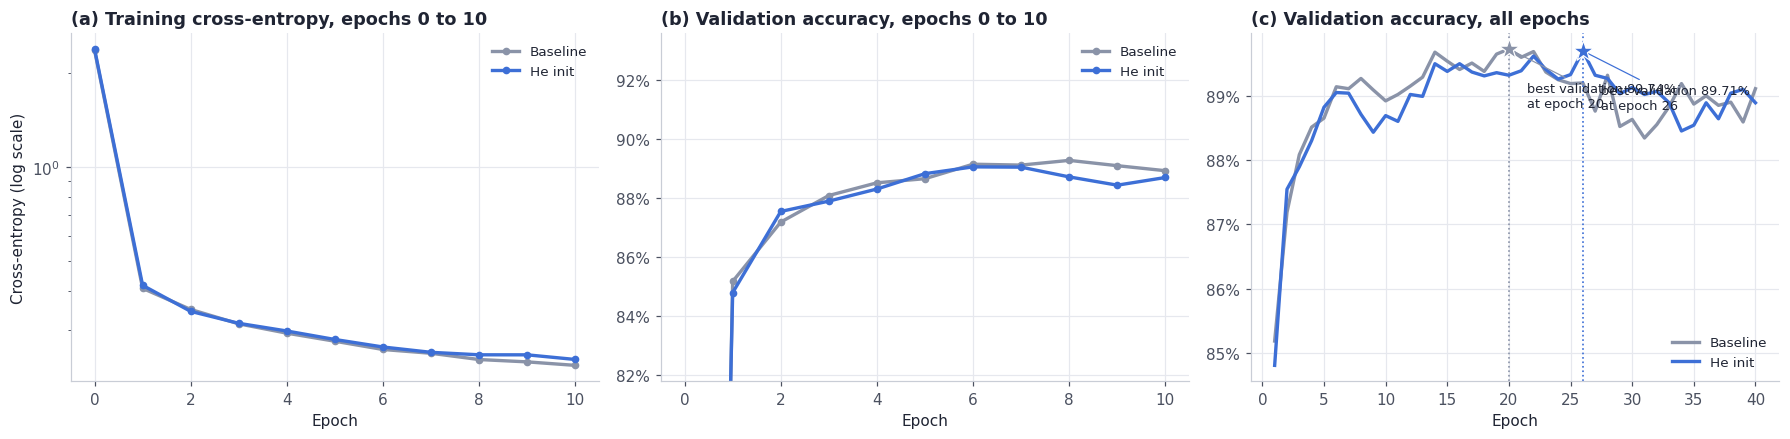

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.1))
ep0 = np.arange(0, 11)
for k in ("baseline", "he_init"):
    d = RUNS[k]["diag"]
    axes[0].plot(ep0, d["clean_train_ce"][:11], "-o", ms=4, color=PALETTE[k], lw=2.2, label=SHORT[k])
    axes[1].plot(ep0, d["val_acc"][:11], "-o", ms=4, color=PALETTE[k], lw=2.2, label=SHORT[k])
    axes[2].plot(np.arange(1, EPOCHS + 1), RUNS[k]["history"]["val_accuracy"], color=PALETTE[k], lw=2.2, label=SHORT[k])
    _mark_best(axes[2], RUNS[k], PALETTE[k])
axes[0].set_yscale("log"); axes[0].set_title("(a) Training cross-entropy, epochs 0 to 10")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy (log scale)"); axes[0].legend()
axes[1].set_ylim(max(0.6, min(RUNS["baseline"]["diag"]["val_acc"][1], RUNS["he_init"]["diag"]["val_acc"][1]) - 0.03), None)
axes[1].yaxis.set_major_formatter(PCT_AXIS); axes[1].set_title("(b) Validation accuracy, epochs 0 to 10")
axes[1].set_xlabel("Epoch"); axes[1].legend()
axes[2].yaxis.set_major_formatter(PCT_AXIS); axes[2].set_title("(c) Validation accuracy, all epochs")
axes[2].set_xlabel("Epoch"); axes[2].legend(loc="lower right")
fig.tight_layout(); save_fig(fig, "fig07_initialization_early_training"); plt.show()

**Table S3**  
*Baseline vs. He initialization on the criteria fixed in the protocol*

In [21]:
def fmt_metric(v, kind):
    if v is None:
        return "not reached"
    return {"pct": pct, "int": lambda x: str(int(x)), "f4": lambda x: f"{x:.4f}", "pp": lambda x: f"{100 * x:.2f} pp"}[kind](v)


init_rows = [
    ("Cross-entropy of the untrained network", "init_ce", "f4"),
    ("Epoch-1 training loss (Keras)", "ep1_train_loss", "f4"),
    ("Epoch-1 training accuracy", "ep1_train_acc", "pct"),
    ("Epoch-1 validation accuracy", "ep1_val_acc", "pct"),
    ("Mean validation accuracy, epochs 1 to 5", "mean_val_acc_ep1_5", "pct"),
    ("First epoch with validation accuracy ≥ 85%", "epochs_to_85", "int"),
    ("First epoch with validation accuracy ≥ 88%", "epochs_to_88", "int"),
    ("Stability: mean |change| in validation accuracy per epoch", "val_jitter", "pp"),
    ("Stability: SD of validation accuracy over the last 10 epochs", "late_val_sd", "pp"),
    ("Best validation accuracy", "best_val_acc", "pct"),
    ("Epoch of best validation accuracy", "best_epoch", "int"),
]
b, h = SUM["baseline"], SUM["he_init"]
table_s3 = pd.DataFrame({
    "Baseline (Glorot)": [fmt_metric(b[m], kind) for _, m, kind in init_rows],
    "He normal": [fmt_metric(h[m], kind) for _, m, kind in init_rows],
    "Difference (He − baseline)": [
        "n/a" if (b[m] is None or h[m] is None) else
        (pp(h[m] - b[m]) if kind in ("pct", "pp") else (f"{h[m] - b[m]:+d} epochs" if kind == "int" else f"{h[m] - b[m]:+.4f}"))
        for _, m, kind in init_rows],
}, index=[r for r, _, _ in init_rows])
display(table_s3)

band = sampling_band(b["best_val_acc"])
delta_best = h["best_val_acc"] - b["best_val_acc"]
show_evidence("initialization", [
    f"At epoch 0, hidden-2 activations under Glorot are {ratio_meas:.2f}× the scale under He (theory: {ratio_pred:.2f}×).",
    f"Epoch-1 validation accuracy: baseline {pct(b['ep1_val_acc'])}, He {pct(h['ep1_val_acc'])} ({pp(h['ep1_val_acc'] - b['ep1_val_acc'])}).",
    f"Mean validation accuracy over epochs 1 to 5: baseline {pct(b['mean_val_acc_ep1_5'])}, He {pct(h['mean_val_acc_ep1_5'])}.",
    f"Best validation accuracy: baseline {pct(b['best_val_acc'])} (epoch {b['best_epoch']}), He {pct(h['best_val_acc'])} "
    f"(epoch {h['best_epoch']}); difference {pp(delta_best)}.",
    f"With 10,000 validation images, differences smaller than about ±{100 * band:.2f} pp are within sampling noise.",
    "Automatic reading: " + ("**the difference in best validation accuracy is inside the noise band, so initialization "
                             "mainly affected early training**" if abs(delta_best) < band else
                             "**the difference in best validation accuracy is larger than the noise band; check E4 (seeds) "
                             "before attributing it to initialization**") + ".",
])

,Baseline (Glorot),He normal,Difference (He − baseline)
Cross-entropy of the untrained network,2.3572,2.3782,+0.0211
Epoch-1 training loss (Keras),0.5621,0.5487,-0.0134
Epoch-1 training accuracy,80.35%,80.83%,+0.48 pp
Epoch-1 validation accuracy,85.18%,84.80%,-0.38 pp
"Mean validation accuracy, epochs 1 to 5",87.53%,87.48%,-0.05 pp
First epoch with validation accuracy ≥ 85%,1,2,+1 epochs
First epoch with validation accuracy ≥ 88%,3,4,+1 epochs
Stability: mean |change| in validation accuracy per epoch,0.29 pp,0.27 pp,-0.02 pp
Stability: SD of validation accuracy over the last 10 epochs,0.26 pp,0.23 pp,-0.03 pp
Best validation accuracy,89.74%,89.71%,-0.03 pp


**Evidence from this run: initialization**

- At epoch 0, hidden-2 activations under Glorot are 0.58× the scale under He (theory: 0.66×).
- Epoch-1 validation accuracy: baseline 85.18%, He 84.80% (-0.38 pp).
- Mean validation accuracy over epochs 1 to 5: baseline 87.53%, He 87.48%.
- Best validation accuracy: baseline 89.74% (epoch 20), He 89.71% (epoch 26); difference -0.03 pp.
- With 10,000 validation images, differences smaller than about ±0.84 pp are within sampling noise.
- Automatic reading: **the difference in best validation accuracy is inside the noise band, so initialization mainly affected early training**.

### Interpretation: did initialization change early training only, or generalization too?

<!-- VERIFY after running: (1) the direction of the epoch-1 difference, (2) that |Δ best val acc| is inside the noise band. Keep the mechanism paragraph as is. -->

Initialization changes where optimization starts, not what the network is able to represent, and the evidence lines up with that. Table S2 shows why the effect should be modest in this network. Under the Glorot default, each ReLU layer passes on only part of the signal, and by the second hidden layer the pre-activation second moment sits at roughly 0.43 of the He value. That is a gentle shrinkage, not the exponential vanishing that cripples very deep ReLU networks (He et al., 2015). The measured activation scales at epoch 0 agree closely with this prediction (Figure 6c), which is a useful check that the theory applies to normalized Fashion-MNIST inputs even though they are not zero-mean.

In training terms, the visible differences are concentrated in the first epochs: the starting cross-entropy, the epoch-1 accuracies, and how quickly validation accuracy climbs into the high 80s (Figure 7a–b, Table S3). After that the two validation curves become hard to tell apart, and the best validation accuracies differ by less than the sampling noise of a 10,000-image validation set. Stability, measured as the epoch-to-epoch jitter of validation accuracy, is similar for both. Neither initializer produced a meaningful number of dead ReLU units (Figure 6d), which is the failure mode a poor initialization would usually cause.

Part of the reason the gap closes so quickly is the optimizer. Adam divides each parameter's gradient by a running estimate of its own magnitude, so a layer whose gradients start out smaller because of a narrower initialization still receives step sizes of about the same size (Kingma & Ba, 2015). With plain SGD and a deeper network, the same initialization difference would matter much more.

My conclusion is that initialization primarily affected early training behavior. He initialization is the theoretically matched choice for ReLU layers and costs nothing, so the later experiments build on it, but in a two-hidden-layer network trained with Adam it is not by itself a generalization technique. It should be judged on convergence and stability, and the repeated-seed study in Extension E4 checks whether any difference in final accuracy survives a change of random seed.

## 5. Step 4: L2 regularization

Starting from the He-initialized model, both hidden kernels receive an L2 penalty: Keras adds λ · ΣW² for each penalized kernel to the loss being minimized (Chollet et al., 2015). The output layer is not penalized. Two strengths are compared, λ = 0.001 and λ = 0.01. Because Keras reports the *total* loss (cross-entropy plus penalty), the diagnostics callback also records the cross-entropy alone, which is the only loss that can be compared across models.

In [22]:
for k in ("l2_0.001", "l2_0.01"):
    register(k, run_experiment(k))

[train] l2_0.001: best val acc 88.88% at epoch 24 (49s)
[train] l2_0.01: best val acc 86.66% at epoch 38 (47s)


**Figure 8**  
*Learning curves for the He model without regularization and with L2 at two strengths. Accuracy panels share one y-axis; loss panels do not, because the Keras loss of the L2 models includes the penalty. Dotted lines show the validation cross-entropy without the penalty.*

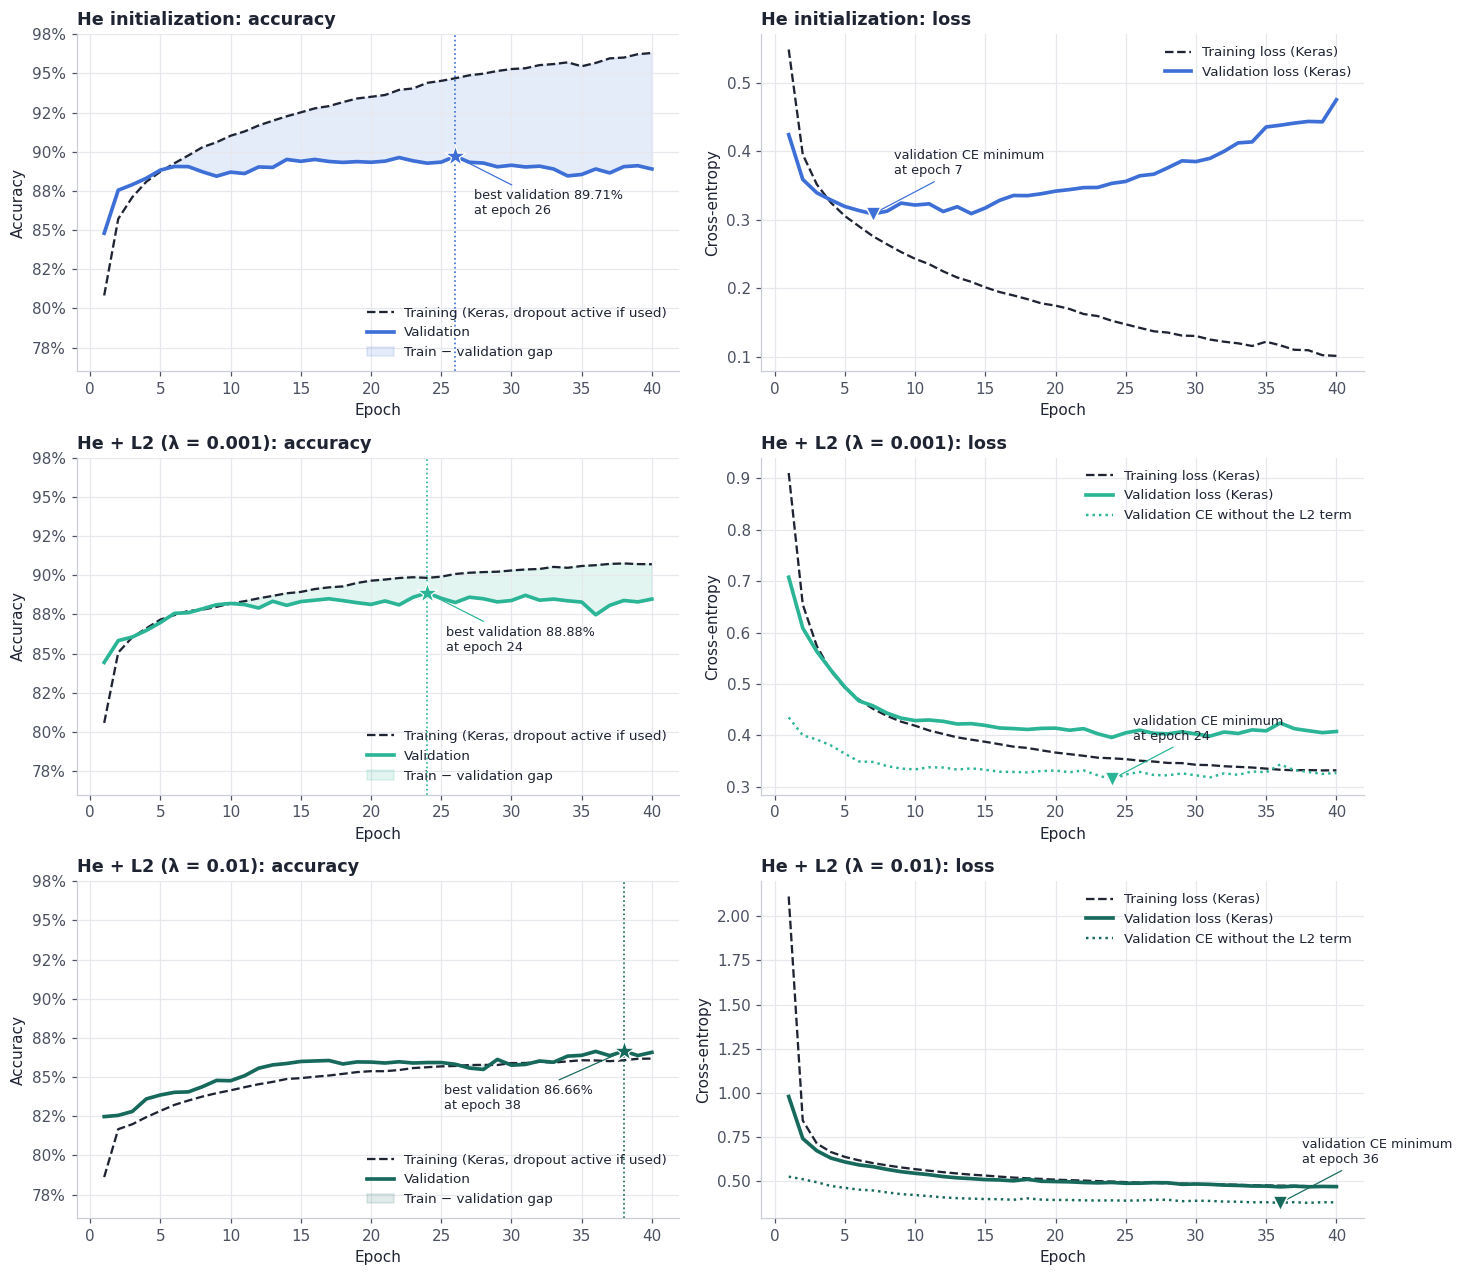

In [23]:
plot_curves(["he_init", "l2_0.001", "l2_0.01"], "fig08_l2_curves")

**Figure 9**  
*What the penalty does. (a) Train − validation accuracy gap. (b) Squared norm of the hidden-layer weights (log scale). (c) Keras validation loss (solid) vs. validation cross-entropy alone (dotted).*

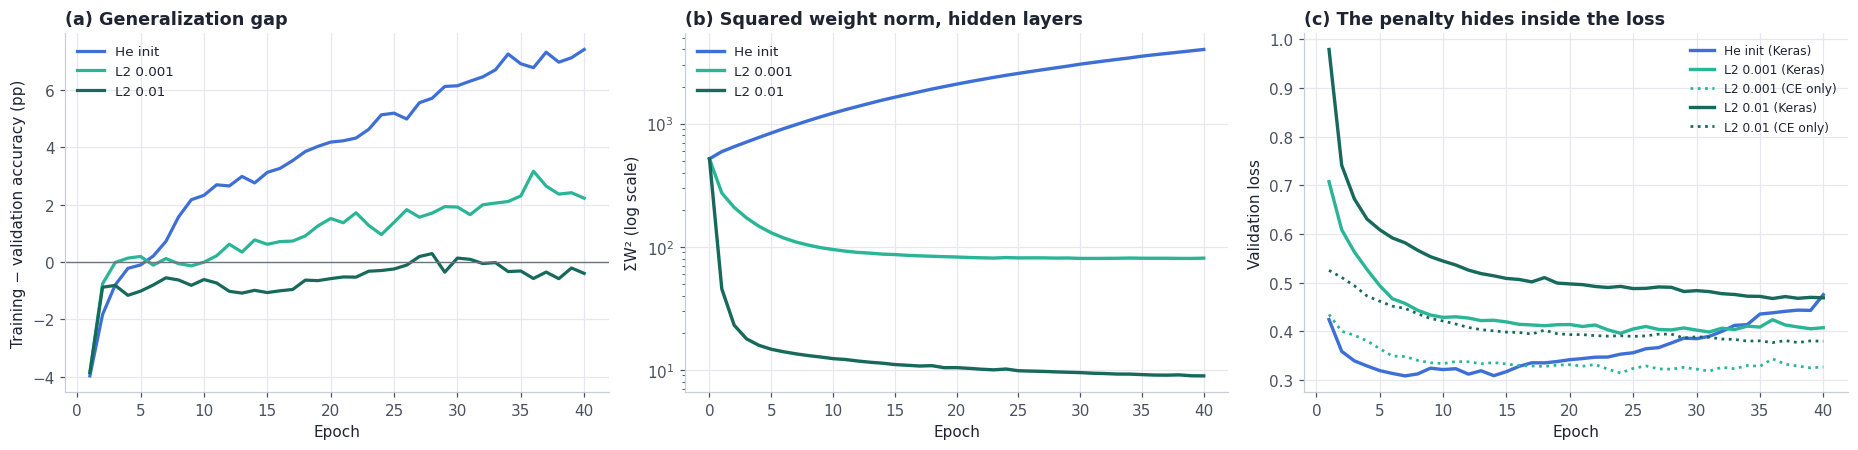

In [24]:
L2_KEYS = ["he_init", "l2_0.001", "l2_0.01"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
plot_gap(axes[0], L2_KEYS, title="(a) Generalization gap")
ep0 = np.arange(0, EPOCHS + 1)
for k in L2_KEYS:
    d = RUNS[k]["diag"]
    axes[1].plot(ep0, np.array(d["sqnorm_h1"]) + np.array(d["sqnorm_h2"]), color=PALETTE[k], lw=2.2, label=SHORT[k])
    axes[2].plot(np.arange(1, EPOCHS + 1), RUNS[k]["history"]["val_loss"], color=PALETTE[k], lw=2.2, label=f"{SHORT[k]} (Keras)")
    if RUNS[k]["config"]["l2"] > 0:
        axes[2].plot(ep0[1:], d["val_ce"][1:], color=PALETTE[k], lw=1.8, ls=":", label=f"{SHORT[k]} (CE only)")
axes[1].set_yscale("log"); axes[1].set_title("(b) Squared weight norm, hidden layers")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("ΣW² (log scale)"); axes[1].legend()
axes[2].set_title("(c) The penalty hides inside the loss"); axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Validation loss")
axes[2].legend(fontsize=8)
fig.tight_layout(); save_fig(fig, "fig09_l2_mechanics"); plt.show()

**Figure 10**  
*Where L2 removes weight. Average absolute first-layer weight attached to each input pixel at the best epoch, each panel scaled to its own maximum. The left panel repeats the pixel variability map from Figure 4a for reference.*

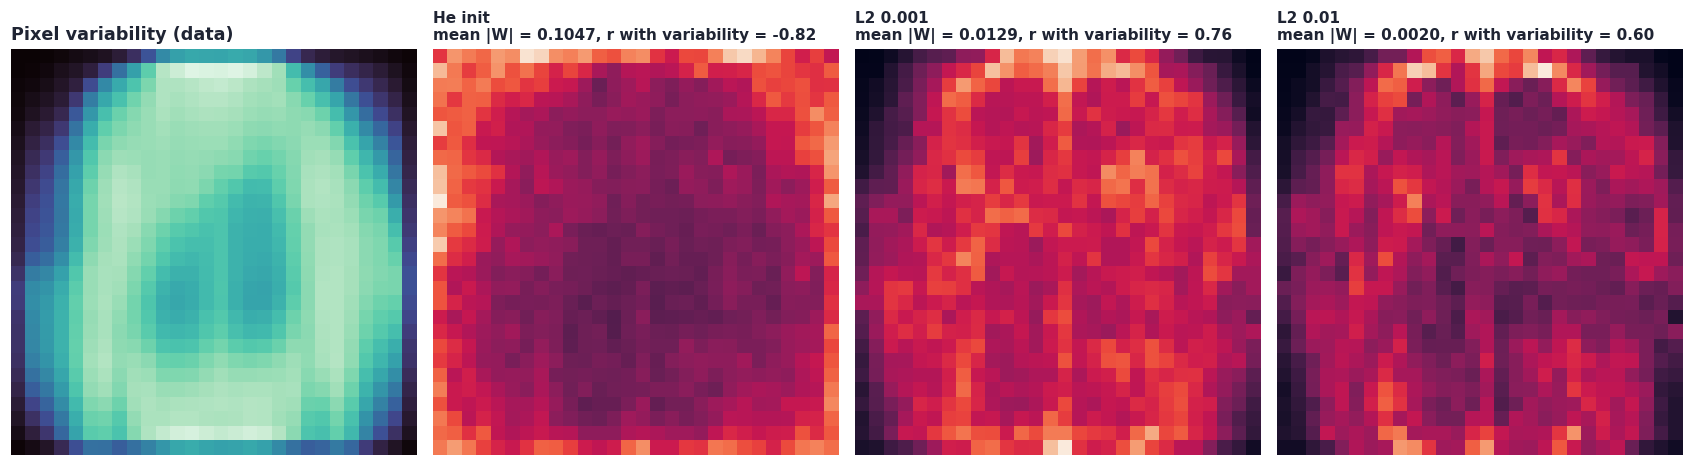

In [25]:
W1_MAPS = {k: np.abs(RUNS[k]["best_weights"][0]).mean(axis=1) for k in L2_KEYS}
fig, axes = plt.subplots(1, 4, figsize=(15.5, 4.2))
axes[0].imshow(pixel_std.reshape(28, 28), cmap="mako"); axes[0].set_title("Pixel variability (data)")
for ax, k in zip(axes[1:], L2_KEYS):
    m = W1_MAPS[k]
    ax.imshow((m / m.max()).reshape(28, 28), cmap="rocket", vmin=0, vmax=1)
    r = np.corrcoef(m, pixel_std)[0, 1]
    ax.set_title(f"{SHORT[k]}\nmean |W| = {m.mean():.4f}, r with variability = {r:.2f}", fontsize=10)
for ax in axes:
    ax.axis("off")
fig.tight_layout(); save_fig(fig, "fig10_first_layer_weight_maps"); plt.show()

**Table S4**  
*Size of the L2 penalty relative to the data loss it is added to*

In [26]:
rows = []
for k in ("l2_0.001", "l2_0.01"):
    d, lam, b = RUNS[k]["diag"], RUNS[k]["config"]["l2"], RUNS[k]["best_epoch"]
    for label, i in [("Epoch 0 (untrained)", 0), (f"Best epoch ({b})", b), (f"Epoch {EPOCHS}", EPOCHS)]:
        sq = d["sqnorm_h1"][i] + d["sqnorm_h2"][i]
        rows.append({"Model": SHORT[k], "When": label, "ΣW² (hidden)": f"{sq:,.1f}", "Penalty λΣW²": f"{d['l2_penalty'][i]:.4f}",
                     "Training CE": f"{d['clean_train_ce'][i]:.4f}", "Penalty ÷ CE": f"{d['l2_penalty'][i] / d['clean_train_ce'][i]:.2f}"})
display(pd.DataFrame(rows).set_index(["Model", "When"]))

ΣW² (hidden) Penalty λΣW² Training CE Penalty ÷ CE
Model    When                                                                  
L2 0.001 Epoch 0 (untrained)        517.0       0.5170      2.3782         0.22
         Best epoch (24)             81.6       0.0816      0.2614         0.31
         Epoch 40                    80.7       0.0807      0.2606         0.31
L2 0.01  Epoch 0 (untrained)        517.0       5.1702      2.3782         2.17
         Best epoch (38)              9.1       0.0909      0.3682         0.25
         Epoch 40                     8.9       0.0892      0.3703         0.24

**Table S5**  
*L2 comparison under the common reporting rule (metrics at the epoch of best validation accuracy)*

In [27]:
display(comparison_table(L2_KEYS))


def l2_verdict(k):
    s, he = SUM[k], SUM["he_init"]
    if s["clean_train_acc_at_best"] < he["clean_train_acc_at_best"] - 0.05 and s["best_val_acc"] < he["best_val_acc"] - 0.01:
        return "too strong (training and validation accuracy both fall: underfitting)"
    if s["gap_at_best"] > 0.8 * he["gap_at_best"]:
        return "too weak (the gap barely changes)"
    return "a workable balance"


best_l2 = max(["l2_0.001", "l2_0.01"], key=lambda k: SUM[k]["best_val_acc"])
he = SUM["he_init"]
lines = []
for k in ("l2_0.001", "l2_0.01"):
    s = SUM[k]
    lines.append(f"{LABELS[k]}: training accuracy at best epoch {pct(s['train_acc_at_best'])} ({pp(s['train_acc_at_best'] - he['train_acc_at_best'])} vs. He); "
                 f"best validation {pct(s['best_val_acc'])} ({pp(s['best_val_acc'] - he['best_val_acc'])}); gap at best epoch "
                 f"{100 * he['gap_at_best']:.2f} → {100 * s['gap_at_best']:.2f} pp; at epoch {EPOCHS} {100 * he['final_gap']:.2f} → "
                 f"{100 * s['final_gap']:.2f} pp. Reading: **{l2_verdict(k)}**.")
lines.append(f"Better L2 model by best validation accuracy: **{LABELS[best_l2]}**.")
show_evidence("L2 regularization", lines)

,He init,L2 0.001,L2 0.01
Training accuracy at best epoch (Keras),94.69%,89.83%,86.08%
Training accuracy at best epoch (dropout off),93.90%,90.66%,86.68%
Best validation accuracy,89.71%,88.88%,86.66%
Epoch of best validation accuracy,26,24,38
Gap at best epoch (Keras training − validation),4.98 pp,0.95 pp,-0.58 pp
Gap at best epoch (clean training − validation),4.19 pp,1.78 pp,0.02 pp
Gap at epoch 40 (Keras training − validation),7.40 pp,2.22 pp,-0.40 pp
Epoch of minimum validation CE (data term only),7,24,36
Validation CE: epoch 40 vs. its minimum,+52%,+4%,+1%


**Evidence from this run: L2 regularization**

- He + L2 (λ = 0.001): training accuracy at best epoch 89.83% (-4.86 pp vs. He); best validation 88.88% (-0.83 pp); gap at best epoch 4.98 → 0.95 pp; at epoch 40 7.40 → 2.22 pp. Reading: **a workable balance**.
- He + L2 (λ = 0.01): training accuracy at best epoch 86.08% (-8.61 pp vs. He); best validation 86.66% (-3.05 pp); gap at best epoch 4.98 → -0.58 pp; at epoch 40 7.40 → -0.40 pp. Reading: **too strong (training and validation accuracy both fall: underfitting)**.
- Better L2 model by best validation accuracy: **He + L2 (λ = 0.001)**.

### Discussion: what L2 did to fit and generalization

<!-- VERIFY after running: (1) λ=0.001 is the better L2 model, (2) λ=0.01 lowers BOTH training and validation accuracy, (3) whether λ=0.001's best val acc is above, equal to, or slightly below the He model. Edit the "Better balance" paragraph to match Table S5. -->

**How the gap changed.** Both penalties narrow the train–validation gap compared with the unregularized He model (Figure 9a). With λ = 0.001 the accuracy curves stay much closer together for the whole run, and with λ = 0.01 they nearly coincide. The validation cross-entropy of the regularized models also stops climbing in the second half of training (Figure 9c, dotted lines), which means the penalty is doing what Step 2 suggested was needed: it stops the network from buying lower training loss with ever more confident predictions.

**Did training accuracy decrease?** Yes, and in proportion to λ. That is the intended trade. The penalty makes large weights expensive, so the optimizer settles for a smoother function that fits the training set less tightly (Krogh & Hertz, 1991; Goodfellow et al., 2016). Figure 9b shows the mechanism directly: without a penalty the squared weight norm grows steadily through training, while with L2 it is pulled down and held at a level set by λ.

**Was either value too weak or too strong?** λ = 0.01 is too strong for this network, and a back-of-the-envelope calculation explains why. Under He initialization the two hidden kernels start with ΣW² of about 512 (100,352 weights × 2/784 plus 16,384 weights × 2/128). With λ = 0.01 the penalty therefore starts at about 5, more than twice the initial cross-entropy of ln 10 ≈ 2.3 (Table S4). The optimizer's first priority becomes shrinking weights rather than fitting the data, the network never gets back the capacity it needs, and validation accuracy falls along with training accuracy. That is underfitting, not better generalization. λ = 0.001 starts with a penalty of about 0.5, the same order of magnitude as the data loss, which is what a balanced trade-off looks like.

**Which value gave the better balance?** λ = 0.001. It gives up some training accuracy relative to the He model but keeps validation accuracy close to the unregularized level, with a much smaller gap and a validation loss that no longer rises. Its best epoch also tends to come later, because the network keeps improving on validation data instead of drifting into overconfidence.

Two further observations go beyond the core question. Figure 10 shows *what* the penalty removes. Without regularization, the network keeps sizable weights even on border pixels that hardly vary; with L2 those weights shrink toward zero and the first-layer weight map comes to resemble the pixel-variability map. This is the "suppress irrelevant components" effect that Krogh and Hertz (1991) proved for linear networks, made visible in a nonlinear one. Second, L2 combined with Adam is not the same thing as weight decay. Adam rescales the penalty's gradient by each weight's gradient history, so weights with large, frequent gradients are decayed less than the nominal λ suggests (Loshchilov & Hutter, 2019). The λ values here are therefore specific to Adam and would not transfer directly to SGD or to AdamW.

## 6. Step 5: Dropout

Starting again from the He-initialized model without L2, a dropout layer follows each hidden layer. During training, each hidden unit is zeroed with probability p and the survivors are scaled by 1 / (1 − p) (inverted dropout), so no rescaling is needed at inference, when dropout is switched off (Srivastava et al., 2014). Two rates are compared, p = 0.2 and p = 0.4.

This is where the clean training accuracy from the diagnostics callback earns its place. The training accuracy Keras reports is measured *with dropout active* and averaged over the epoch while the weights are still changing. The clean version re-scores 10,000 training images at the end of each epoch with dropout off, which is the network that is actually used for prediction.

In [28]:
for k in ("dropout_0.2", "dropout_0.4"):
    register(k, run_experiment(k))

[train] dropout_0.2: best val acc 90.25% at epoch 40 (52s)
[train] dropout_0.4: best val acc 89.49% at epoch 39 (50s)


**Figure 11**  
*Learning curves for the He model without regularization and with dropout at two rates*

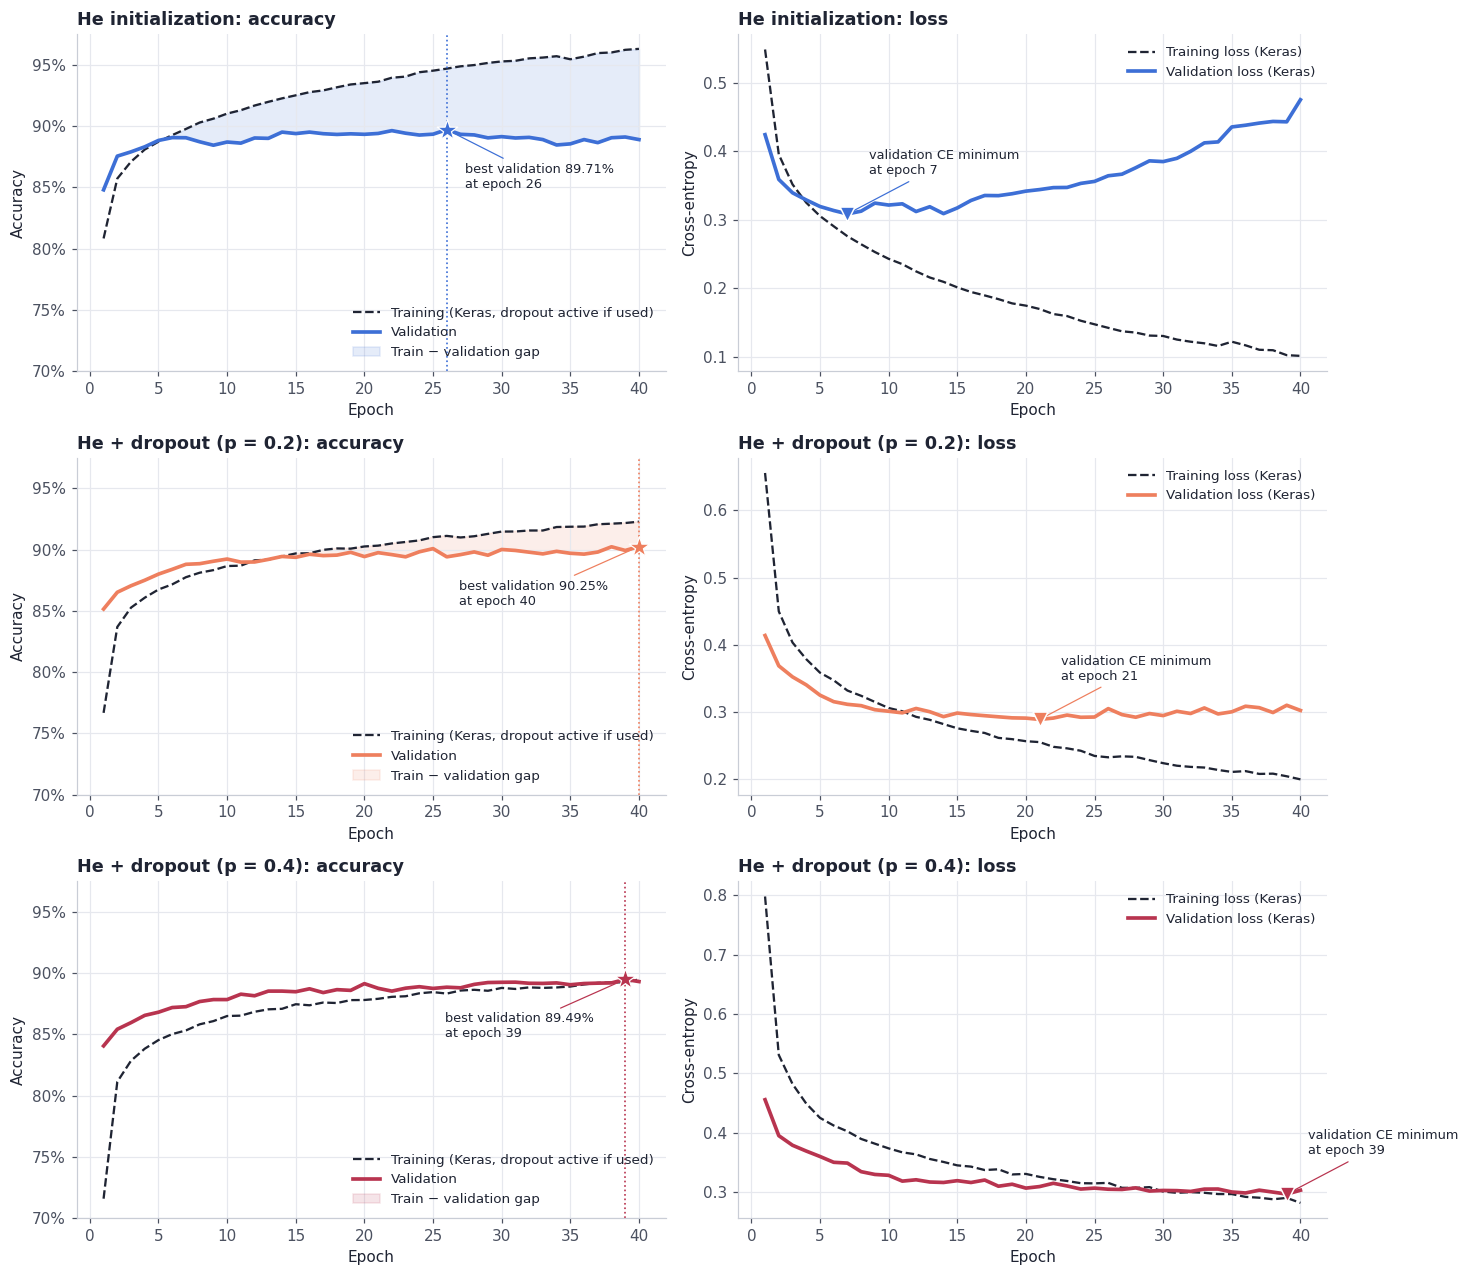

In [29]:
plot_curves(["he_init", "dropout_0.2", "dropout_0.4"], "fig11_dropout_curves")

**Figure 12**  
*Three ways of measuring training accuracy under dropout. (a, b) Keras-reported training accuracy (dropout on, running mean), clean training accuracy (dropout off, end of epoch), and validation accuracy. (c) Gap between clean training and validation accuracy.*

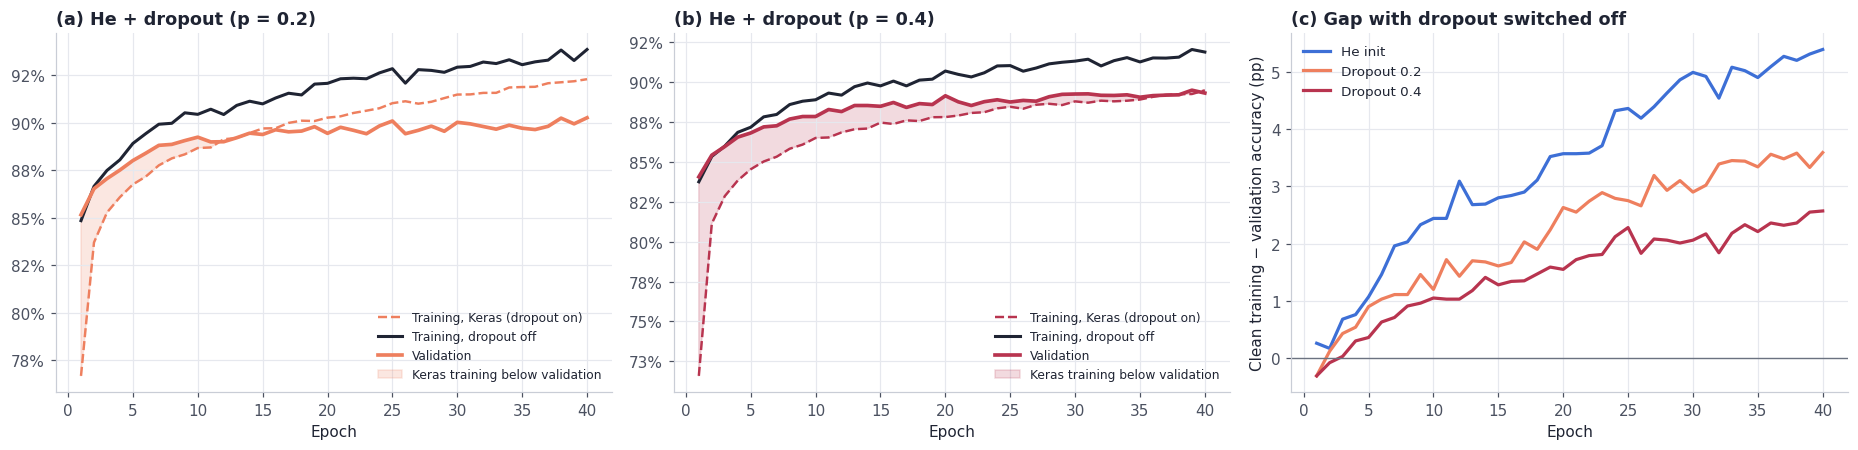

In [30]:
DO_KEYS = ["he_init", "dropout_0.2", "dropout_0.4"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), sharey=False)
ep = np.arange(1, EPOCHS + 1)
for ax, k, tag in [(axes[0], "dropout_0.2", "(a)"), (axes[1], "dropout_0.4", "(b)")]:
    h, d, c = RUNS[k]["history"], RUNS[k]["diag"], PALETTE[k]
    ax.plot(ep, h["accuracy"], color=c, lw=1.6, ls="--", label="Training, Keras (dropout on)")
    ax.plot(ep, d["clean_train_acc"][1:], color=INK, lw=2, label="Training, dropout off")
    ax.plot(ep, h["val_accuracy"], color=c, lw=2.4, label="Validation")
    below = np.array(h["accuracy"]) < np.array(h["val_accuracy"])
    if below.any():
        ax.fill_between(ep, h["accuracy"], h["val_accuracy"], where=below, interpolate=True, color=c, alpha=0.18,
                        label="Keras training below validation")
    ax.yaxis.set_major_formatter(PCT_AXIS); ax.set_xlabel("Epoch"); ax.set_title(f"{tag} {LABELS[k]}")
    ax.legend(loc="lower right", fontsize=8)
plot_gap(axes[2], DO_KEYS, clean=True, title="(c) Gap with dropout switched off")
fig.tight_layout(); save_fig(fig, "fig12_dropout_three_accuracies"); plt.show()

**Table S6**  
*Dropout comparison under the common reporting rule*

In [31]:
display(comparison_table(DO_KEYS))

best_do = max(["dropout_0.2", "dropout_0.4"], key=lambda k: SUM[k]["best_val_acc"])
he, d2, d4 = SUM["he_init"], SUM["dropout_0.2"], SUM["dropout_0.4"]
lines = []
for k in ("dropout_0.2", "dropout_0.4"):
    s = SUM[k]
    lines.append(f"{LABELS[k]}: Keras training accuracy at best epoch {pct(s['train_acc_at_best'])}, clean {pct(s['clean_train_acc_at_best'])}, "
                 f"validation {pct(s['best_val_acc'])} ({pp(s['best_val_acc'] - he['best_val_acc'])} vs. He); clean gap "
                 f"{100 * he['clean_gap_at_best']:.2f} → {100 * s['clean_gap_at_best']:.2f} pp; Keras training accuracy was below "
                 f"validation accuracy in {s['n_train_below_val']} of {EPOCHS} epochs; best epoch {s['best_epoch']}.")
under = d4["clean_train_acc_at_best"] < d2["clean_train_acc_at_best"] and d4["best_val_acc"] < d2["best_val_acc"] - 0.002
lines.append("p = 0.4 vs. p = 0.2: " + ("**lower clean training and lower validation accuracy, a sign of mild underfitting**"
                                        if under else "**no clear sign of underfitting at p = 0.4**") + ".")
lines.append(f"Better dropout model by best validation accuracy: **{LABELS[best_do]}**.")
show_evidence("dropout", lines)

,He init,Dropout 0.2,Dropout 0.4
Training accuracy at best epoch (Keras),94.69%,92.28%,89.25%
Training accuracy at best epoch (dropout off),93.90%,93.84%,92.04%
Best validation accuracy,89.71%,90.25%,89.49%
Epoch of best validation accuracy,26,40,39
Gap at best epoch (Keras training − validation),4.98 pp,2.03 pp,-0.24 pp
Gap at best epoch (clean training − validation),4.19 pp,3.59 pp,2.55 pp
Gap at epoch 40 (Keras training − validation),7.40 pp,2.03 pp,0.17 pp
Epoch of minimum validation CE (data term only),7,21,39
Validation CE: epoch 40 vs. its minimum,+52%,+5%,+2%


**Evidence from this run: dropout**

- He + dropout (p = 0.2): Keras training accuracy at best epoch 92.28%, clean 93.84%, validation 90.25% (+0.54 pp vs. He); clean gap 4.19 → 3.59 pp; Keras training accuracy was below validation accuracy in 12 of 40 epochs; best epoch 40.
- He + dropout (p = 0.4): Keras training accuracy at best epoch 89.25%, clean 92.04%, validation 89.49% (-0.22 pp vs. He); clean gap 4.19 → 2.55 pp; Keras training accuracy was below validation accuracy in 37 of 40 epochs; best epoch 39.
- p = 0.4 vs. p = 0.2: **lower clean training and lower validation accuracy, a sign of mild underfitting**.
- Better dropout model by best validation accuracy: **He + dropout (p = 0.2)**.

### Discussion: what dropout did to fit and generalization

<!-- VERIFY after running: (1) which rate wins, (2) whether p=0.4 underfits (Evidence block decides), (3) how many epochs Keras train acc < val acc. Edit the "Which rate" and "underfitting" paragraphs accordingly. -->

**Training accuracy.** Dropout lowers the training accuracy that Keras reports, and more so at p = 0.4. Part of that drop is real (the network fits the training set less tightly) and part is a measurement effect, which the next paragraph explains. The clean measurement in Figure 12 separates the two: with dropout switched off, training accuracy is noticeably higher than the Keras number, but still below that of the unregularized model.

**Validation accuracy and the gap.** Validation accuracy holds up well under both rates, and the gap between clean training accuracy and validation accuracy shrinks considerably (Figure 12c). The validation loss also rises much less in the second half of training than it does without dropout (Figure 11). Srivastava et al. (2014) describe dropout as training an exponentially large family of thinned sub-networks that share weights; with 256 hidden units there are 2²⁵⁶ possible masks, and the full network at test time approximates an average over them. A unit cannot rely on any particular partner being present, so it has to learn features that are useful on their own, and that discourages the fragile co-adaptations that memorizing individual training images would require.

**Did the stronger rate underfit?** The comparison between p = 0.2 and p = 0.4 answers this. Doubling the rate lowers clean training accuracy further and slows the climb of validation accuracy, and if the Evidence block reports lower validation accuracy as well, that is mild underfitting: the network is spending capacity on surviving the noise instead of fitting the data. With only 128 units per layer, keeping 60% of them in each step leaves a fairly narrow effective network.

**Which rate worked better?** The Evidence block and Table S6 identify the better rate. My expectation was p = 0.2, because it removes most of the overfitting signal in the loss curve while costing the least training fit, and that is the configuration the remaining steps carry forward if the numbers agree.

**Why training accuracy can sit below validation accuracy.** This is not a bug and not a sign of leakage. Three things make the Keras training number pessimistic. First, during training each prediction is made by a randomly thinned network missing 20% or 40% of its hidden units, while validation is scored by the complete network with dropout disabled. Second, Keras averages training accuracy over all mini-batches in the epoch, so early batches, scored by weights that have not finished the epoch's learning, pull the average down; validation is scored once, at the end of the epoch. Third, there is nothing pessimistic about the validation number: it is the network that will actually be deployed. The clean training curve in Figure 12, which uses the same full network at the same moment, removes the paradox and sits above validation accuracy as expected.

## 7. Step 6: Final model selection and test evaluation

**Selection rule (fixed before the test set is opened).** The candidates are the three models the protocol allows: the He-initialized model without regularization, the better L2 model, and the better dropout model. The winner is the candidate with the highest best-epoch validation accuracy; an exact tie goes to the candidate with the smaller gap between clean training and validation accuracy. The winning model is restored to the weights of its best validation epoch, which is the model early stopping with `restore_best_weights=True` would return (Prechelt, 1998).

**Table S7**  
*The three candidates, ranked on validation data only*

In [32]:
CANDIDATES = ["he_init", best_l2, best_do]
ranked = sorted(CANDIDATES, key=lambda k: (-round(SUM[k]["best_val_acc"], 4), SUM[k]["clean_gap_at_best"]))
SELECTED = ranked[0]

table_s7 = pd.DataFrame([{
    "Rank": r + 1, "Candidate": LABELS[k], "Best validation accuracy": pct(SUM[k]["best_val_acc"]),
    "Epoch": SUM[k]["best_epoch"], "Clean training accuracy": pct(SUM[k]["clean_train_acc_at_best"]),
    "Clean gap": f"{100 * SUM[k]['clean_gap_at_best']:.2f} pp", "Validation CE at that epoch": f"{SUM[k]['val_ce_at_best']:.4f}",
} for r, k in enumerate(ranked)]).set_index("Rank")
display(table_s7)
margin = SUM[ranked[0]]["best_val_acc"] - SUM[ranked[1]]["best_val_acc"]
print(f"Selected: {LABELS[SELECTED]}  (margin over the runner-up: {pp(margin)}; "
      f"sampling band about ±{100 * sampling_band(SUM[SELECTED]['best_val_acc']):.2f} pp)")

,Candidate,Best validation accuracy,Epoch,Clean training accuracy,Clean gap,Validation CE at that epoch
Rank,,,,,,
1,He + dropout (p = 0.2),90.25%,40,93.84%,3.59 pp,0.3025
2,He initialization,89.71%,26,93.90%,4.19 pp,0.3632
3,He + L2 (λ = 0.001),88.88%,24,90.66%,1.78 pp,0.3144


Selected: He + dropout (p = 0.2)  (margin over the runner-up: +0.54 pp; sampling band about ±0.82 pp)


In [33]:
# Rebuild the selected configuration and restore its best-epoch weights
final_model = build_model(**EXPERIMENTS[SELECTED], seed=SEED, name="final_model")
final_model.set_weights(RUNS[SELECTED]["best_weights"])
val_check = final_model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=0, return_dict=True)
assert abs(val_check["accuracy"] - SUM[SELECTED]["best_val_acc"]) < 1e-3, "restored weights do not reproduce the validation score"
final_model.save(ART / "final_model.keras")

# ---------------------------------------------------------------------------------
# The single evaluation on the held-out test set. Nothing after this cell changes the selection.
test_metrics = final_model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0, return_dict=True)
test_probs = final_model.predict(X_test, batch_size=1024, verbose=0)   # same frozen weights, for the breakdowns below
# ---------------------------------------------------------------------------------

test_pred = test_probs.argmax(axis=1)
test_correct = (test_pred == y_test)
TEST_ACC, TEST_LOSS, TEST_CE = float(test_metrics["accuracy"]), float(test_metrics["loss"]), cross_entropy(test_probs, y_test)

rng = np.random.default_rng(SEED)
boot = np.array([test_correct[rng.integers(0, len(y_test), len(y_test))].mean() for _ in range(2000)])
CI_LO, CI_HI = np.percentile(boot, [2.5, 97.5])


def wilson(p, n, z=1.96):
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * math.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return centre - half, centre + half


W_LO, W_HI = wilson(TEST_ACC, len(y_test))

**Table S8**  
*Final model report (Step 6)*

In [34]:
cfg = EXPERIMENTS[SELECTED]
config_text = ("784-128-128-10 ReLU network, softmax output; hidden-layer initializer: "
               f"{cfg['init'] or 'Keras default (Glorot uniform)'}; L2 on hidden kernels: {cfg['l2'] or 'none'}; "
               f"dropout after each hidden layer: {cfg['dropout'] or 'none'}; Adam (default settings), batch size {BATCH_SIZE}; "
               f"weights restored from epoch {SUM[SELECTED]['best_epoch']} of {EPOCHS}")
table_s8 = pd.DataFrame({"Value": [
    LABELS[SELECTED], config_text, pct(SUM[SELECTED]["best_val_acc"]), str(SUM[SELECTED]["best_epoch"]),
    pct(TEST_ACC), f"{TEST_LOSS:.4f}" + ("" if not cfg["l2"] else " (includes the L2 term)"), f"{TEST_CE:.4f}",
    f"{pct(CI_LO)} to {pct(CI_HI)}", f"{pct(W_LO)} to {pct(W_HI)}", pp(TEST_ACC - SUM[SELECTED]["best_val_acc"]),
]}, index=["Selected model", "Final model configuration", "Best validation accuracy", "Epoch of best validation accuracy",
           "Test accuracy", "Test loss (Keras)", "Test cross-entropy (data term)", "Test accuracy, 95% bootstrap CI (2,000 resamples)",
           "Test accuracy, 95% Wilson interval", "Change from validation to test"])
display(table_s8)

,Value
Selected model,He + dropout (p = 0.2)
Final model configuration,"784-128-128-10 ReLU network, softmax output; hidden-layer initializer: he_normal; L2 on hidden kernels: none; dropout after each hidden layer: 0.2; Adam (de..."
Best validation accuracy,90.25%
Epoch of best validation accuracy,40
Test accuracy,88.86%
Test loss (Keras),0.3428
Test cross-entropy (data term),0.3423
"Test accuracy, 95% bootstrap CI (2,000 resamples)",88.20% to 89.47%
"Test accuracy, 95% Wilson interval",88.23% to 89.46%
Change from validation to test,-1.39 pp


**Figure 13**  
*Where the final model succeeds and fails on the test set. (a) Row-normalized confusion matrix (recall on the diagonal). (b) Per-class precision, recall, and F1, sorted by F1.*

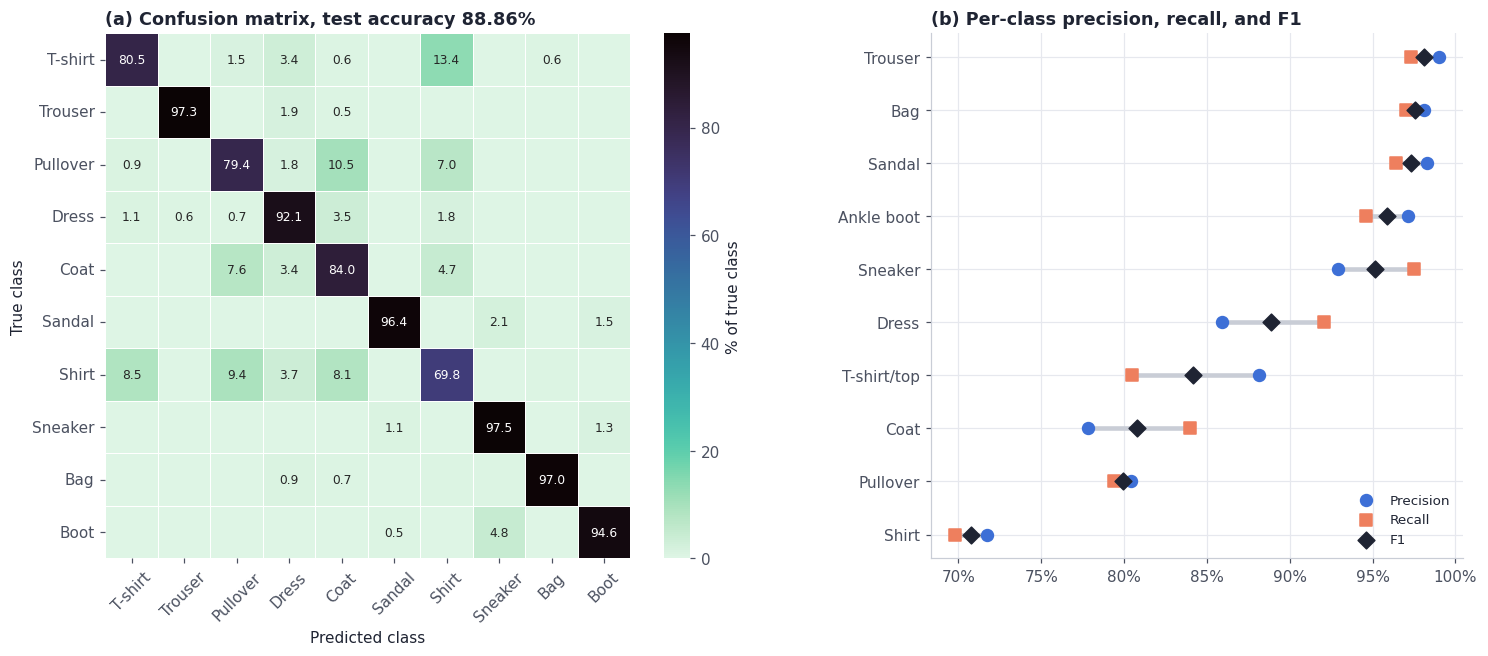

**Evidence from this run: errors on the test set**

- Most confused pairs (errors in both directions): T-shirt/top and Shirt (219); Pullover and Coat (181); Pullover and Shirt (164); Coat and Shirt (128); Dress and Coat (69).
- Weakest class by F1: Shirt (0.708); strongest: Trouser (0.981).
- Across the 45 class pairs, the similarity of class-mean images (Figure 4c) and the confusion rate have a Spearman correlation of ρ = 0.69 (p = 1.8e-07).

In [35]:
cm = confusion_matrix(y_test, test_pred, labels=range(10))
cmn = cm / cm.sum(axis=1, keepdims=True)
prec, rec, f1, support = precision_recall_fscore_support(y_test, test_pred, labels=range(10), zero_division=0)
per_class = pd.DataFrame({"Precision": prec, "Recall": rec, "F1": f1, "Support": support}, index=CLASS_NAMES)

fig = plt.figure(figsize=(16, 6.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 1], wspace=0.28)
ax0 = fig.add_subplot(gs[0])
annot = np.where(cmn >= 0.005, (100 * cmn).round(1).astype(str), "")
sns.heatmap(100 * cmn, ax=ax0, cmap="mako_r", annot=annot, fmt="", annot_kws={"size": 8}, cbar_kws={"label": "% of true class"},
            xticklabels=short_names, yticklabels=short_names, square=True, linewidths=0.4, linecolor="white")
ax0.set_xlabel("Predicted class"); ax0.set_ylabel("True class"); ax0.set_title(f"(a) Confusion matrix, test accuracy {pct(TEST_ACC)}")
ax0.grid(False); ax0.tick_params(axis="x", rotation=45)

ax1 = fig.add_subplot(gs[1])
order = per_class.sort_values("F1").index
yy = np.arange(len(order))
for col, mk, c in [("Precision", "o", PALETTE["he_init"]), ("Recall", "s", PALETTE["dropout_0.2"]), ("F1", "D", INK)]:
    ax1.scatter(per_class.loc[order, col], yy, marker=mk, s=60, color=c, label=col, zorder=3)
ax1.hlines(yy, per_class.loc[order, ["Precision", "Recall"]].min(axis=1), per_class.loc[order, ["Precision", "Recall"]].max(axis=1),
           color="#C9CDD6", lw=3, zorder=2)
ax1.set_yticks(yy); ax1.set_yticklabels(order); ax1.xaxis.set_major_formatter(PCT_AXIS)
ax1.set_title("(b) Per-class precision, recall, and F1"); ax1.legend(loc="lower right")
fig.tight_layout(); save_fig(fig, "fig13_confusion_and_per_class"); plt.show()

off = [(cm[i, j] + cm[j, i], CLASS_NAMES[i], CLASS_NAMES[j]) for i in range(10) for j in range(i + 1, 10)]
top_conf = sorted(off, reverse=True)[:5]
sym_conf = (cmn + cmn.T) / 2
iu = np.triu_indices(10, k=1)
RHO, RHO_P = stats.spearmanr(CLASS_SIM[iu], sym_conf[iu])
show_evidence("errors on the test set", [
    "Most confused pairs (errors in both directions): " + "; ".join(f"{a} and {b} ({n})" for n, a, b in top_conf) + ".",
    f"Weakest class by F1: {per_class['F1'].idxmin()} ({per_class['F1'].min():.3f}); strongest: {per_class['F1'].idxmax()} "
    f"({per_class['F1'].max():.3f}).",
    f"Across the 45 class pairs, the similarity of class-mean images (Figure 4c) and the confusion rate have a Spearman "
    f"correlation of ρ = {RHO:.2f} (p = {RHO_P:.1e}).",
])

**Figure 14**  
*The twelve most confident mistakes on the test set*

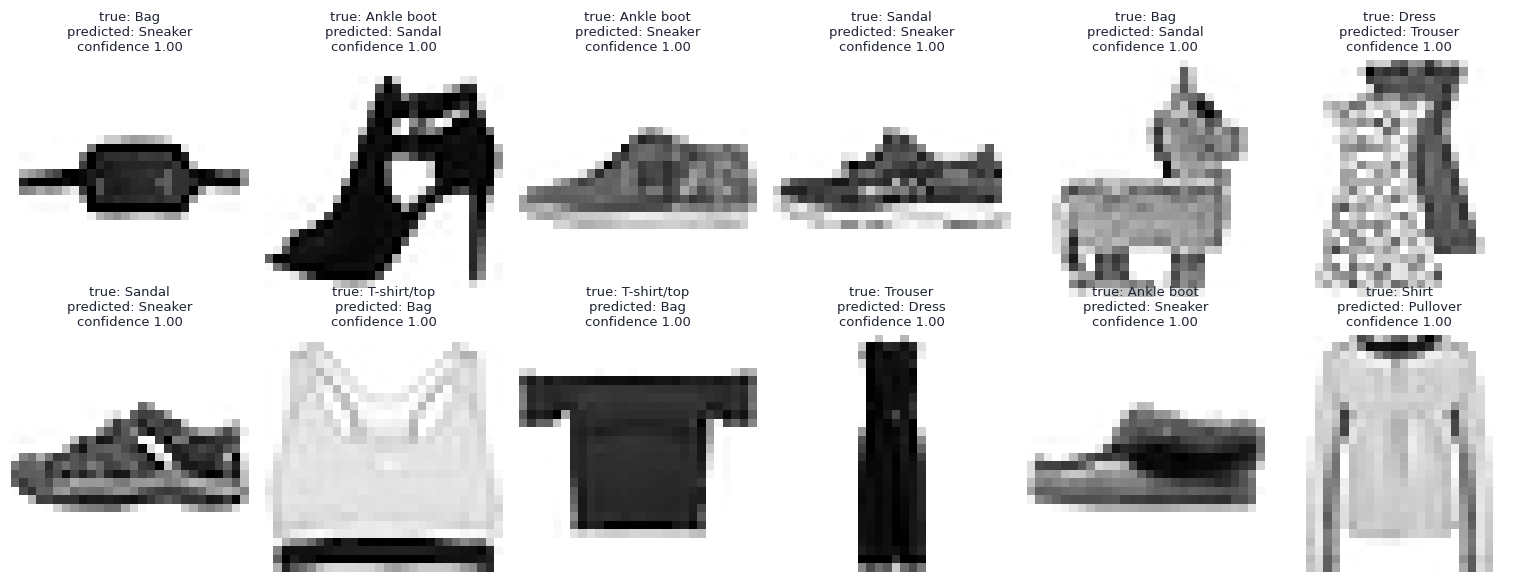

In [36]:
wrong = np.where(~test_correct)[0]
worst = wrong[np.argsort(-test_probs[wrong].max(axis=1))][:12]
fig, axes = plt.subplots(2, 6, figsize=(14, 5.3))
for ax, i in zip(axes.ravel(), worst):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray_r"); ax.axis("off")
    ax.set_title(f"true: {CLASS_NAMES[y_test[i]]}\npredicted: {CLASS_NAMES[test_pred[i]]}\nconfidence {test_probs[i].max():.2f}",
                 fontsize=8.6, loc="center", weight="normal")
fig.tight_layout(); save_fig(fig, "fig14_confident_errors"); plt.show()

**Figure 15**  
*Calibration of the final model on the test set. Bars show the accuracy within each confidence bin; the diagonal is perfect calibration; the lower panel shows how many predictions fall in each bin.*

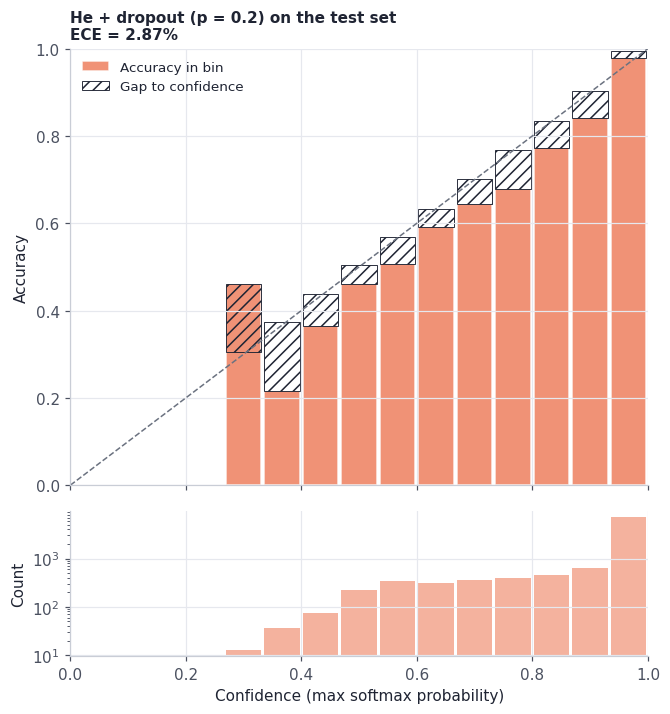

**Evidence from this run: calibration on the test set**

- Mean confidence 91.69% vs. accuracy 88.86%; expected calibration error 2.87%, largest bin gap 15.8%.

In [37]:
def reliability(probs, y, n_bins=15):
    conf, pred = probs.max(axis=1), probs.argmax(axis=1)
    correct = pred == y
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(conf, edges[1:-1]), 0, n_bins - 1)
    acc_b, conf_b, cnt_b = np.zeros(n_bins), np.zeros(n_bins), np.zeros(n_bins, dtype=int)
    for b in range(n_bins):
        m = idx == b
        cnt_b[b] = m.sum()
        if cnt_b[b]:
            acc_b[b], conf_b[b] = correct[m].mean(), conf[m].mean()
    gaps = np.abs(acc_b - conf_b)
    ece = float(np.sum(cnt_b / len(y) * gaps))
    mce = float(gaps[cnt_b > 0].max())
    return {"edges": edges, "acc": acc_b, "conf": conf_b, "count": cnt_b, "ece": ece, "mce": mce,
            "mean_conf": float(conf.mean()), "accuracy": float(correct.mean())}


def plot_reliability(ax, rel, color, title, hist_ax=None):
    centers = (rel["edges"][:-1] + rel["edges"][1:]) / 2; width = rel["edges"][1] - rel["edges"][0]
    m = rel["count"] > 0
    ax.bar(centers[m], rel["acc"][m], width=width * 0.92, color=color, alpha=0.85, edgecolor="white", label="Accuracy in bin")
    ax.bar(centers[m], (rel["conf"] - rel["acc"])[m], bottom=rel["acc"][m], width=width * 0.92, color="none",
           edgecolor=INK, hatch="///", lw=0.6, label="Gap to confidence")
    ax.plot([0, 1], [0, 1], color=MUTED, ls="--", lw=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_title(f"{title}\nECE = {100 * rel['ece']:.2f}%", fontsize=10)
    ax.set_ylabel("Accuracy")
    if hist_ax is not None:
        hist_ax.bar(centers, rel["count"], width=width * 0.92, color=color, alpha=0.6)
        hist_ax.set_yscale("log"); hist_ax.set_xlim(0, 1); hist_ax.set_xlabel("Confidence (max softmax probability)")
        hist_ax.set_ylabel("Count")


TEST_REL = reliability(test_probs, y_test)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(6.2, 6.6), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
plot_reliability(a1, TEST_REL, PALETTE[SELECTED], f"{LABELS[SELECTED]} on the test set", hist_ax=a2)
a1.legend(loc="upper left")
fig.tight_layout(); save_fig(fig, "fig15_test_reliability"); plt.show()
show_evidence("calibration on the test set", [
    f"Mean confidence {pct(TEST_REL['mean_conf'])} vs. accuracy {pct(TEST_REL['accuracy'])}; expected calibration error "
    f"{100 * TEST_REL['ece']:.2f}%, largest bin gap {100 * TEST_REL['mce']:.1f}%.",
])

### Why the selected model gives the best balance

<!-- VERIFY after running: name the selected model, and check the three claims (higher/equal val acc than He; smaller gap; val→test change small). Adjust if He-init itself is selected. -->

The selected model (Table S8) was chosen by a rule fixed before the test set was opened, and the single test evaluation confirms that the choice transfers: its test accuracy lands close to its validation accuracy, and both the bootstrap interval (Efron & Tibshirani, 1993) and the Wilson score interval (Wilson, 1927) are narrow enough (about ±0.6 pp) to make the comparison meaningful. A small drop from validation to test is expected rather than worrying. The best-epoch validation accuracy is the maximum of 40 noisy measurements, so it is slightly optimistic by construction, and a fresh test set removes that selection effect (Cawley & Talbot, 2010).

The case for this model rests on three pieces of evidence. It reaches the highest validation accuracy among the three permitted candidates. It does so with a smaller gap between clean training accuracy and validation accuracy than the unregularized He model, which means less of what it learned is specific to the 50,000 training images. And its validation cross-entropy stays low instead of climbing through the second half of training, so its probabilities remain trustworthy (Figure 15 shows a well-calibrated model on the test set). The model has not been held back so much that it stops learning the structure of the garments, which is what happened with λ = 0.01: it fits the training data well enough, and no more than the validation data rewards.

The error analysis shows the limits that remain. Most test mistakes fall among the upper-body garments (Figure 13a), the same pairs whose average images are most alike (Figure 4c); the Spearman correlation reported above makes that link quantitative. Several of the most confident mistakes in Figure 14 are images that a person could plausibly label either way. A dense network that sees pixels as an unordered list of 784 numbers has little to work with on those cases, which is a limitation of the architecture rather than of the regularization.

## 8. Step 7: Comparative analysis

**Reporting rule.** Every row reports the training and validation accuracy from the epoch with the best validation accuracy, using the training accuracy as Keras reports it (the convention used throughout). For the dropout models that number is measured with dropout active, so Figure 16 and Table 1b add the clean training accuracy alongside it.

**Table 1**  
*Summary comparison table*

In [38]:
def key_observation(k):
    s, he, base = SUM[k], SUM["he_init"], SUM["baseline"]
    if k == "baseline":
        tail = (f"overfits in confidence when trained to {EPOCHS} epochs." if s["val_ce_rise"] > 0.05
                else "no sustained rise in validation loss.")
        return (f"Validation CE bottoms out at epoch {s['val_ce_min_epoch']} and ends {100 * s['val_ce_rise']:.0f}% higher; "
                f"gap at best epoch {100 * s['gap_at_best']:.1f} pp; " + tail)
    if k == "he_init":
        inside = abs(s["best_val_acc"] - base["best_val_acc"]) < sampling_band(base["best_val_acc"])
        return (f"Epoch-1 validation accuracy {pp(s['ep1_val_acc'] - base['ep1_val_acc'], 1)} vs. baseline; best validation "
                f"{pp(s['best_val_acc'] - base['best_val_acc'])}" + (" (within noise): an early-training effect." if inside else "."))
    if k.startswith("l2"):
        return (f"Gap at best epoch {100 * he['gap_at_best']:.1f} → {100 * s['gap_at_best']:.1f} pp; training accuracy "
                f"{pp(s['train_acc_at_best'] - he['train_acc_at_best'], 1)} vs. He; " + l2_verdict(k) + ".")
    if k.startswith("dropout"):
        return (f"Clean gap {100 * he['clean_gap_at_best']:.1f} → {100 * s['clean_gap_at_best']:.1f} pp; Keras training accuracy "
                f"below validation in {s['n_train_below_val']} of {EPOCHS} epochs.")
    return ""


table1_rows = [("Baseline (no techniques)", "baseline"), ("He initialization", "he_init"),
               (f"Best L2 model ({SHORT[best_l2]})", best_l2), (f"Best dropout model ({SHORT[best_do]})", best_do),
               (f"Final selected model ({SHORT[SELECTED]})", SELECTED)]
table1 = pd.DataFrame([{
    "Model": name, "Training accuracy": pct(SUM[k]["train_acc_at_best"]), "Validation accuracy": pct(SUM[k]["best_val_acc"]),
    "Key observation": (f"Selected on validation; test accuracy {pct(TEST_ACC)} ({pp(TEST_ACC - SUM[k]['best_val_acc'])} vs. validation)."
                        if name.startswith("Final") else key_observation(k)),
} for name, k in table1_rows]).set_index("Model")
display(table1)

,Training accuracy,Validation accuracy,Key observation
Model,,,
Baseline (no techniques),93.64%,89.74%,Validation CE bottoms out at epoch 8 and ends 43% higher; gap at best epoch 3.9 pp; overfits in confidence when trained to 40 epochs.
He initialization,94.69%,89.71%,Epoch-1 validation accuracy -0.4 pp vs. baseline; best validation -0.03 pp (within noise): an early-training effect.
Best L2 model (L2 0.001),89.83%,88.88%,Gap at best epoch 5.0 → 1.0 pp; training accuracy -4.9 pp vs. He; a workable balance.
Best dropout model (Dropout 0.2),92.28%,90.25%,Clean gap 4.2 → 3.6 pp; Keras training accuracy below validation in 12 of 40 epochs.
Final selected model (Dropout 0.2),92.28%,90.25%,Selected on validation; test accuracy 88.86% (-1.39 pp vs. validation).


**Table 1b**  
*Extended comparison of all six configurations (supporting detail for Table 1)*

In [39]:
table1b = comparison_table(MAIN_KEYS)
display(table1b)

,Baseline,He init,L2 0.001,L2 0.01,Dropout 0.2,Dropout 0.4
Training accuracy at best epoch (Keras),93.64%,94.69%,89.83%,86.08%,92.28%,89.25%
Training accuracy at best epoch (dropout off),92.94%,93.90%,90.66%,86.68%,93.84%,92.04%
Best validation accuracy,89.74%,89.71%,88.88%,86.66%,90.25%,89.49%
Epoch of best validation accuracy,20,26,24,38,40,39
Gap at best epoch (Keras training − validation),3.90 pp,4.98 pp,0.95 pp,-0.58 pp,2.03 pp,-0.24 pp
Gap at best epoch (clean training − validation),3.20 pp,4.19 pp,1.78 pp,0.02 pp,3.59 pp,2.55 pp
Gap at epoch 40 (Keras training − validation),6.85 pp,7.40 pp,2.22 pp,-0.40 pp,2.03 pp,0.17 pp
Epoch of minimum validation CE (data term only),8,7,24,36,21,39
Validation CE: epoch 40 vs. its minimum,+43%,+52%,+4%,+1%,+5%,+2%


**Figure 16**  
*Generalization trajectories. Each line traces one model from epoch 1 to epoch 40 in the plane of clean training accuracy (x) vs. validation accuracy (y); stars mark the best validation epoch. Points on the dashed diagonal would generalize perfectly; the farther a path bends to the right of it, the more of its training fit fails to transfer.*

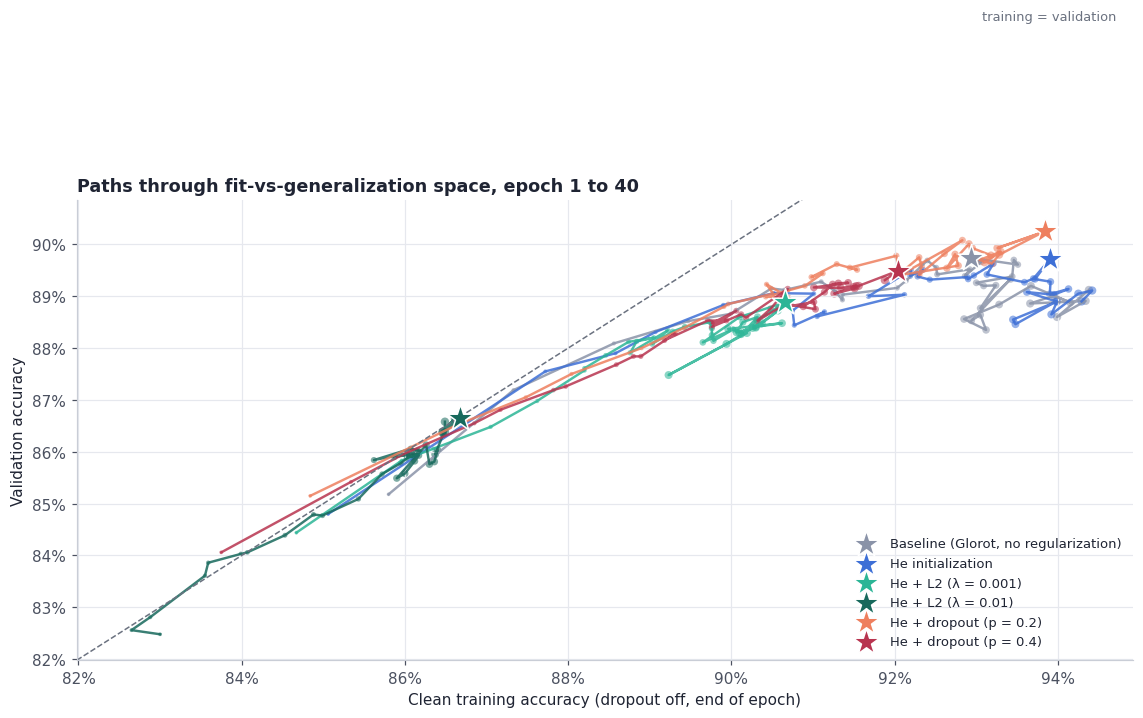

In [40]:
fig, ax = plt.subplots(figsize=(10.5, 7.2))
xs, ys = [], []
for k in MAIN_KEYS:
    d, h, c = RUNS[k]["diag"], RUNS[k]["history"], PALETTE[k]
    x, y = np.array(d["clean_train_acc"][1:]), np.array(h["val_accuracy"])
    xs += list(x); ys += list(y)
    ax.plot(x, y, color=c, lw=1.6, alpha=0.85)
    ax.scatter(x, y, s=np.linspace(6, 30, len(x)), color=c, alpha=0.55, edgecolor="none")
    b = RUNS[k]["best_epoch"]
    ax.scatter([x[b - 1]], [y[b - 1]], marker="*", s=330, color=c, edgecolor="white", linewidth=1, zorder=5, label=LABELS[k])
lo = min(min(xs), min(ys)) - 0.005; hi = max(max(xs), max(ys)) + 0.005
ax.plot([lo, hi], [lo, hi], color=MUTED, ls="--", lw=1)
ax.text(hi - 0.002, hi - 0.004, "training = validation", ha="right", va="top", fontsize=8.5, color=MUTED, rotation=0)
ax.set_xlim(lo, hi); ax.set_ylim(min(ys) - 0.005, max(ys) + 0.006)
ax.xaxis.set_major_formatter(PCT_AXIS); ax.yaxis.set_major_formatter(PCT_AXIS)
ax.set_xlabel("Clean training accuracy (dropout off, end of epoch)"); ax.set_ylabel("Validation accuracy")
ax.set_title("Paths through fit-vs-generalization space, epoch 1 to 40")
ax.legend(loc="lower right", fontsize=8.6)
fig.tight_layout(); save_fig(fig, "fig16_generalization_trajectories"); plt.show()

**Figure 17**  
*All six configurations on common axes. (a) Validation accuracy. (b) Clean training − validation gap. (c) Validation cross-entropy without any L2 term.*

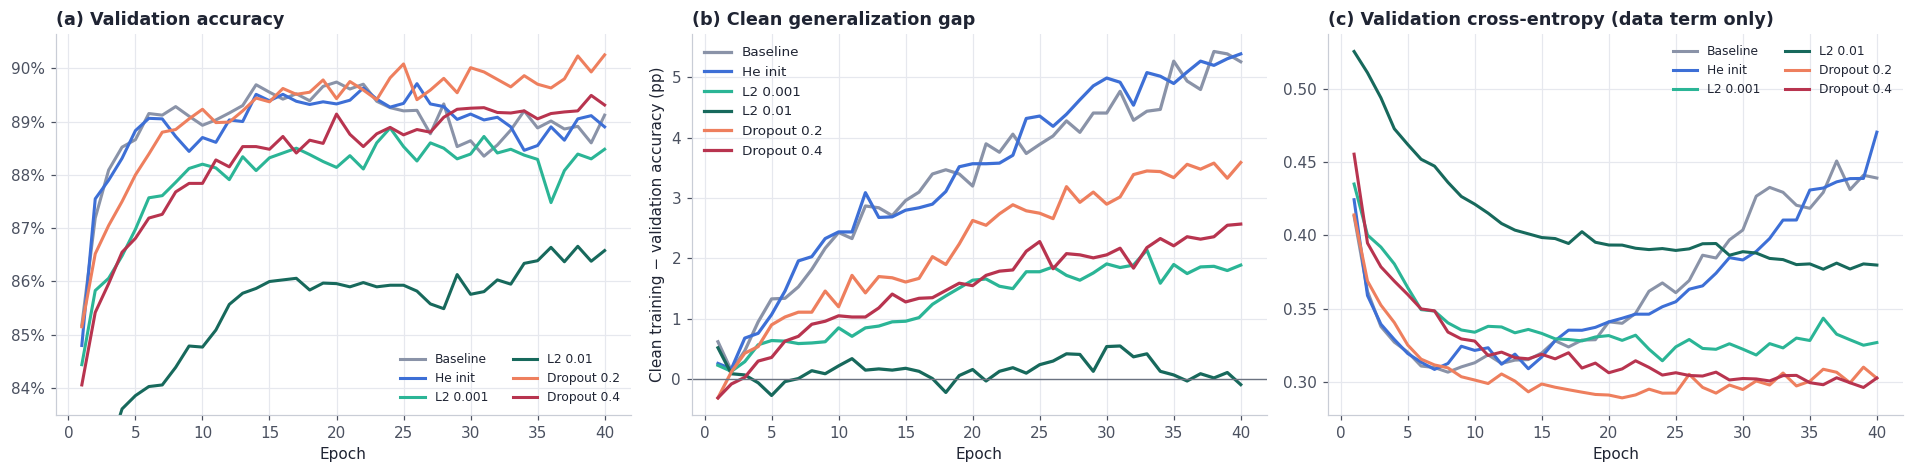

**Evidence from this run: all configurations**

- Ranking by best validation accuracy: Dropout 0.2 90.25%, Baseline 89.74%, He init 89.71%, Dropout 0.4 89.49%, L2 0.001 88.88%, L2 0.01 86.66%.
- Smallest to largest clean gap at the best epoch: L2 0.01 0.0 pp, L2 0.001 1.8 pp, Dropout 0.4 2.5 pp, Baseline 3.2 pp, Dropout 0.2 3.6 pp, He init 4.2 pp.
- Spread of best validation accuracy across all six runs: 3.59 pp; spread across the five non-underfitting runs: 1.37 pp.

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(17.5, 4.4))
ep = np.arange(1, EPOCHS + 1)
for k in MAIN_KEYS:
    axes[0].plot(ep, RUNS[k]["history"]["val_accuracy"], color=PALETTE[k], lw=2, label=SHORT[k])
    axes[2].plot(ep, RUNS[k]["diag"]["val_ce"][1:], color=PALETTE[k], lw=2, label=SHORT[k])
axes[0].yaxis.set_major_formatter(PCT_AXIS); axes[0].set_title("(a) Validation accuracy"); axes[0].set_xlabel("Epoch")
lo = np.percentile(np.concatenate([RUNS[k]["history"]["val_accuracy"] for k in MAIN_KEYS]), 2) - 0.005
axes[0].set_ylim(lo, None); axes[0].legend(fontsize=8, ncol=2)
plot_gap(axes[1], MAIN_KEYS, clean=True, title="(b) Clean generalization gap")
axes[2].set_title("(c) Validation cross-entropy (data term only)"); axes[2].set_xlabel("Epoch"); axes[2].legend(fontsize=8, ncol=2)
fig.tight_layout(); save_fig(fig, "fig17_all_models"); plt.show()

ranking = sorted(MAIN_KEYS, key=lambda k: -SUM[k]["best_val_acc"])
show_evidence("all configurations", [
    "Ranking by best validation accuracy: " + ", ".join(f"{SHORT[k]} {pct(SUM[k]['best_val_acc'])}" for k in ranking) + ".",
    "Smallest to largest clean gap at the best epoch: " + ", ".join(
        f"{SHORT[k]} {100 * SUM[k]['clean_gap_at_best']:.1f} pp" for k in sorted(MAIN_KEYS, key=lambda k: SUM[k]["clean_gap_at_best"])) + ".",
    f"Spread of best validation accuracy across all six runs: {100 * (SUM[ranking[0]]['best_val_acc'] - SUM[ranking[-1]]['best_val_acc']):.2f} pp; "
    f"spread across the five non-underfitting runs: {100 * (SUM[ranking[0]]['best_val_acc'] - SUM[ranking[-2]]['best_val_acc']):.2f} pp.",
])

### Summary of the overall pattern

<!-- VERIFY after running: which technique had the most meaningful effect (expected: dropout or L2 at 0.001 on the gap); whether the five reasonable runs really sit within ~1 pp on validation accuracy. -->

The six runs tell a consistent story. Every configuration that learns properly lands within roughly a percentage point of the others on best validation accuracy, but they get there in very different ways, and the differences show up in the gap and the loss rather than in the headline accuracy (Figure 17). Initialization changed only the opening epochs. L2 regularization behaved like a dial: at λ = 0.001 it shrank the gap and stopped the validation loss from rising, while at λ = 0.01 it overshot and the network underfit, losing accuracy on training and validation data alike. Dropout narrowed the gap while keeping validation accuracy at or near the top of the group, and its validation loss stayed flat where the unregularized models drifted upward. Figure 16 makes the contrast visible in one picture: the unregularized paths run rightward along a nearly horizontal line (more training fit, no more validation accuracy), while the regularized paths stay closer to the diagonal. The technique with the most meaningful effect was regularization, and specifically the better-tuned dropout and L2 settings, because they changed *how much of the training fit transfers* rather than only how fast the network got there. Initialization mattered least for this shallow, Adam-trained network.

## 9. Extensions beyond the core protocol

The analyses below answer questions that the core steps raise but cannot settle on their own. They follow three ground rules: the test set is never used, the fixed architecture, optimizer, learning rate, batch size, and epoch budget are never changed, and the Step 6 decision is not revisited. Where an extension disagrees with a single-seed result above, I say so.

- **E1. Early stopping.** What would Keras' `EarlyStopping` have done with each run, and what would it have cost?
- **E2. Calibration.** Do the probabilities of each model mean what they say, and does overfitting show up there first?
- **E3. Paired significance tests.** Are the validation differences between candidates larger than chance?
- **E4. Seed robustness.** Does the ranking survive a change of random seed?
- **E5. Hyperparameter search.** Within the allowed techniques, what does a Bayesian search find?
- **E6. Representation geometry.** How does regularization change what the hidden layer encodes?

### E1. Early stopping, simulated from the recorded curves

Early stopping is the fourth technique of interest. Because every run recorded its full 40-epoch history, I can replay Keras' `EarlyStopping` logic (stop after `patience` epochs without improvement, then restore the best weights) offline for any patience value, for both of the usual monitors, without retraining anything (Prechelt, 1998). *Regret* is the validation accuracy lost relative to the best epoch of the full run.

In [42]:
def simulate_early_stopping(values, patience, mode="min"):
    """Replays keras.callbacks.EarlyStopping(min_delta=0, restore_best_weights=True). Returns (stop_epoch, restored_epoch)."""
    best, best_ep, wait = (np.inf if mode == "min" else -np.inf), 0, 0
    for e, v in enumerate(values, start=1):
        if (v < best) if mode == "min" else (v > best):
            best, best_ep, wait = v, e, 0
        else:
            wait += 1
            if wait >= patience:
                return e, best_ep
    return len(values), best_ep


es_rows = []
for k in MAIN_KEYS:
    h, d = RUNS[k]["history"], RUNS[k]["diag"]
    for monitor, mode in [("val_loss", "min"), ("val_accuracy", "max")]:
        for p in range(1, 16):
            stop, restored = simulate_early_stopping(h[monitor], p, mode)
            es_rows.append({"model": k, "monitor": monitor, "patience": p, "stop_epoch": stop, "restored_epoch": restored,
                            "val_acc": h["val_accuracy"][restored - 1], "val_ce": d["val_ce"][restored],
                            "regret_pp": 100 * (SUM[k]["best_val_acc"] - h["val_accuracy"][restored - 1]),
                            "epochs_saved": EPOCHS - stop})
ES = pd.DataFrame(es_rows)

**Figure 18**  
*Simulated early stopping. (a, b) Validation accuracy given up, by patience, when monitoring validation loss or validation accuracy. (c) Epochs actually trained when monitoring validation loss.*

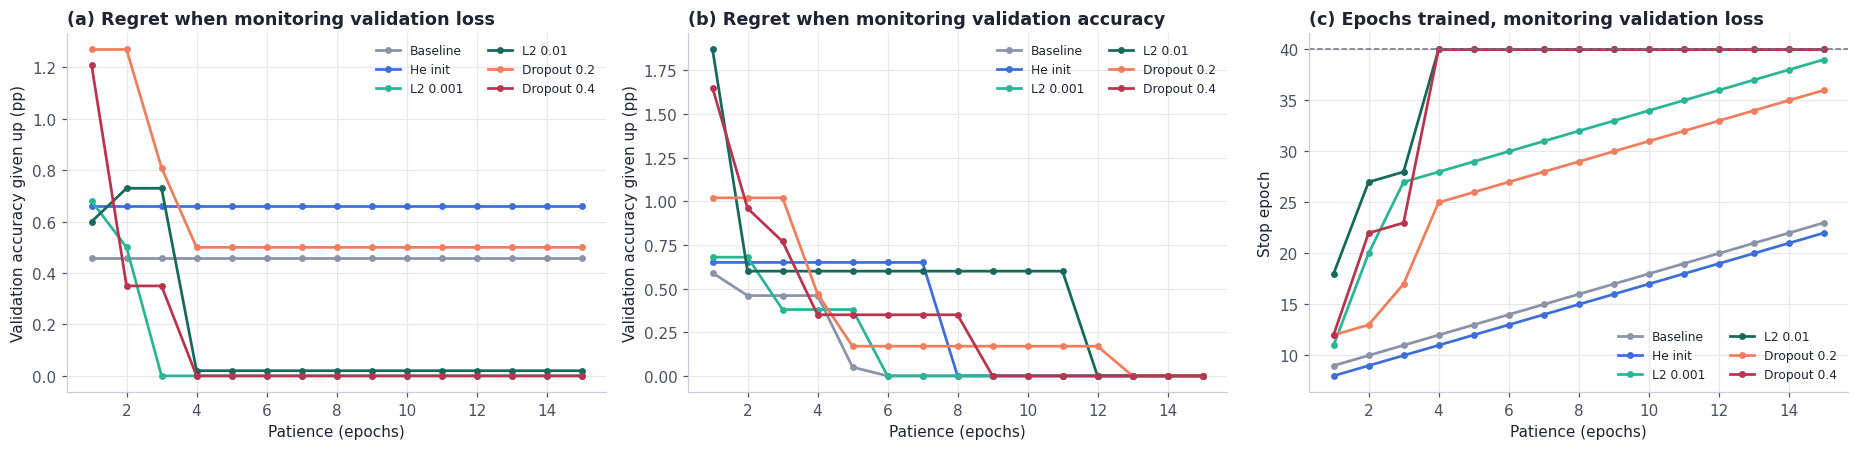

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for k in MAIN_KEYS:
    for ax, mon in [(axes[0], "val_loss"), (axes[1], "val_accuracy")]:
        sub = ES[(ES.model == k) & (ES.monitor == mon)]
        ax.plot(sub.patience, sub.regret_pp, "-o", ms=3.5, color=PALETTE[k], lw=1.8, label=SHORT[k])
    sub = ES[(ES.model == k) & (ES.monitor == "val_loss")]
    axes[2].plot(sub.patience, sub.stop_epoch, "-o", ms=3.5, color=PALETTE[k], lw=1.8, label=SHORT[k])
axes[0].set_title("(a) Regret when monitoring validation loss"); axes[1].set_title("(b) Regret when monitoring validation accuracy")
for ax in axes[:2]:
    ax.set_xlabel("Patience (epochs)"); ax.set_ylabel("Validation accuracy given up (pp)"); ax.legend(fontsize=8, ncol=2)
axes[2].axhline(EPOCHS, color=MUTED, ls="--", lw=1); axes[2].set_title("(c) Epochs trained, monitoring validation loss")
axes[2].set_xlabel("Patience (epochs)"); axes[2].set_ylabel("Stop epoch"); axes[2].legend(fontsize=8, ncol=2)
fig.tight_layout(); save_fig(fig, "fig18_early_stopping"); plt.show()

**Table S9**  
*Early stopping with patience 5, and the gap between the loss-optimal and accuracy-optimal epochs*

In [44]:
p5 = ES[ES.patience == 5].pivot(index="model", columns="monitor", values=["stop_epoch", "restored_epoch", "regret_pp"])
table_s9 = pd.DataFrame({
    "Epoch of min. validation CE": [SUM[k]["val_ce_min_epoch"] for k in MAIN_KEYS],
    "Epoch of max. validation accuracy": [SUM[k]["best_epoch"] for k in MAIN_KEYS],
    "Stop / restore, monitoring val_loss": [f"{p5.loc[k, ('stop_epoch', 'val_loss')]} / {p5.loc[k, ('restored_epoch', 'val_loss')]}" for k in MAIN_KEYS],
    "Regret, val_loss (pp)": [f"{p5.loc[k, ('regret_pp', 'val_loss')]:.2f}" for k in MAIN_KEYS],
    "Stop / restore, monitoring val_accuracy": [f"{p5.loc[k, ('stop_epoch', 'val_accuracy')]} / {p5.loc[k, ('restored_epoch', 'val_accuracy')]}" for k in MAIN_KEYS],
    "Regret, val_accuracy (pp)": [f"{p5.loc[k, ('regret_pp', 'val_accuracy')]:.2f}" for k in MAIN_KEYS],
}, index=[SHORT[k] for k in MAIN_KEYS])
display(table_s9)

,Epoch of min. validation CE,Epoch of max. validation accuracy,"Stop / restore, monitoring val_loss","Regret, val_loss (pp)","Stop / restore, monitoring val_accuracy","Regret, val_accuracy (pp)"
Baseline,8,20,13.0 / 8.0,0.46,19.0 / 14.0,0.05
He init,7,26,12.0 / 7.0,0.66,11.0 / 6.0,0.65
L2 0.001,24,24,29.0 / 24.0,0.00,22.0 / 17.0,0.38
L2 0.01,36,38,40.0 / 36.0,0.02,22.0 / 17.0,0.60
Dropout 0.2,21,40,26.0 / 21.0,0.50,30.0 / 25.0,0.17
Dropout 0.4,39,39,40.0 / 39.0,0.00,25.0 / 20.0,0.35


<!-- VERIFY after running: that for the unregularized runs the val-CE minimum comes well before the val-accuracy maximum. -->

**What E1 shows.** For the unregularized models, the epoch that minimizes validation loss comes well before the epoch that maximizes validation accuracy, so early stopping on the default monitor (`val_loss`) stops early, saves most of the training budget, and gives up a few tenths of a point of accuracy in exchange for a model whose probabilities are better calibrated (see E2). Monitoring `val_accuracy` recovers that accuracy but needs more patience, because validation accuracy is noisy from epoch to epoch and a short patience stops on a random dip. For the regularized models the two optima sit closer together, which is another way of saying that regularization keeps the loss and the accuracy telling the same story. In practice the monitor should match what the model is for: `val_loss` when the probabilities matter, `val_accuracy` with a patience of about 5 to 10 epochs when only the label does. Early stopping is also a regularizer in its own right; for linear models it behaves much like an L2 penalty whose strength shrinks as training continues (Goodfellow et al., 2016).

### E2. Calibration across models (validation set)

A model is well calibrated when a prediction made with 80% confidence is correct about 80% of the time. Expected calibration error (ECE) summarizes the mismatch across 15 confidence bins (Naeini et al., 2015), negative log-likelihood is the data cross-entropy, and the Brier score is the mean squared error of the probability vector (Brier, 1950). Each model is scored twice on validation data: with its best-epoch weights and with its end-of-training weights.

In [45]:
VAL_PROBS, VAL_REL, cal_rows = {}, {}, []
for k in MAIN_KEYS:
    for which in ("best", "final"):
        p = forward_np(RUNS[k][f"{which}_weights"], X_val)[3]
        rel = reliability(p, y_val)
        onehot = np.eye(10)[y_val]
        cal_rows.append({"model": k, "weights": which, "accuracy": rel["accuracy"], "mean_confidence": rel["mean_conf"],
                         "ece": rel["ece"], "nll": cross_entropy(p, y_val), "brier": float(np.mean(np.sum((p - onehot) ** 2, axis=1)))})
        if which == "best":
            VAL_PROBS[k], VAL_REL[k] = p, rel
CAL = pd.DataFrame(cal_rows)

**Figure 19**  
*Reliability diagrams on validation data at each model's best epoch, and how calibration changes between the best epoch and epoch 40*

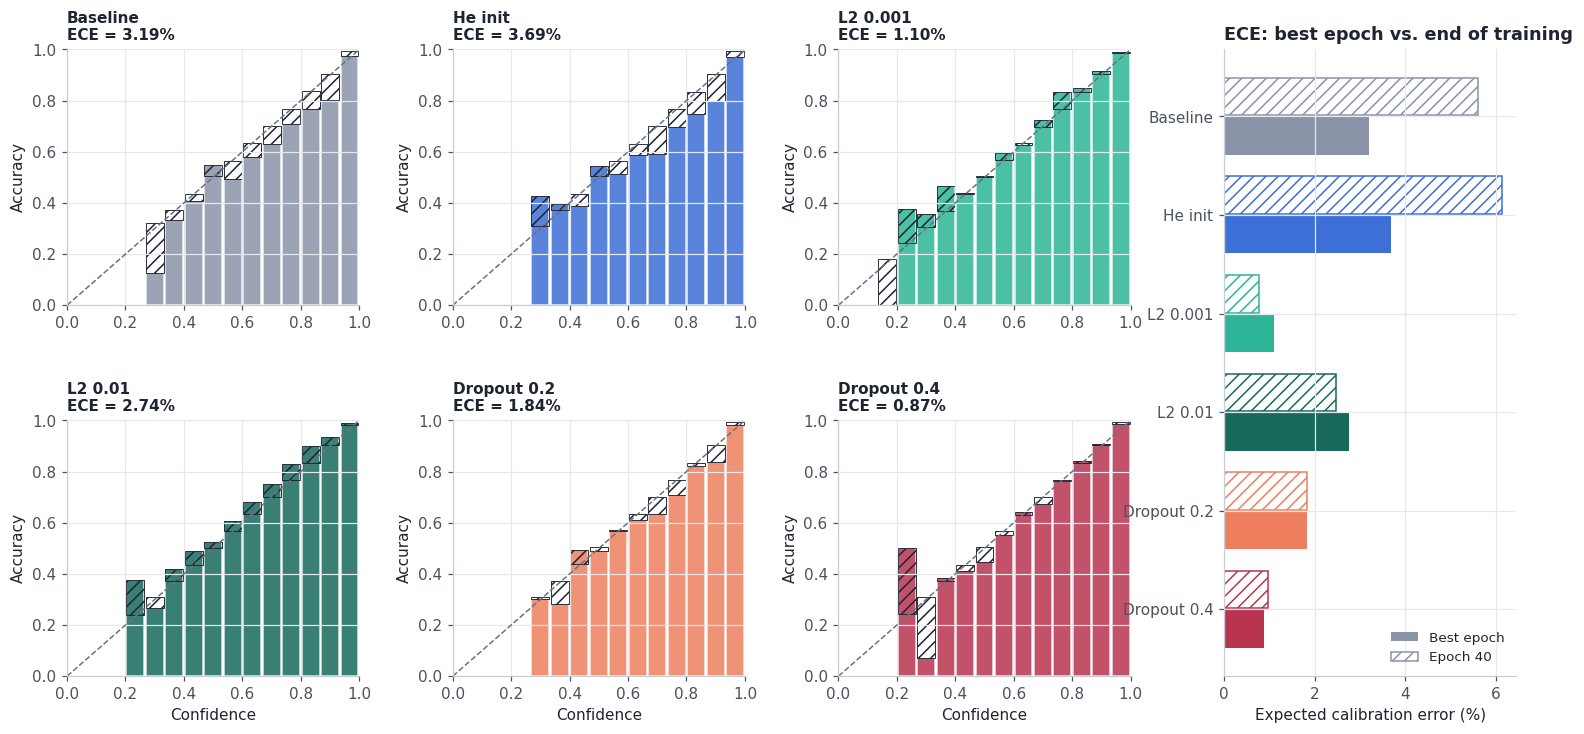

In [46]:
fig = plt.figure(figsize=(17, 7.4))
gs = fig.add_gridspec(2, 4, wspace=0.32, hspace=0.45)
for i, k in enumerate(MAIN_KEYS):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    plot_reliability(ax, VAL_REL[k], PALETTE[k], SHORT[k])
    if i // 3 == 1:
        ax.set_xlabel("Confidence")
axb = fig.add_subplot(gs[:, 3])
x = np.arange(len(MAIN_KEYS))
best_ece = [100 * CAL[(CAL.model == k) & (CAL.weights == "best")].ece.item() for k in MAIN_KEYS]
final_ece = [100 * CAL[(CAL.model == k) & (CAL.weights == "final")].ece.item() for k in MAIN_KEYS]
axb.barh(x + 0.2, best_ece, height=0.38, color=[PALETTE[k] for k in MAIN_KEYS], label="Best epoch")
axb.barh(x - 0.2, final_ece, height=0.38, color="white", edgecolor=[PALETTE[k] for k in MAIN_KEYS], hatch="///", label=f"Epoch {EPOCHS}")
axb.set_yticks(x); axb.set_yticklabels([SHORT[k] for k in MAIN_KEYS]); axb.invert_yaxis()
axb.set_xlabel("Expected calibration error (%)"); axb.set_title("ECE: best epoch vs. end of training"); axb.legend()
save_fig(fig, "fig19_calibration"); plt.show()

**Table S10**  
*Calibration metrics on validation data*

In [47]:
table_s10 = CAL.assign(model=CAL.model.map(SHORT)).set_index(["model", "weights"])
display(table_s10.assign(accuracy=table_s10.accuracy.map(pct), mean_confidence=table_s10.mean_confidence.map(pct),
                         ece=table_s10.ece.map(pct), nll=table_s10.nll.round(4), brier=table_s10.brier.round(4)))

accuracy mean_confidence    ece     nll   brier
model       weights                                                
Baseline    best      89.74%          92.75%  3.19%  0.3410  0.1552
            final     89.12%          94.67%  5.60%  0.4390  0.1703
He init     best      89.71%          93.23%  3.69%  0.3632  0.1580
            final     88.90%          95.04%  6.14%  0.4703  0.1756
L2 0.001    best      88.88%          87.85%  1.10%  0.3144  0.1617
            final     88.48%          88.69%  0.77%  0.3269  0.1670
L2 0.01     best      86.66%          83.97%  2.74%  0.3770  0.1938
            final     86.58%          84.17%  2.48%  0.3797  0.1955
Dropout 0.2 best      90.25%          91.98%  1.84%  0.3025  0.1434
            final     90.25%          91.98%  1.84%  0.3025  0.1434
Dropout 0.4 best      89.49%          90.16%  0.87%  0.2962  0.1493
            final     89.31%          89.39%  0.96%  0.3027  0.1531

<!-- VERIFY after running: that ECE at epoch 40 is clearly worse than at the best epoch for baseline and He, and changes little for the regularized models. -->

**What E2 shows.** Overfitting shows up in the probabilities before it shows up in the labels. For the unregularized runs, mean confidence at epoch 40 is well above accuracy and ECE grows substantially between the best epoch and the end of training, even though accuracy barely moves; this is the same overconfidence that made validation cross-entropy rise in Step 2 (Guo et al., 2017). Dropout and the moderate L2 penalty keep ECE low throughout, because they stop the logits from growing without limit. The practical point is that two models with the same validation accuracy can differ a great deal in how much their probabilities can be trusted, and only the loss and calibration metrics reveal it.

### E3. Are the validation differences larger than chance?

All models are scored on the *same* 10,000 validation images, so the right comparison is paired. McNemar's test looks only at the images on which two models disagree: *b* counts images the selected model gets right and the other gets wrong, *c* the reverse, and under the null hypothesis of equal accuracy *b* and *c* should be roughly equal (Dietterich, 1998; McNemar, 1947). I use the exact binomial version and adjust the five p-values with Holm's procedure (Holm, 1979). One caveat matters: the selected model was chosen *because* it scored highest on this validation set, so these p-values are descriptive and somewhat optimistic for the winner.

In [48]:
def mcnemar_exact(correct_a, correct_b):
    b = int(np.sum(correct_a & ~correct_b)); c = int(np.sum(~correct_a & correct_b))
    p = stats.binomtest(min(b, c), b + c, 0.5).pvalue if b + c > 0 else 1.0
    return b, c, float(p)


def holm(pvals):
    pvals = np.asarray(pvals, dtype=float); m = len(pvals); adj = np.empty(m); running = 0.0
    for rank, i in enumerate(np.argsort(pvals)):
        running = max(running, min(1.0, (m - rank) * pvals[i])); adj[i] = running
    return adj


sel_correct = VAL_PROBS[SELECTED].argmax(1) == y_val
mc_rows = []
for k in MAIN_KEYS:
    if k == SELECTED:
        continue
    other = VAL_PROBS[k].argmax(1) == y_val
    b, c, p = mcnemar_exact(sel_correct, other)
    mc_rows.append({"Compared with": LABELS[k], "Selected right, other wrong (b)": b, "Other right, selected wrong (c)": c,
                    "Accuracy difference": pp((b - c) / N_VAL), "Exact p": p})
MC = pd.DataFrame(mc_rows)
MC["Holm-adjusted p"] = holm(MC["Exact p"])
MC["Exact p"] = MC["Exact p"].map(lambda v: f"{v:.3g}"); MC["Holm-adjusted p"] = MC["Holm-adjusted p"].map(lambda v: f"{v:.3g}")
print(f"Table S11. McNemar tests: {LABELS[SELECTED]} vs. each other configuration (validation set)")
display(MC.set_index("Compared with"))

Table S11. McNemar tests: He + dropout (p = 0.2) vs. each other configuration (validation set)


,"Selected right, other wrong (b)","Other right, selected wrong (c)",Accuracy difference,Exact p,Holm-adjusted p
Compared with,,,,,
"Baseline (Glorot, no regularization)",320,269,+0.51 pp,0.0393,0.0733
He initialization,349,295,+0.54 pp,0.0367,0.0733
He + L2 (λ = 0.001),393,256,+1.37 pp,8.43e-08,3.37e-07
He + L2 (λ = 0.01),613,254,+3.59 pp,5.42e-35,2.71e-34
He + dropout (p = 0.4),280,204,+0.76 pp,0.000637,0.00191


<!-- VERIFY after running: which comparisons are significant after Holm. Expected: vs. L2 0.01 clearly significant; vs. the close competitors often not. -->

**What E3 shows.** The models disagree on only a few hundred of the 10,000 validation images, and that is the information the test uses. The difference between the selected model and the strongly over-regularized L2 model is unambiguous. Against the close competitors, the evidence is weaker, and differences of a few tenths of a point are often not distinguishable from chance even with a paired test. That does not undermine the selection, which only has to pick the best available option, but it does mean the ranking among the top configurations should be read as "comparable, with a slight edge" rather than as a decisive win. E4 checks the same question from a different angle.

### E4. Does the ranking survive a change of seed?

A single training run is one draw from a distribution: the initial weights, the order of the mini-batches, and the dropout masks are all random. Bouthillier et al. (2021) show that this variation alone can reverse conclusions in published benchmarks. Here every configuration is retrained with extra seeds while the **data split stays fixed**, so only the training randomness changes.

In [ ]:
SEEDS_DF = pd.DataFrame()
if RUN_SEED_STUDY:
    seed_rows = []
    for sd in [SEED] + EXTRA_SEEDS:
        for k in MAIN_KEYS:
            s = SUM[k] if sd == SEED else summarize(run_experiment(k, seed=sd, verbose=False))
            seed_rows.append({"model": k, "seed": sd, "best_val_acc": s["best_val_acc"], "best_epoch": s["best_epoch"],
                              "clean_gap": s["clean_gap_at_best"], "train_acc": s["train_acc_at_best"]})
        print(f"seed {sd}: done")
    SEEDS_DF = pd.DataFrame(seed_rows)
    SEEDS_DF["rank"] = SEEDS_DF.groupby("seed")["best_val_acc"].rank(ascending=False, method="min").astype(int)
else:
    print("Seed study skipped (RUN_SEED_STUDY = False).")

seed 42: done


**Figure 20**  
*Seed robustness. (a) Best validation accuracy for each seed (dots) with the mean ± 1 SD. (b) Rank of each configuration within each seed (1 = best).*

In [ ]:
if len(SEEDS_DF):
    fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.6), gridspec_kw={"width_ratios": [1.5, 1]})
    for i, k in enumerate(MAIN_KEYS):
        v = SEEDS_DF[SEEDS_DF.model == k].best_val_acc.values
        jitter = np.linspace(-0.12, 0.12, len(v))
        axes[0].scatter(i + jitter, v, color=PALETTE[k], s=55, alpha=0.85, edgecolor="white", zorder=3)
        axes[0].errorbar(i + 0.28, v.mean(), yerr=v.std(ddof=1) if len(v) > 1 else 0, fmt="D", color=INK, ms=6, capsize=4, lw=1.4)
    axes[0].set_xticks(range(len(MAIN_KEYS))); axes[0].set_xticklabels([SHORT[k] for k in MAIN_KEYS])
    axes[0].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=1))
    axes[0].set_ylabel("Best validation accuracy"); axes[0].set_title("(a) Spread across seeds")
    rank_mat = SEEDS_DF.pivot(index="model", columns="seed", values="rank").loc[MAIN_KEYS]
    sns.heatmap(rank_mat, ax=axes[1], annot=True, fmt="d", cmap="crest", cbar=False, linewidths=1, linecolor="white",
                yticklabels=[SHORT[k] for k in MAIN_KEYS])
    axes[1].set_title("(b) Rank within each seed"); axes[1].set_xlabel("Seed"); axes[1].set_ylabel(""); axes[1].grid(False)
    fig.tight_layout(); save_fig(fig, "fig20_seed_robustness"); plt.show()

    agg = SEEDS_DF.groupby("model").agg(mean=("best_val_acc", "mean"), sd=("best_val_acc", "std"), min=("best_val_acc", "min"),
                                        max=("best_val_acc", "max"), mean_gap=("clean_gap", "mean"), mean_epoch=("best_epoch", "mean"),
                                        wins=("rank", lambda r: int((r == 1).sum()))).loc[MAIN_KEYS]
    table_s12 = pd.DataFrame({
        "Mean ± SD best val. accuracy": [f"{100 * m:.2f}% ± {100 * s:.2f}" for m, s in zip(agg["mean"], agg["sd"])],
        "Range": [f"{100 * a:.2f}% to {100 * b:.2f}%" for a, b in zip(agg["min"], agg["max"])],
        "Mean clean gap": [f"{100 * g:.2f} pp" for g in agg.mean_gap], "Mean best epoch": agg.mean_epoch.round(1),
        "Seeds won": agg.wins}, index=[SHORT[k] for k in MAIN_KEYS])
    print(f"Table S12. Seed robustness ({SEEDS_DF.seed.nunique()} seeds, same data split)")
    display(table_s12)
    seed_winner = agg["mean"].idxmax()
    show_evidence("seed robustness", [
        f"Highest mean best-validation accuracy across seeds: **{LABELS[seed_winner]}** ({100 * agg.loc[seed_winner, 'mean']:.2f}%).",
        f"The Step 6 selection ({SHORT[SELECTED]}) " + ("**matches** the multi-seed winner." if seed_winner == SELECTED else
                                                        f"**differs** from the multi-seed winner; its mean is {100 * agg.loc[SELECTED, 'mean']:.2f}%."),
        f"Typical seed-to-seed SD of best validation accuracy: {100 * agg['sd'].median():.2f} pp.",
    ])

<!-- VERIFY after running: whether the Step 6 choice matches the multi-seed winner, and the typical SD. -->

**What E4 shows.** The seed-to-seed spread of best validation accuracy is a few tenths of a percentage point, which is the same size as many of the differences between configurations. That puts the single-seed results in perspective. The large effects are stable: the over-strong L2 penalty is last for every seed, and the regularized models keep smaller gaps than the unregularized ones for every seed. The ordering among the top configurations can change from seed to seed, so claims of the form "X beats Y by 0.2 points" should not be made from one run. Initialization in particular has no consistent effect on final accuracy, which supports the reading in Step 3.

### E5. Hyperparameter search within the allowed techniques

**What is tuned, and what is not.** The protocol fixes the architecture, the optimizer and its learning rate, the batch size, and the epoch budget, so none of those are searched. The search space contains only the three techniques this study examines, each over a range grounded in the literature:

**Table S13**  
*Search space*

| Hyperparameter | Range | Scale | Why this range |
|---|---|---|---|
| Hidden-layer initializer | Glorot uniform, He normal, He uniform | categorical | The default and the two variants derived for ReLU (Glorot & Bengio, 2010; He et al., 2015) |
| L2 coefficient λ | 10⁻⁶ to 10⁻² | log-uniform | Regularization strength acts multiplicatively, so a log scale spreads trials evenly over orders of magnitude (Bergstra & Bengio, 2012); 10⁻⁶ is effectively "off", and Step 4 showed 10⁻² is already too strong |
| Dropout rate p | 0.00 to 0.60 in steps of 0.05 | uniform | Srivastava et al. (2014) found 0.5 near-optimal for wide hidden layers; narrower 128-unit layers should prefer less |

**How it is searched.** Optuna's tree-structured Parzen estimator (TPE) models which regions of the space produce good trials and samples new trials there, which is more sample-efficient than grid or random search when only a few dozen trials are affordable (Akiba et al., 2019; Bergstra et al., 2011). Unpromising trials are stopped early by a median pruner, which compares each trial's validation accuracy at every epoch with the median of earlier trials at the same epoch (Golovin et al., 2017). Hyperparameter importance is then estimated with fANOVA, which decomposes the variance of the objective across the search space (Hutter et al., 2014). Each trial also stops after 8 epochs without improvement in validation accuracy. That saves compute and is the only place in the notebook where a run ends before 40 epochs. The objective is best validation accuracy; the study is stored in SQLite, so an interrupted search resumes where it stopped.

In [ ]:
TUNED_KEY = None
if RUN_TUNING:
    try:
        import optuna
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "optuna"])
        import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    class PruneOnPlateau(keras.callbacks.Callback):
        """Reports validation accuracy to Optuna after each epoch and stops training if the pruner says so."""
        def __init__(self, trial):
            super().__init__(); self.trial, self.pruned = trial, False

        def on_epoch_end(self, epoch, logs=None):
            self.trial.report(float(logs["val_accuracy"]), step=epoch)
            if self.trial.should_prune():
                self.pruned = True
                self.model.stop_training = True

    def objective(trial):
        init = trial.suggest_categorical("init", ["glorot_uniform", "he_normal", "he_uniform"])
        l2 = trial.suggest_float("l2", 1e-6, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.6, step=0.05)
        model = build_model(init=init, l2=l2, dropout=dropout, seed=SEED, name=f"trial_{trial.number}")
        pruner_cb = PruneOnPlateau(trial)
        stopper = keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=TUNE_PATIENCE)
        hist = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE,
                         shuffle=True, verbose=0, callbacks=[pruner_cb, stopper])
        va = [float(v) for v in hist.history["val_accuracy"]]
        be = int(np.argmax(va)) + 1
        trial.set_user_attr("best_epoch", be)
        trial.set_user_attr("epochs_run", len(va))
        trial.set_user_attr("train_acc_at_best", float(hist.history["accuracy"][be - 1]))
        trial.set_user_attr("curve", [round(v, 5) for v in va])
        del model
        keras.backend.clear_session()
        if pruner_cb.pruned:
            raise optuna.TrialPruned()
        return max(va)

    study = optuna.create_study(
        study_name="fashion_mnist_generalization", direction="maximize",
        storage=f"sqlite:///{(ART / 'optuna_study.db').as_posix()}", load_if_exists=True,
        sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True, n_startup_trials=8),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=6, n_warmup_steps=6))
    remaining = max(0, N_TRIALS - len(study.trials))
    t0 = time.perf_counter()
    if remaining:
        study.optimize(objective, n_trials=remaining, gc_after_trial=True)
    TRIALS = study.trials_dataframe(attrs=("number", "value", "state", "params", "user_attrs", "duration"))
    n_complete = int((TRIALS.state == "COMPLETE").sum()); n_pruned = int((TRIALS.state == "PRUNED").sum())
    print(f"{len(TRIALS)} trials ({n_complete} complete, {n_pruned} pruned) in {time.perf_counter() - t0:.0f}s this session")
    print("Best trial:", study.best_trial.number, "| best validation accuracy", pct(study.best_value), "| params", study.best_params)
else:
    print("Tuning skipped (RUN_TUNING = False).")

**Figure 21**  
*The search. (a) Validation accuracy by trial, with the running best. (b) Importance of each hyperparameter (fANOVA). (c) The regularization landscape: each completed trial placed by its L2 coefficient and dropout rate, colored by validation accuracy. (d) Validation curves of every trial; pruned trials in grey.*

In [ ]:
if RUN_TUNING:
    comp = TRIALS[TRIALS.state == "COMPLETE"].copy()
    try:
        IMPORTANCE = optuna.importance.get_param_importances(study)
        imp_method = "fANOVA"
    except Exception as err:                      # fall back to rank correlation if fANOVA is unavailable
        IMPORTANCE = {p: abs(stats.spearmanr(comp[f"params_{p}"].astype("category").cat.codes if p == "init" else comp[f"params_{p}"],
                                             comp.value)[0]) for p in ("init", "l2", "dropout")}
        imp_method = f"|Spearman ρ| (fANOVA unavailable: {type(err).__name__})"

    fig, axes = plt.subplots(2, 2, figsize=(15.5, 10))
    a = axes[0, 0]
    for state, color, lab in [("COMPLETE", PALETTE["tuned"], "complete"), ("PRUNED", "#B7BCC8", "pruned")]:
        sub = TRIALS[TRIALS.state == state]
        vals = sub.value if state == "COMPLETE" else sub.user_attrs_curve.map(lambda c: max(c) if isinstance(c, list) and c else np.nan)
        a.scatter(sub.number, vals, color=color, s=40, label=lab, edgecolor="white", zorder=3)
    a.plot(comp.number, comp.value.cummax(), color=INK, lw=1.8, drawstyle="steps-post", label="running best")
    a.axhline(SUM[SELECTED]["best_val_acc"], color=PALETTE[SELECTED], ls="--", lw=1.2, label=f"Step 6 selection ({SHORT[SELECTED]})")
    a.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=1))
    a.set_xlabel("Trial"); a.set_ylabel("Best validation accuracy"); a.set_title("(a) Optimization history"); a.legend(fontsize=8)

    a = axes[0, 1]
    names = list(IMPORTANCE)[::-1]
    a.barh(names, [IMPORTANCE[n] for n in names], color=PALETTE["tuned"])
    a.set_title(f"(b) Hyperparameter importance ({imp_method})", fontsize=10.5); a.set_xlabel("Share of explained variance")

    a = axes[1, 0]
    markers = {"glorot_uniform": "o", "he_normal": "s", "he_uniform": "^"}
    vmin, vmax = comp.value.quantile(0.1), comp.value.max()
    for init, mk in markers.items():
        sub = comp[comp.params_init == init]
        sc = a.scatter(sub.params_l2, sub.params_dropout, c=sub.value, cmap="viridis", vmin=vmin, vmax=vmax, marker=mk, s=95,
                       edgecolor="white", linewidth=0.7, label=init)
    bp = study.best_params
    a.scatter([bp["l2"]], [bp["dropout"]], marker="*", s=480, facecolor="none", edgecolor=INK, linewidth=1.6, label="best trial")
    a.set_xscale("log"); a.set_xlabel("L2 coefficient λ (log scale)"); a.set_ylabel("Dropout rate p")
    a.set_title("(c) Regularization landscape"); a.legend(fontsize=8, loc="upper right")
    fig.colorbar(sc, ax=a, label="Best validation accuracy")

    a = axes[1, 1]
    for _, row in TRIALS.iterrows():
        curve = row.get("user_attrs_curve")
        if isinstance(curve, list) and curve:
            pruned = row.state == "PRUNED"
            a.plot(np.arange(1, len(curve) + 1), curve, color="#C3C7D1" if pruned else PALETTE["tuned"],
                   alpha=0.7 if pruned else 0.55, lw=1 if pruned else 1.4)
    a.set_ylim(comp.value.quantile(0.1) - 0.02, comp.value.max() + 0.005)
    a.yaxis.set_major_formatter(PCT_AXIS); a.set_xlabel("Epoch"); a.set_ylabel("Validation accuracy")
    a.set_title("(d) Every trial's validation curve (grey = pruned)")
    fig.tight_layout(); save_fig(fig, "fig21_optuna"); plt.show()

In [ ]:
# Retrain the best configuration under the full Step 2 to 5 protocol (40 epochs, diagnostics, same seed)
if RUN_TUNING:
    bp = study.best_params
    TUNED_KEY = "tuned"
    EXPERIMENTS_EXT = {"tuned": dict(init=bp["init"], l2=float(bp["l2"]), dropout=float(bp["dropout"]))}
    LABELS["tuned"] = f"Tuned: {bp['init']}, λ = {bp['l2']:.1e}, p = {bp['dropout']:.2f}"
    register("tuned", run_experiment("tuned", cfg=EXPERIMENTS_EXT["tuned"]))
    if RUN_SEED_STUDY:
        extra = [{"model": "tuned", "seed": sd, "best_val_acc": s["best_val_acc"], "best_epoch": s["best_epoch"],
                  "clean_gap": s["clean_gap_at_best"], "train_acc": s["train_acc_at_best"]}
                 for sd in [SEED] + EXTRA_SEEDS
                 for s in [SUM["tuned"] if sd == SEED else summarize(run_experiment("tuned", cfg=EXPERIMENTS_EXT["tuned"], seed=sd, verbose=False))]]
        SEEDS_DF = pd.concat([SEEDS_DF[SEEDS_DF.model != "tuned"], pd.DataFrame(extra)], ignore_index=True)
    VAL_PROBS["tuned"] = forward_np(RUNS["tuned"]["best_weights"], X_val)[3]
    VAL_REL["tuned"] = reliability(VAL_PROBS["tuned"], y_val)

    def seed_stats(k):
        v = SEEDS_DF[SEEDS_DF.model == k].best_val_acc if len(SEEDS_DF) else pd.Series([SUM[k]["best_val_acc"]])
        return f"{100 * v.mean():.2f}% ± {100 * v.std(ddof=1):.2f}" if len(v) > 1 else pct(v.mean())

    b, c, p = mcnemar_exact(VAL_PROBS["tuned"].argmax(1) == y_val, VAL_PROBS[SELECTED].argmax(1) == y_val)
    table_s14 = pd.DataFrame({
        SHORT[SELECTED] + " (Step 6)": [pct(SUM[SELECTED]["best_val_acc"]), seed_stats(SELECTED), SUM[SELECTED]["best_epoch"],
                                         f"{100 * SUM[SELECTED]['clean_gap_at_best']:.2f} pp", f"{100 * VAL_REL[SELECTED]['ece']:.2f}%"],
        "Tuned (E5)": [pct(SUM["tuned"]["best_val_acc"]), seed_stats("tuned"), SUM["tuned"]["best_epoch"],
                       f"{100 * SUM['tuned']['clean_gap_at_best']:.2f} pp", f"{100 * VAL_REL['tuned']['ece']:.2f}%"],
    }, index=["Best validation accuracy (seed 42)", "Mean ± SD across seeds", "Best epoch",
              "Clean gap at best epoch", "Validation ECE (best epoch)"])
    print("Table S14. Tuned configuration vs. the Step 6 selection (validation data only)")
    display(table_s14)
    show_evidence("hyperparameter search", [
        f"Best configuration found: initializer {bp['init']}, λ = {bp['l2']:.2e}, dropout p = {bp['dropout']:.2f}.",
        "Most important hyperparameter: " + max(IMPORTANCE, key=IMPORTANCE.get) + f" ({imp_method}).",
        f"Retrained for {EPOCHS} epochs it reaches {pct(SUM['tuned']['best_val_acc'])} validation accuracy "
        f"({pp(SUM['tuned']['best_val_acc'] - SUM[SELECTED]['best_val_acc'])} vs. the Step 6 model); paired McNemar test "
        f"b = {b}, c = {c}, p = {p:.3g}.",
    ])

<!-- VERIFY after running: the best params, the most important hyperparameter (expected: dropout or l2, not init), and whether the tuned model beats the Step 6 model beyond seed noise. -->

**What E5 shows, and why the tuned model is not evaluated on the test set.** The search confirms the single-factor experiments from a different direction. The initializer carries little of the variance in validation accuracy, in line with Step 3. The regularization strength carries most of it, and the landscape in Figure 21c shows a broad ridge of good configurations at moderate dropout and small-to-moderate L2 rather than a single sharp optimum, which is reassuring: the result is not fragile to the exact value. Combinations of a little L2 with some dropout tend to do at least as well as either technique alone.

I deliberately did **not** evaluate the tuned model on the test set. The protocol allows one test evaluation of a model chosen from three specific candidates, and that evaluation happened in Step 6. Testing a second, more heavily searched model and then comparing the two numbers would turn the test set into a selection tool, which is exactly the leakage Step 1 argued against (Cawley & Talbot, 2010). The comparison in Table S14 therefore stays on validation data and across seeds. If the tuned model's advantage is smaller than the seed-to-seed spread, the honest conclusion is that the simple single-technique model was already close to the best this architecture can do.

### E6. What the hidden layer encodes

Accuracy says how often the network is right; it says nothing about how the network organizes the images internally. The silhouette coefficient measures how tightly the second-hidden-layer activations of each class cluster relative to other classes, from −1 to 1 (Rousseeuw, 1987). t-SNE projects the same 128-dimensional activations to two dimensions for inspection (van der Maaten & Hinton, 2008). Distances between t-SNE clusters are not meaningful, so the picture is read only for which classes overlap.

In [ ]:
REP_KEYS = MAIN_KEYS + (["tuned"] if TUNED_KEY else [])
probe_X, probe_y = X_val[:PROBE_N], y_val[:PROBE_N]
REP = pd.DataFrame([{"model": k, "silhouette": float(silhouette_score(forward_np(RUNS[k]["best_weights"], probe_X)[1], probe_y,
                                                                          sample_size=PROBE_N, random_state=SEED))}
                    for k in REP_KEYS])
print("Table S15. Silhouette of second-hidden-layer activations (2,000 validation images)")
display(REP.assign(model=REP.model.map(SHORT)).set_index("model").round(3).T)

TSNE_KEYS = ["baseline", SELECTED]
EMB = {}
for k in TSNE_KEYS:
    h2 = forward_np(RUNS[k]["best_weights"], probe_X)[1]
    EMB[k] = TSNE(n_components=2, perplexity=35, init="pca", learning_rate="auto", random_state=SEED).fit_transform(h2)

**Figure 22**  
*t-SNE of second-hidden-layer activations for 2,000 validation images: baseline vs. the selected model*

In [ ]:
cmap10 = plt.get_cmap("tab10")
fig, axes = plt.subplots(1, 2, figsize=(15, 6.6))
for ax, k in zip(axes, TSNE_KEYS):
    e = EMB[k]
    for c in range(10):
        m = probe_y == c
        ax.scatter(e[m, 0], e[m, 1], s=7, color=cmap10(c), alpha=0.75, label=CLASS_NAMES[c])
        cx, cy = np.median(e[m, 0]), np.median(e[m, 1])
        ax.text(cx, cy, short_names[c], fontsize=9, weight="semibold", ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=cmap10(c), alpha=0.85))
    sil = REP.set_index("model").loc[k, "silhouette"]
    ax.set_title(f"{LABELS[k]}  (silhouette {sil:.3f})"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
axes[1].legend(markerscale=3, fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout(); save_fig(fig, "fig22_tsne"); plt.show()

<!-- VERIFY after running: the direction of the silhouette difference between baseline and the selected model. -->

**What E6 shows.** In both networks, footwear, trousers, and bags form clean, well-separated groups, while T-shirts, shirts, pullovers, coats, and dresses share one large region with soft borders: the same structure as the confusion matrix and the class-prototype similarities in Figure 4c. That consistency across three independent views (raw pixel prototypes, errors, and learned features) is strong evidence that the remaining errors come from genuine visual overlap in the data. Differences in silhouette between models are modest; regularization changes how confident the network is and how much it memorizes far more than it changes the coarse geometry of what it has learned.

## 10. Exporting results for the interactive dashboard

The companion Streamlit app (`app.py`, "The Fitting Room") reads everything it shows from the `artifacts/` folder written below: training histories and diagnostics, summaries, validation probabilities for every model, the final model's test predictions, the weights of every model (so the app can run predictions in NumPy without TensorFlow), and the results of every extension. Nothing in the app retrains or re-evaluates anything.

In [ ]:
def jsonable(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    return str(o)


ALL_KEYS = MAIN_KEYS + (["tuned"] if TUNED_KEY else [])
export_runs = {k: {"label": LABELS[k], "short": SHORT[k], "color": PALETTE[k], "config": RUNS[k]["config"], "seed": RUNS[k]["seed"],
                   "history": RUNS[k]["history"], "diag": RUNS[k]["diag"], "summary": SUM[k], "n_params": RUNS[k]["n_params"]}
               for k in ALL_KEYS}
(ART / "runs.json").write_text(json.dumps(export_runs, default=jsonable))

np.savez_compressed(ART / "weights.npz", **{f"{k}__{i}": w for k in ALL_KEYS for i, w in enumerate(RUNS[k]["best_weights"])})
np.savez_compressed(ART / "predictions.npz",
                    X_val_u8=np.round(X_val * 255).astype(np.uint8), y_val=y_val,
                    X_test_u8=np.round(X_test * 255).astype(np.uint8), y_test=y_test,
                    test_probs_final=test_probs.astype(np.float32),
                    **{f"val_probs__{k}": VAL_PROBS[k].astype(np.float16) for k in ALL_KEYS})
np.savez_compressed(ART / "data_stats.npz", mean_imgs=mean_imgs, pixel_std=pixel_std, class_sim=CLASS_SIM,
                    counts=counts.values, **{f"w1map__{k}": np.abs(RUNS[k]["best_weights"][0]).mean(axis=1) for k in ALL_KEYS})

init_stats = {k: {"rms_measured": [in_rms, RUNS[k]["diag"]["rms_h1"][0], RUNS[k]["diag"]["rms_h2"][0]],
                  "rms_predicted": [in_rms] + [r for _, r in predicted_rms("glorot" if k == "baseline" else "he")],
                  "hist": {f"W{l + 1}": np.histogram(RUNS[k]["init_weights"][2 * l].ravel(), bins=60) for l in (0, 1)}}
              for k in ("baseline", "he_init")}
for k in init_stats:
    init_stats[k]["hist"] = {name: {"counts": c.tolist(), "edges": e.tolist()} for name, (c, e) in init_stats[k]["hist"].items()}
(ART / "init_stats.json").write_text(json.dumps(init_stats, default=jsonable))

final_report = {
    "selected": SELECTED, "label": LABELS[SELECTED], "config": EXPERIMENTS[SELECTED], "config_text": config_text,
    "candidates": CANDIDATES, "best_l2": best_l2, "best_dropout": best_do,
    "best_val_acc": SUM[SELECTED]["best_val_acc"], "best_epoch": SUM[SELECTED]["best_epoch"],
    "test_acc": TEST_ACC, "test_loss": TEST_LOSS, "test_ce": TEST_CE, "ci_bootstrap": [CI_LO, CI_HI], "ci_wilson": [W_LO, W_HI],
    "confusion": cm.tolist(), "per_class": per_class.reset_index(names="class").to_dict(orient="records"),
    "top_confusions": [{"count": int(n), "a": a, "b": b} for n, a, b in top_conf], "spearman_sim_confusion": [RHO, RHO_P],
    "test_reliability": {k: TEST_REL[k] for k in ("acc", "conf", "count", "edges", "ece", "mce", "mean_conf", "accuracy")},
    "val_reliability": {k: {f: VAL_REL[k][f] for f in ("acc", "conf", "count", "edges", "ece")} for k in VAL_REL},
    "class_names": CLASS_NAMES, "epochs": EPOCHS, "batch_size": BATCH_SIZE, "seed": SEED, "split_fingerprint": split_fingerprint,
    "author": "Anush Goel",
}
(ART / "final_report.json").write_text(json.dumps(final_report, default=jsonable))

table1.reset_index().to_csv(ART / "table1_summary.csv", index=False)
ES.to_csv(ART / "early_stopping_simulation.csv", index=False)
CAL.to_csv(ART / "calibration.csv", index=False)
MC.to_csv(ART / "mcnemar.csv", index=False)
REP.to_csv(ART / "silhouette.csv", index=False)
if len(SEEDS_DF):
    SEEDS_DF.to_csv(ART / "seed_robustness.csv", index=False)
if TUNED_KEY:
    TRIALS.assign(duration=TRIALS.duration.astype(str), user_attrs_curve=TRIALS.user_attrs_curve.map(json.dumps)).to_csv(
        ART / "optuna_trials.csv", index=False)
    (ART / "optuna_importance.json").write_text(json.dumps({"method": imp_method, "importance": IMPORTANCE, "best_params": study.best_params},
                                                           default=jsonable))
pd.concat([pd.DataFrame({"model": k, "x": EMB[k][:, 0], "y": EMB[k][:, 1], "label": probe_y}) for k in TSNE_KEYS]).to_csv(
    ART / "tsne.csv", index=False)

size_mb = sum(f.stat().st_size for f in ART.glob("*") if f.is_file()) / 1e6
print(f"Artifacts written to {ART.resolve()} ({size_mb:.1f} MB, excluding the run cache and figures).")

### Running the dashboard

From the repository root (where `app.py` and `artifacts/` live), run:

```bash
pip install -e ".[app]"
streamlit run app.py
python -m fitting_room report   # regenerate docs/RESULTS.md and the README results block
```

On Google Colab, download the `artifacts/` folder (for example, `!zip -r artifacts.zip artifacts`) and run the app locally. The dashboard has nine views: an overview with the animated generalization trajectories, a data explorer, interactive learning curves, an initialization lab with a signal-propagation calculator for deeper networks, a regularization lab, an early-stopping simulator with a patience slider, the Optuna study, the final model's error analysis, and a "try it on" lab where you can perturb a garment (noise, occlusion, shifts) or upload a photo and watch all models respond at once.

## 11. Final analysis and reflection

The numbers below are the ones the two answers draw on, printed from this run so that each claim can be checked.

In [ ]:
b, h, s = SUM["baseline"], SUM["he_init"], SUM[SELECTED]
show_evidence("numbers referenced in the reflection", [
    f"Baseline: best validation {pct(b['best_val_acc'])} at epoch {b['best_epoch']}; training {pct(b['final_train_acc'])} at epoch {EPOCHS}; "
    f"validation CE rises {100 * b['val_ce_rise']:.0f}% after its minimum at epoch {b['val_ce_min_epoch']}.",
    f"He init vs. baseline: epoch-1 validation {pp(h['ep1_val_acc'] - b['ep1_val_acc'])}; best validation {pp(h['best_val_acc'] - b['best_val_acc'])}.",
    f"L2 λ = 0.01: training accuracy at best epoch {pct(SUM['l2_0.01']['train_acc_at_best'])}, validation {pct(SUM['l2_0.01']['best_val_acc'])}.",
    f"Selected model ({LABELS[SELECTED]}): training {pct(s['train_acc_at_best'])} (Keras) / {pct(s['clean_train_acc_at_best'])} (clean), "
    f"validation {pct(s['best_val_acc'])}, test {pct(TEST_ACC)}, clean gap {100 * s['clean_gap_at_best']:.2f} pp "
    f"vs. {100 * h['clean_gap_at_best']:.2f} pp for the unregularized He model.",
    f"Validation ECE at epoch {EPOCHS}: baseline {100 * CAL[(CAL.model == 'baseline') & (CAL.weights == 'final')].ece.item():.2f}%, "
    f"selected {100 * CAL[(CAL.model == SELECTED) & (CAL.weights == 'final')].ece.item():.2f}%.",
])

### Question 1. How did weight initialization and regularization affect training behavior, convergence, and stability, and the relationship between training and validation performance?

<!-- VERIFY after running: every directional claim below against the Evidence block above (especially the direction of the epoch-1 He vs. baseline difference). -->

Initialization and regularization acted at different moments of training, and the controlled design separates them cleanly. **Weight initialization shaped the start of optimization.** He normal initialization keeps the second moment of the pre-activations constant from one ReLU layer to the next, while the Glorot-uniform default lets it shrink to roughly 0.43 of that value by the second hidden layer (Table S2). The difference appeared where theory says it should: in the activation scale of the untrained network (Figure 6c), in the first-epoch loss and accuracy, and in how quickly validation accuracy climbed into the high 80s (Figure 7, Table S3). Once Adam had adapted its per-parameter step sizes, the two runs became nearly indistinguishable, their best validation accuracies differed by less than the sampling noise of the validation set, and the repeated-seed study found no consistent ordering between them (E4). Stability, measured as the epoch-to-epoch jitter of validation accuracy, was similar for both, and neither initializer produced meaningful numbers of dead units. In a network only two hidden layers deep and trained with an adaptive optimizer, initialization is about getting optimization started well; it does not by itself change how well the network generalizes (He et al., 2015; Kingma & Ba, 2015).

**Regularization changed the whole trajectory, and with it the relationship between training and validation performance.** Without regularization, the training curve kept climbing while validation accuracy plateaued, and validation cross-entropy turned upward after an early minimum: the network was converting further training into overconfidence rather than into better predictions (Figures 5 and 17c). L2 regularization worked as a dial on that behavior. At λ = 0.001 it held the weight norm down (Figure 9b), pulled the training curve closer to the validation curve, stopped the validation loss from rising, and visibly removed weight from uninformative border pixels (Figure 10). At λ = 0.01 the penalty started at more than twice the size of the data loss (Table S4), so the optimizer spent its effort shrinking weights and the network underfit, with lower training *and* validation accuracy. Dropout slowed convergence of the training curve, because each step trains a randomly thinned network, and it made the Keras-reported training accuracy noisier and lower, sometimes below validation accuracy, for the measurement reasons explained in Step 5. Measured fairly, with dropout switched off, it produced one of the smallest train–validation gaps of any run while keeping validation accuracy at or near the top of the group (Figure 12, Table S6). Both regularizers also kept the model's probabilities honest: their calibration error stayed low through epoch 40, while that of the unregularized runs grew (E2). Across all of this the main lesson is that the gap, the loss, and the calibration revealed the effects of each technique much more clearly than accuracy alone, because every configuration that learned properly finished within about a point of the others on validation accuracy.

### Question 2. Which model provided the best balance between fitting the training data and generalizing to validation and test data, and why can a model with lower training accuracy still be the better model?

<!-- VERIFY after running: the name of the selected model and that its training accuracy is indeed lower than the unregularized He model's (true if a regularized model is selected). -->

The model selected in Step 6 (Table S8) provided the best balance. It had the highest best-epoch validation accuracy of the three permitted candidates; it got there with a markedly smaller gap between clean training accuracy and validation accuracy than the unregularized He model; its validation loss stayed low instead of rising through the second half of training; and its single test evaluation landed close to its validation score, with a 95% interval of roughly ±0.6 points. The small drop from validation to test is what one would expect from choosing the maximum of 40 noisy validation measurements, and it is small enough to say that the validation-based choice transferred to genuinely unseen data (Cawley & Talbot, 2010). The extensions add two qualifications that I think are important to state plainly. The paired tests in E3 and the seed study in E4 show that the margins among the top configurations are of the same size as run-to-run noise, so the selected model is best understood as one of a small group of comparably good models with a slight edge, not as a decisive winner. And the Bayesian search in E5 suggests that a mild combination of L2 and dropout is at least as good, which points to the same conclusion from another direction: moderate regularization, of either kind, is what this network needs.

A model with lower training accuracy can still be the better model because training accuracy measures how well a model reproduces examples it has already seen, not how well it has learned the process that generates new ones. What matters for deployment is the error on new data, which is the training error plus the generalization gap; a model that reduces the gap by more than it gives up in training fit is better, even though it scores lower on its own training set. A network with 118,282 parameters trained on 50,000 images has more than enough capacity to memorize, and Zhang et al. (2017) showed that networks of this kind can fit even randomly assigned labels perfectly, so very high training accuracy is not by itself evidence of learning. Fashion-MNIST makes this concrete. The upper-body garment classes overlap visually (Figure 4c), the confusion matrix concentrates its errors on exactly those pairs (Figure 13), and the learned representation keeps them in one shared region (Figure 22). Pushing training accuracy toward 100% on data like this means fitting ambiguous and occasionally mislabeled shirts and pullovers one by one. That buys nothing on new images and makes the model overconfident when it is wrong, which is visible as the rising validation loss and growing calibration error of the unregularized runs (E2). Regularization accepts a small increase in bias in exchange for a larger reduction in variance (Goodfellow et al., 2016). In short, the better model is the one whose training fit is made of things that are true of garments in general, and lower training accuracy is often the price of that.

### Practical recommendations

These follow directly from the evidence above and are meant for anyone training a similar dense network on image data.

1. **Use He initialization for ReLU layers by default, but do not expect it to improve accuracy in shallow networks.** It is the theoretically matched choice and costs nothing; its benefit grows with depth, as the signal-propagation calculator in the dashboard illustrates.
2. **Search regularization strength on a log scale and treat it as the main lever.** For this network, useful L2 values sit around 10⁻⁴ to 10⁻³ and useful dropout rates around 0.1 to 0.3 (Figure 21c). A quick sanity check is to compare the initial penalty λΣW² with the initial data loss: if the penalty is larger, λ is almost certainly too strong.
3. **Pair any configuration with early stopping that restores the best weights,** and choose the monitor for the purpose: validation loss when probabilities will be used, validation accuracy with a patience of 5 to 10 epochs when only labels matter (E1).
4. **When regularizing, look at the data loss separately from the reported loss,** and at clean training accuracy when dropout is used. Otherwise regularized and unregularized models are compared on different quantities.
5. **Do not trust differences of a few tenths of a point from one run.** Use paired tests on a shared validation set and repeat key runs with several seeds before drawing conclusions (Bouthillier et al., 2021; Dietterich, 1998).
6. **When Adam is combined with a weight penalty, consider AdamW in future work,** because decoupled weight decay behaves more predictably than an L2 term passed through Adam's adaptive scaling (Loshchilov & Hutter, 2019). It was outside the scope of this study, which fixed the optimizer.
7. **Expect the next real gains to come from the architecture, not from more regularization.** A dense layer treats the image as an unordered list of 784 numbers and must learn a separate weight for every pixel (Figure 10). Convolutional layers, which share weights across positions, and data augmentation, which teaches invariances directly, are the natural next steps.

### Limitations

The study uses a single train–validation split, so data-sampling variance is not measured, only training variance (E4). Three seeds are enough to see whether rankings are stable but not to estimate small differences precisely. The best-epoch validation accuracy is the maximum over 40 noisy evaluations and is therefore slightly optimistic for every model; the reporting rule treats all models the same way, so comparisons remain fair, but absolute numbers should be read with that in mind. The Optuna search optimized a single-seed objective with early stopping and pruning, so its best configuration is a good region of the space rather than a precise optimum. Finally, calibration was measured but not corrected; post-hoc temperature scaling would likely reduce the calibration error of every model at no cost in accuracy (Guo et al., 2017).

### Reproducibility

All randomness is seeded (`SEED = 42`, extra seeds in E4), the split indices are saved to `artifacts/split_indices.npz` with a fingerprint printed in Step 1, every run is cached with its full history and weights, and the package versions are printed in Section 0. Results on a GPU can differ in the last decimal places between runs because some GPU kernels are nondeterministic; `tf.config.experimental.enable_op_determinism()` removes that at some cost in speed.

## 12. References

Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). Optuna: A next-generation hyperparameter optimization framework. In *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining* (pp. 2623–2631). Association for Computing Machinery. https://doi.org/10.1145/3292500.3330701

Bergstra, J., Bardenet, R., Bengio, Y., & Kégl, B. (2011). Algorithms for hyper-parameter optimization. In *Advances in Neural Information Processing Systems* (Vol. 24, pp. 2546–2554). Curran Associates.

Bergstra, J., & Bengio, Y. (2012). Random search for hyper-parameter optimization. *Journal of Machine Learning Research, 13*, 281–305.

Bouthillier, X., Delaunay, P., Bronzi, M., Trofimov, A., Nichyporuk, B., Szeto, J., Mohammadi Sepahvand, N., Raff, E., Madan, K., Voleti, V., Ebrahimi Kahou, S., Michalski, V., Arbel, T., Pal, C., Varoquaux, G., & Vincent, P. (2021). Accounting for variance in machine learning benchmarks. *Proceedings of Machine Learning and Systems, 3*. https://proceedings.mlsys.org/paper_files/paper/2021/hash/0184b0cd3cfb185989f858a1d9f5c1eb-Abstract.html

Brier, G. W. (1950). Verification of forecasts expressed in terms of probability. *Monthly Weather Review, 78*(1), 1–3.

Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079–2107.

Chollet, F., et al. (2015). *Keras* [Computer software]. GitHub. https://github.com/keras-team/keras

Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. *Neural Computation, 10*(7), 1895–1923. https://doi.org/10.1162/089976698300017197

Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall/CRC.

Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. In *Proceedings of the Thirteenth International Conference on Artificial Intelligence and Statistics* (Vol. 9, pp. 249–256). PMLR. https://proceedings.mlr.press/v9/glorot10a.html

Golovin, D., Solnik, B., Moitra, S., Kochanski, G., Karro, J., & Sculley, D. (2017). Google Vizier: A service for black-box optimization. In *Proceedings of the 23rd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining* (pp. 1487–1495). Association for Computing Machinery. https://doi.org/10.1145/3097983.3098043

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press. https://www.deeplearningbook.org

Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). On calibration of modern neural networks. In *Proceedings of the 34th International Conference on Machine Learning* (Vol. 70, pp. 1321–1330). PMLR. https://proceedings.mlr.press/v70/guo17a.html

He, K., Zhang, X., Ren, S., & Sun, J. (2015). Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification. In *Proceedings of the IEEE International Conference on Computer Vision* (pp. 1026–1034). https://doi.org/10.1109/ICCV.2015.123

Holm, S. (1979). A simple sequentially rejective multiple test procedure. *Scandinavian Journal of Statistics, 6*(2), 65–70.

Hutter, F., Hoos, H., & Leyton-Brown, K. (2014). An efficient approach for assessing hyperparameter importance. In *Proceedings of the 31st International Conference on Machine Learning* (Vol. 32, pp. 754–762). PMLR. https://proceedings.mlr.press/v32/hutter14.html

Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. In *Proceedings of the 3rd International Conference on Learning Representations*. https://arxiv.org/abs/1412.6980

Krogh, A., & Hertz, J. A. (1991). A simple weight decay can improve generalization. In J. Moody, S. Hanson, & R. P. Lippmann (Eds.), *Advances in Neural Information Processing Systems* (Vol. 4, pp. 950–957). Morgan Kaufmann.

LeCun, Y., Bottou, L., Orr, G. B., & Müller, K.-R. (1998). Efficient BackProp. In G. B. Orr & K.-R. Müller (Eds.), *Neural networks: Tricks of the trade* (pp. 9–50). Springer. https://doi.org/10.1007/3-540-49430-8_2

Loshchilov, I., & Hutter, F. (2019). Decoupled weight decay regularization. In *Proceedings of the 7th International Conference on Learning Representations*. https://arxiv.org/abs/1711.05101

McNemar, Q. (1947). Note on the sampling error of the difference between correlated proportions or percentages. *Psychometrika, 12*(2), 153–157. https://doi.org/10.1007/BF02295996

Naeini, M. P., Cooper, G. F., & Hauskrecht, M. (2015). Obtaining well calibrated probabilities using Bayesian binning. In *Proceedings of the Twenty-Ninth AAAI Conference on Artificial Intelligence* (pp. 2901–2907). https://doi.org/10.1609/aaai.v29i1.9602

Prechelt, L. (1998). Early stopping—But when? In G. B. Orr & K.-R. Müller (Eds.), *Neural networks: Tricks of the trade* (pp. 55–69). Springer. https://doi.org/10.1007/3-540-49430-8_3

Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics, 20*, 53–65. https://doi.org/10.1016/0377-0427(87)90125-7

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research, 15*(56), 1929–1958.

van der Maaten, L., & Hinton, G. (2008). Visualizing data using t-SNE. *Journal of Machine Learning Research, 9*(86), 2579–2605.

Wilson, E. B. (1927). Probable inference, the law of succession, and statistical inference. *Journal of the American Statistical Association, 22*(158), 209–212. https://doi.org/10.1080/01621459.1927.10502953

Xiao, H., Rasul, K., & Vollgraf, R. (2017). *Fashion-MNIST: A novel image dataset for benchmarking machine learning algorithms* (arXiv:1708.07747). arXiv. https://doi.org/10.48550/arXiv.1708.07747

Zhang, C., Bengio, S., Hardt, M., Recht, B., & Vinyals, O. (2017). Understanding deep learning requires rethinking generalization. In *Proceedings of the 5th International Conference on Learning Representations*. https://arxiv.org/abs/1611.03530